# **Aprendizaje Automático II: Apredizaje no supervisado**

## **Carga de librerias**

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

from sklearn.cluster import AgglomerativeClustering, Birch
from sklearn.metrics import calinski_harabasz_score, silhouette_score, davies_bouldin_score, silhouette_samples

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

Cargamos nuestro dataset:

In [8]:
# Carga del dataset
dataset_spotify = pd.read_csv('../data/dataset.csv')
dataset_spotify.head(5)

,track_name,artist_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature
0,"""Honest""",Nico Collins,0.0162,0.476,191948.0,0.799,0.000000,4.0,0.2570,-4.939,0.0,0.2120,162.139,4.0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,0.9160,0.475,150827.0,0.130,0.956000,7.0,0.1010,-17.719,1.0,0.0510,112.241,4.0
2,#BrooklynBloodPop!,SyKo,0.0164,0.691,145611.0,0.814,0.000000,1.0,0.3660,-3.788,0.0,0.1170,132.012,4.0
3,$10,Good Morning,0.4750,0.624,89509.0,0.596,0.203000,4.0,0.1190,-9.804,1.0,0.0314,120.969,4.0
4,(I Just) Died In Your Arms,Cutting Crew,0.0158,0.625,280400.0,0.726,0.000169,11.0,0.0625,-11.402,0.0,0.0444,124.945,4.0


## **Tarea 0: Análisis descriptivo del dataset**
Vamos a analizar cada columna de nuestro dataset (Spotify Song Attributes):

### **Vamos a ver los datos que almacena cada columna**
Para ello, vamos a ver los tipos de columnas y cuantos 'Nans' tiene:

In [9]:
# Mostrar informacion del dataframe
dataset_spotify.info()

<class 'pandas.DataFrame'>
RangeIndex: 5040 entries, 0 to 5039
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        5040 non-null   str    
 1   artist_name       5040 non-null   str    
 2   acousticness      4765 non-null   float64
 3   danceability      4765 non-null   float64
 4   duration_ms       4765 non-null   float64
 5   energy            4765 non-null   float64
 6   instrumentalness  4765 non-null   float64
 7   key               4765 non-null   float64
 8   liveness          4765 non-null   float64
 9   loudness          4765 non-null   float64
 10  mode              4765 non-null   float64
 11  speechiness       4765 non-null   float64
 12  tempo             4765 non-null   float64
 13  time_signature    4765 non-null   float64
dtypes: float64(12), str(2)
memory usage: 551.4 KB


Vemos que las columnas numéricas tienen nulos. Lo curioso, es que o tienen todos los datos o solo tienen datos en las columnas categóricas. Vamos a ver si las filas con algún nulo, tienen todos los demás datos nulos:

In [10]:
# Sacamos las columnas numericas (las que tienen nan)
columnas_nan = dataset_spotify.select_dtypes(include=np.number).columns

# Segun lo que vimos, sabemos que todas las columnas tienen el mismo numero de nulos. Con eso, calculamos el total
# de nulos si todas las columnas fueran nulos
total_nulos = (5040 - 4765) * columnas_nan.shape[0]

# Sacamos las filas con nulos de una columna, ejemplo, acousticness
filas_nulos = dataset_spotify['acousticness'].isna()

# Sacamos el total de nulos de las columnas con nulos
total_real_nulos = dataset_spotify[filas_nulos][columnas_nan].isna().sum().sum()

# Vemos si da el valor esperado
print(f'El total de nulos de las columnas con nulos es {total_real_nulos}. Esperabamos {total_nulos}')
print(f'¿Hay el total de nulos que esperabamos? {total_nulos == total_real_nulos}')
print(f'Recordemos que cada columna tiene {5040 - 4765} nulos')
print(f'Y que hay {columnas_nan.shape[0]} columnas con nulos')

El total de nulos de las columnas con nulos es 3300. Esperabamos 3300
¿Hay el total de nulos que esperabamos? True
Recordemos que cada columna tiene 275 nulos
Y que hay 12 columnas con nulos


Vemos entonces, que si una fila tiene un nulo, **solo tiene definidos las 2 variables categóricas.** Al ser solo un pequeño porcentaje del dataset, y usando un clústering jerárquico (las distancia a puntos importan), nos quedamos con `eliminar las filas con nulos` (estaríamos creando prácticamente los datos de las canciones).

**OJO:** Es una pésima idea crear una nueva columna que diga que el dato `está sucio.` Le estaríamos diciendo al modelo que se cree un clúster con los nulos (que no es tan mala idea, pero mejor los eliminamos y ya tenemos que estos datos son un clúster de 'sucios').

In [11]:
# Eliminamos las filas con los nulos
dataset_spotify_sin_nulos = dataset_spotify.dropna()

# Reseteamos indices
dataset_spotify_sin_nulos = dataset_spotify_sin_nulos.reset_index(drop=True)

# Vemos el resultado
dataset_spotify_sin_nulos

,track_name,artist_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature
0,"""Honest""",Nico Collins,0.0162,0.476,191948.0,0.799,0.000000,4.0,0.2570,-4.939,0.0,0.2120,162.139,4.0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,0.9160,0.475,150827.0,0.130,0.956000,7.0,0.1010,-17.719,1.0,0.0510,112.241,4.0
2,#BrooklynBloodPop!,SyKo,0.0164,0.691,145611.0,0.814,0.000000,1.0,0.3660,-3.788,0.0,0.1170,132.012,4.0
3,$10,Good Morning,0.4750,0.624,89509.0,0.596,0.203000,4.0,0.1190,-9.804,1.0,0.0314,120.969,4.0
4,(I Just) Died In Your Arms,Cutting Crew,0.0158,0.625,280400.0,0.726,0.000169,11.0,0.0625,-11.402,0.0,0.0444,124.945,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,Younger,Ruel,0.2020,0.745,222320.0,0.477,0.000000,11.0,0.1200,-7.706,0.0,0.0880,136.055,4.0
4761,Younger with Time.,Ben Zaidi,0.9610,0.537,222827.0,0.143,0.005720,2.0,0.1100,-16.992,1.0,0.0331,131.118,3.0
4762,Your Love Is My Drug (8 Bit Slowed),just valery,0.4380,0.282,112582.0,0.158,0.134000,6.0,0.4740,-7.783,1.0,0.0311,65.152,4.0
4763,Your Power,Billie Eilish,0.9320,0.632,245897.0,0.284,0.000476,9.0,0.2330,-14.025,0.0,0.0801,129.642,4.0


Ahora, vemos si hay duplicados:

In [12]:
# Mostramos si hay duplicados
dataset_spotify_sin_nulos.duplicated().sum()

np.int64(0)

No hay duplicados, asi que está bien.

### **Vamos a comprobar los datos de las columnas**
Confirmado que no hay nulos, vamos a ver si las columnas 'object' almacenan datos que no sean numéricos:

In [13]:
# Obtenemos las columnas de tipo 'object'
dataset_spotify_sin_nulos.select_dtypes(include=object).columns  # Nos valdria tambien 'exclude=np.number, pero al solo tener object, nos vale esta

/tmp/ipykernel_55947/3979467252.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dataset_spotify_sin_nulos.select_dtypes(include=object).columns  # Nos valdria tambien 'exclude=np.number, pero al solo tener object, nos vale esta


Index(['track_name', 'artist_name'], dtype='str')

Aquí las descripciones de las 2 columnas:
- **track_name:** No lo dice, pero es el título de la canción.
- **artist_name:** No lo dice, pero es el artista de la canción.

Estos datos **no deben de cambiarse.** Por lo tanto, no las cambiamos.

### **Vamos a revisar cada columna, comenzando por las numéricas**
Para realizar el correcto preprocesado:

In [14]:
# Funcion que muestra el histograma y caja y bigotes
def obtener_caja_bigotes(columna_serie: pd.Series) -> None:

    # Definimos el lienzo
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    # Construimos el histograma
    axes[0].hist(columna_serie, edgecolor='black')
    axes[0].set_xlabel('Datos')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title(f'Histograma de {columna_serie.name}')

    # Construimos el caja y bigotes
    axes[1].boxplot(columna_serie)
    axes[1].set_title(f'Boxplot de {columna_serie.name}')

    # Mostramos los graficos
    plt.tight_layout()
    plt.show()

#### **Columna 'acousticness'**
Según las descripciones, `Probabilidad de que la canción sea acústica (0 a 1).` Vamos a ver la distribución de los datos:

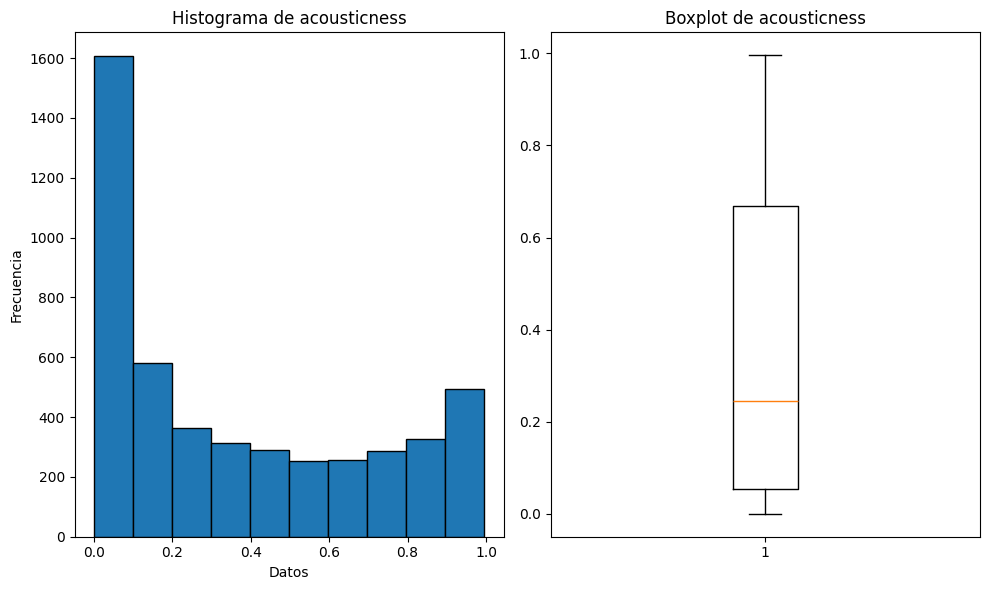

In [15]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_sin_nulos['acousticness'])

Vamos a describir los datos:
- **Tendencia:** Los datos NO están centrados. Se puede ver una fuerte concentración (desviación) hacia la izquierda.
- **Dispersión:** Los datos están algo dispersos, salvo los encontrados entre 0.0 y 0.1.
- **Forma:** Se ve claramente que no se parece nada a la normal, sino a una Bimodal Asimétrica (dos picos).
- **Outliers:** No se ven datos atípicos.

Al estar todos 'escalados', no es necesario realizar un escalado sobre esta columna.

#### **Columna 'danceability'**
Según las descripciones, `Qué tan adecuada es la canción para bailar según ritmo, estabilidad y beat.` Vamos a ver la distribución de los datos:

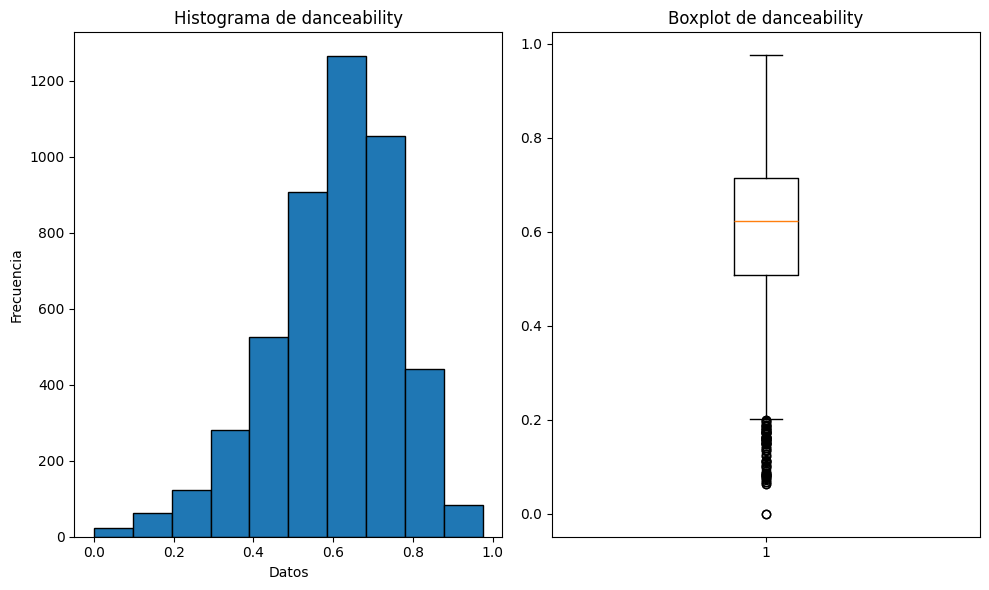

In [16]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_sin_nulos['danceability'])

Vemos cosas más interesantes:
- **Tendencia:** Algo más centrada, pero desviada hacia la izquierda.
- **Dispersión:** Los datos no están muy dispersos: Están más concentrados alrededor del centro.
- **Forma:** Distribución no simétrica, similar a una Beta con sesgo negativo.
- **Atípicos:** Aquí sí encontramos datos atípicos, los cuales están debajo del primer cuartil.

Antes de aplicar una **transformación** (como el logaritmo), vamos a calcular el `Skewness`, que nos indicará hacia dónde se concentran los datos:

In [17]:
# Calculamos skewness
dataset_spotify_sin_nulos['danceability'].skew()

np.float64(-0.6655160249968685)

Para determinar qué hacer, vamos a definir estas reglas:
- **Skew entre -0.5 y 0.5:** `Simetría casi perfecta.` 🟢 Punto **verde.**
- **Skew entre -0.5 y -1:** `Asimetría (cola hacia la izquierda), pero moderada.` 🟡 Punto **amarillo.**
- **Skew menor a -1:** `Asimetría (cola hacia la izquierda), por lo que es recomendable aplicar una transformación.` 🔴 Punto **rojo.**
- **Skew entre 0.5 y 1:** `Asimetría (cola hacia la derecha), pero moderada.` 🟡 Punto **amarillo.**
- **Skew mayor a 1:** `Asimetría (cola hacia la derecha), por lo que es recomendable aplicar una transformación.` 🔴 Punto **rojo.**

Pero hay que tener cuidado, ya que el logaritmo (o transformaciones similares), `cambian las distancias.` Por eso, vamos a adaptar para nuestro clústering estas nuevas normas:
* **Si estamos en el punto amarillo,** Tratamos el dato según esté más cerca o al punto verde o al rojo.
* **Si está a la misma distancia de ambos,** Nos ponemos conservadores y lo tratamos como punto verde.
* **Para evitar problemas,** ponemos un pequeño margen: A los puntos amarillos les sumamos/restamos 0.05 para determinar cómo lo tratamos.

Definido esto, vamos a definir las reglas de nuevo:
* **🟢 Punto verde (Simetría/Asimetría tratable):** entre los rangos -0.8 y 0.8 (aplicando `las nuevas reglas que hemos definido`).
* **🔴 Punto rojo (Asimetría no tratable):** Menos a -0.8 o mayor a 0.8.

Como nos da un skew de -0.67 aproximadamente, **`la columna pertenecería al punto verde,`** por lo cual, mejor **conservar y no transformar los datos,** conservando así la distancia real.

<span style="font-size:40px;">**¿Por qué estos rangos?**</span>

Porque en general, transformar una columna con un logaritmo o potencia, cambia la distancia de los datos `al ser funciones no lineales.` Para datos donde las distancias *relativas* entre los datos concentrados y los dispersos es pequeña, esto suele **afectar al clústering,** haciendo que las distancias no sean las reales. Para datos muy asimétricos, pasar de un dato a otro es una gran distancia. Cuando dicha distancia es muy grande, funciones como el logaritmo o potencia hacen **que los atípicos se acerquen más a los datos.** En otras palabras, solo acercamos más los outliers pero con la diferencia que no sesgarán al modelo (las distancias serán lo suficientemente tratables y capaces de diferenciar a los outliers de los demás datos).

Dicho esto, concluimos que **`debemos de dejar la columna tal cual`** al estar en el **punto verde.**

<span style="font-size:40px;">**¿Cuál es la máxima transformación a usar?**</span>

No vamos a forzar un skew para estar en el punto verde (ejemplo, si hacemos una raíz de 10, **aplastamos mucho los datos**). Dicho esto, nuestras funciones a probar serán:
* **Para colas a la derecha:** Raíz cuadrada, raíz cúbica y como `máximo el logaritmo.`
* **Para colas a la izquiera:** Potencia al cuadrado, potencia al cubo y como `máximo, una exponencial (np.exp).`

<span style="font-size:30px;">**NOTA: Solo aplicaremos el skew en caso de encontrar atípicos en el caja y bigotes. Recordar que `aplicar una transformación NO asegura que la columna pase a estar en el punto verde`. En ese caso, mejor la dejamos sin aplicar nada.**</span>

#### **Columna 'duration_ms'**
Según las descripciones, `Duración de la canción en milisegundos,` probablemente ya no en el rango [0, 1] como hemos tenido hasta ahora (suerte). Vamos a ver la distribución de los datos:

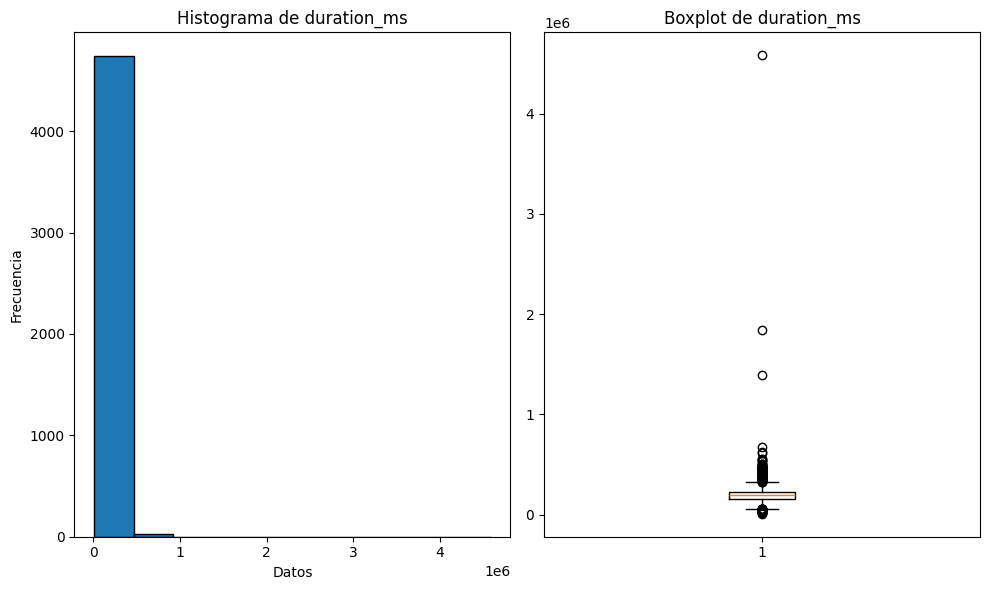

In [18]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_sin_nulos['duration_ms'])

Esto ya es algo que pinta muy mal:
- **Tendencia:** Tiene un sesgo positivo extremo.
- **Dispersión:** Los datos están completamente (casi) concentrados en el 0.0 y 0.5.
- **Forma:** Una sola barra, demostrando supremacia de datos.
- **Atípicos:** Aquí hay bastantes atípicos, resultante de la gran concentración de datos.

Antes de tratar los atípicos, vamos a describir los datos de la columna:

In [19]:
# Mostramos descripcion
dataset_spotify_sin_nulos.describe()['duration_ms']

count    4.765000e+03
mean     2.029311e+05
std      9.587756e+04
min      1.002700e+04
25%      1.616970e+05
50%      1.942860e+05
75%      2.295260e+05
max      4.581483e+06
Name: duration_ms, dtype: float64

Vemos datos en milisegundos. Vamos a transformarlos a minutos para que sea más entendible y explicable:

In [20]:
# Copia para aplicar cambios
dataset_spotify_minutes = dataset_spotify_sin_nulos.copy()

# Aplicamos la transformacion a segundos
dataset_spotify_minutes['duration_ms'] = dataset_spotify_minutes['duration_ms'] / (1000 * 60)

# Mostramos las nuevas descripciones
dataset_spotify_minutes.describe()['duration_ms']

count    4765.000000
mean        3.382184
std         1.597959
min         0.167117
25%         2.694950
50%         3.238100
75%         3.825433
max        76.358050
Name: duration_ms, dtype: float64

Canciones de 76 minutos es muy raro (al menos, desconocemos de su existencia). Vamos a ver los gráficos si queda más claro:

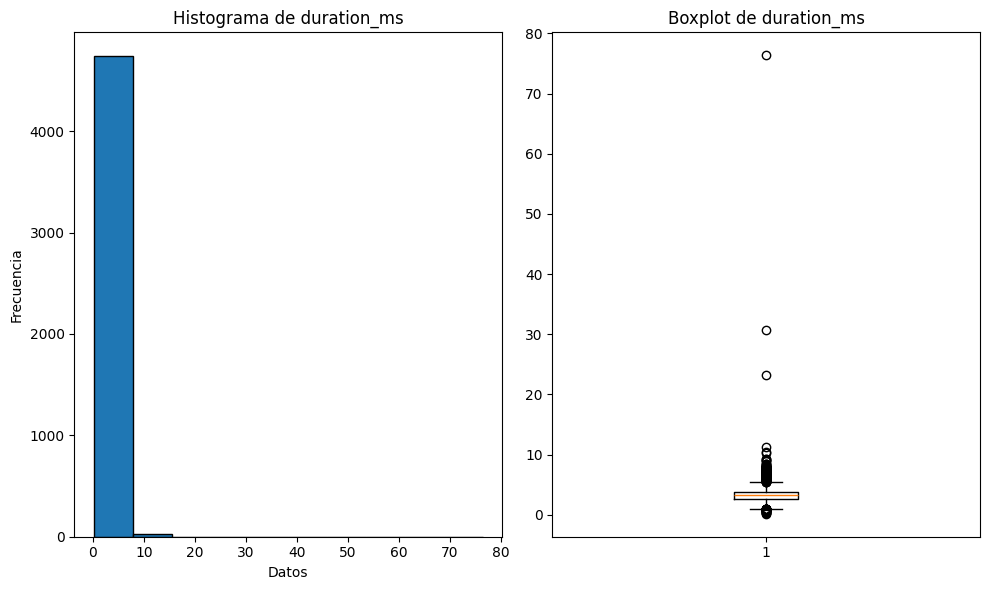

In [21]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_minutes['duration_ms'])

Claramente se muestra que hay canciones registradas de más de 20 minutos (lo cual es muy extraño), llegando a incluso canciones de más de 70 minutos. Finalmente, investigando, hay canciones que suelen durar mucho tiempo (como la música clásica). Es más, hay veces en las que en Spotify, los audiolibros suelen colarse, y estos suelen durar mucho tiempo (tranquilamente los más de 70 minutos). **Procedemos a calcular el Skew (coeficiente de simetría)** para ver que hacemos:

In [22]:
# Calculamos el skew
dataset_spotify_sin_nulos['duration_ms'].skew()

np.float64(21.838494789782203)

<span style="font-size:30px;">**Tenemos un skew gigante**</span>

Claramente 'duration_ms' cae en el punto rojo, por lo cual, `procedemos a aplicar transformaciones:`

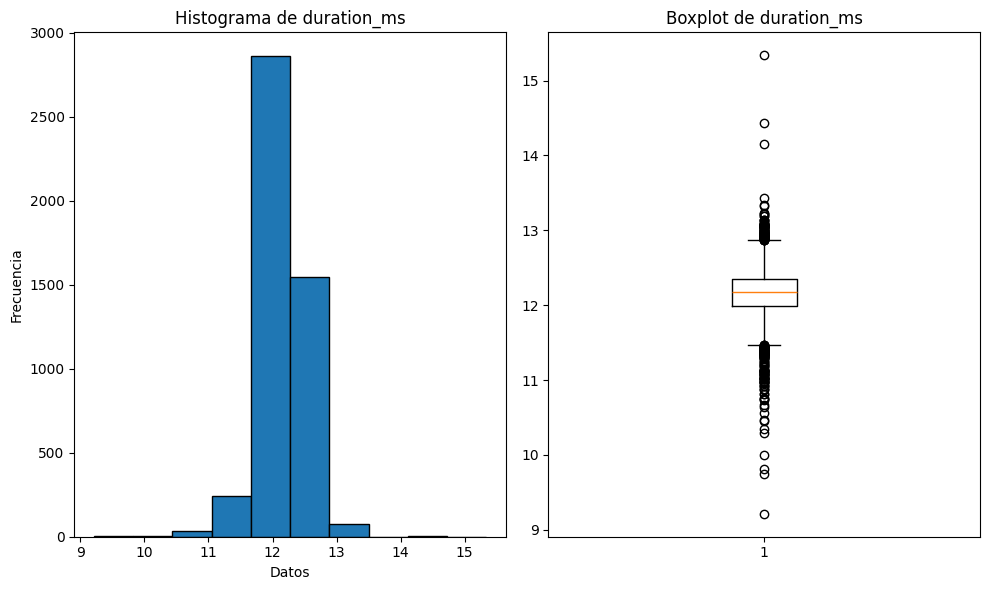

In [23]:
# Sacamos una copia (por si necesitamos ejecutar de nuevo la celda)
dataset_spotify_log_duration = dataset_spotify_sin_nulos.copy()  # Usamos la que no son de minutos para conservar la escala original

# Aplicamos el logaritmo a la columna
dataset_spotify_log_duration['duration_ms'] = np.log1p(dataset_spotify_log_duration['duration_ms'])

# Mostramos los nuevos graficos
obtener_caja_bigotes(dataset_spotify_log_duration['duration_ms'])

Vemos ahora algo mucho mejor: Datos muy concentrados, pero con atípicos (justificables). Vamos a ver su nuevo skew:

In [24]:
# Calculamos skew
dataset_spotify_log_duration['duration_ms'].skew()

np.float64(-0.5283442185324757)

Hemos logrado no solo arreglar la columna, sino **meterla en el punto verde.** Aún así el rango de valores es muy grande ([9, 15]). Apuntamos esta columna (valores muy grandes):

In [25]:
# Creamos una lista de escalados
columnas_valores_grandes = list()

# Añadimos la columna
columnas_valores_grandes.append('duration_ms')
columnas_valores_grandes

['duration_ms']

#### **Columna 'energy'**
Según las descripciones, `Intensidad y actividad percibida de la pista (0 a 1).` Vamos a ver la distribución de los datos:

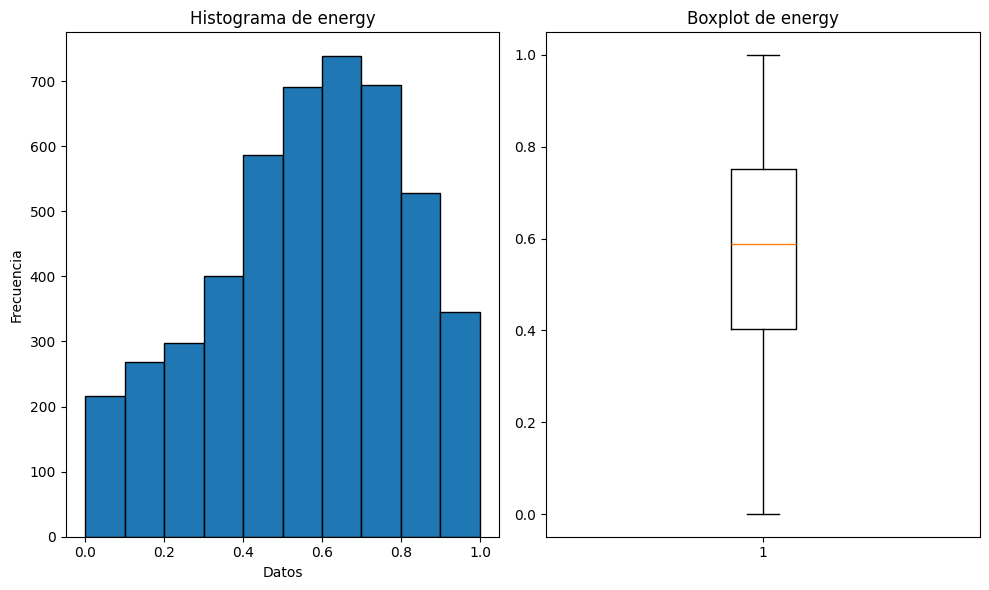

In [26]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_log_duration['energy'])

Según los gráficos:
- **Tendencia:** los datos no están centrados, sino que tienen un sesgo hacia la izquierda.
- **Dispersión de los datos:** Los datos están algo dispersos, ya que no se ve una 'caida' en el histograma.
- **Forma:** Se asemeja a una distribución Beta al no ser simétrica (para ser una normal).
- **Atípicos:** No hay datos atípicos (raros).

La columna es perfecta, y no es necesario aplicarle nada. La dejamos asi.

#### **Columna 'instrumentalness'**
Según las descripciones, `Probabilidad de que la pista sea instrumental (seguramente entre el rango 0 y 1).` Vamos a ver la distribución de los datos:

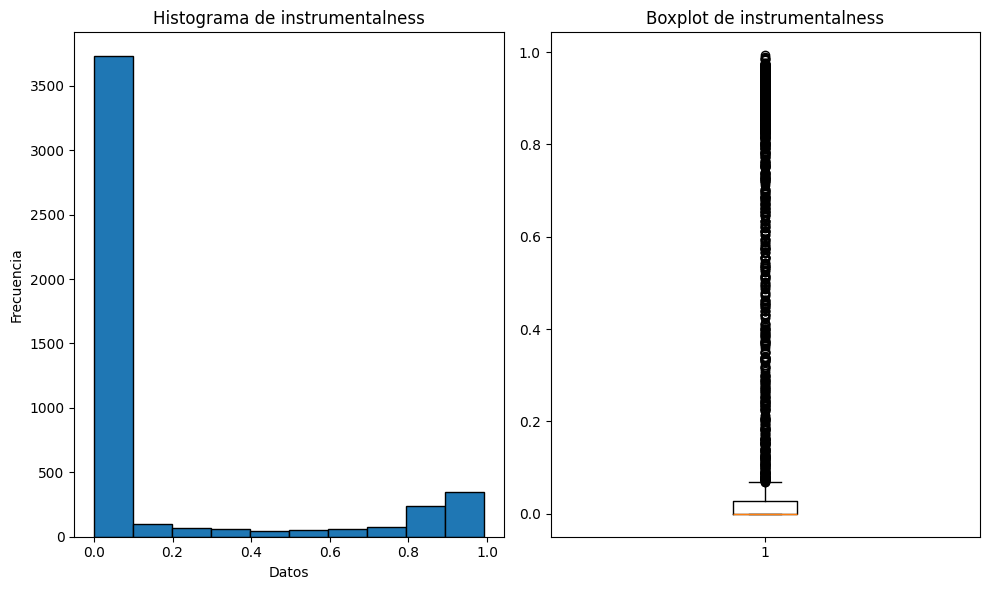

In [27]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_log_duration['instrumentalness'])

Vemos algo similar que a `acousticness,` pero más notorio:
- **Tendencia:** Al parecer, vemos que esta sesgado hacia la derecha.
- **Dispersión de los datos:** Los datos no están muy dispersos, estando concentrados en los valores entre 0.0 y 0.1.
- **Forma:** Una bimodal (2 picos, aunque uno mucho más pequeño que el otro).
- **Atípicos:** Vemos muchisimos atípicos, concentrados hacia la derecha.

Tenemos que ver los atípicos. Según estuvimos buscando, es normal que haya música instrumental como la clásica, por lo cual, eliminar estos datos atípicos **Seria un error grave.** Veremos como podemos gestionarlos, pero primero, veamos su skew:

In [28]:
# Calculamos skew
dataset_spotify_log_duration['instrumentalness'].skew()

np.float64(1.786990301217926)

Cae en el punto rojo. Procedemos a aplicarle una transformación:

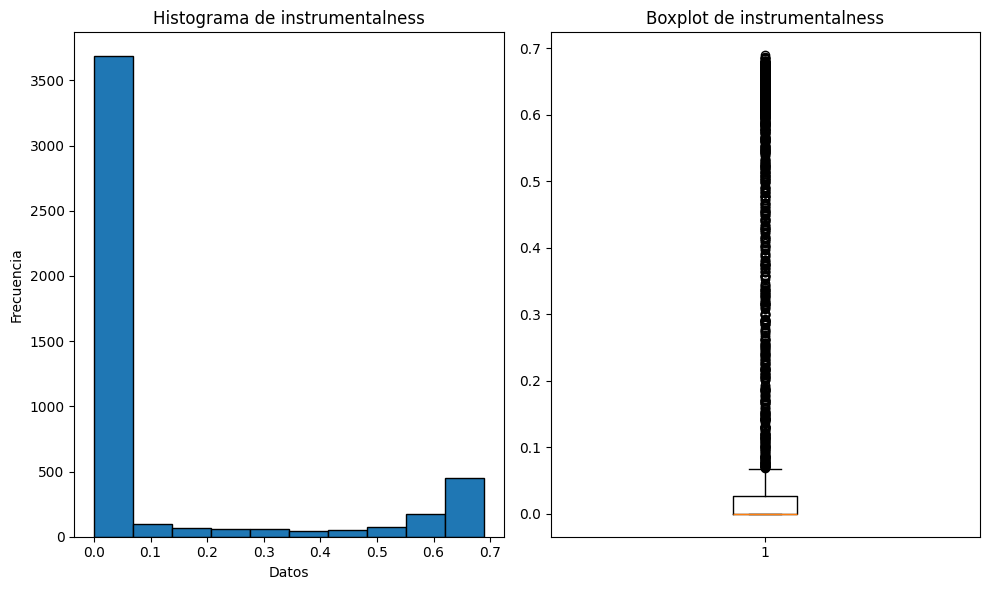

In [29]:
# Sacamos una copia (por si necesitamos ejecutar de nuevo la celda)
dataset_spotify_log_instru = dataset_spotify_log_duration.copy()  # Usamos la que no son de minutos para conservar la escala original

# Aplicamos el logaritmo a la columna
dataset_spotify_log_instru['instrumentalness'] = np.log1p(dataset_spotify_log_instru['instrumentalness'])

# Mostramos los nuevos graficos
obtener_caja_bigotes(dataset_spotify_log_instru['instrumentalness'])

Vamos a ver su nuevo skew:

In [30]:
# Calculamos skew
dataset_spotify_log_instru['instrumentalness'].skew()

np.float64(1.7115909333354016)

No resolvimos la asimetría. Por lo cual, tenemos estas opciones:
- `Dejarlo así tal cual:` Estos datos van entre 0 y 1 y, aunque los valores estén muy dispares, la distancia está acotada entre los puntos (al estar en el rango 0 y 1).
- `Aplicar un 'binning:'` Como vemos que los datos están en 2 grupos diferenciables (instrumental y no instrumental), podemos aplicar un binning para separar los datos.

Para este caso, decidimos en **dejarlo asi,** ya que, no perdemos información (cosa que pasaría bien o mal con el binning). Reiteramos que, a pesar de ser muchos atípicos, como los datos están entre 0 y 1, al realizar el cálculo de distancias al formar los clústers, no es lo suficientemente grande para sesgar al modelo a formar 2 clusters: los atípicos y normales.

#### **Columna 'key'**
Según las descripciones, `Tonalidad musical representada como número entero (0–11).` Antes de ver gráficos, vamos a ver como son los datos:

In [31]:
# Contamos los datos
dataset_spotify_log_duration['key'].value_counts()

key
0.0     542
1.0     492
2.0     477
7.0     476
9.0     446
11.0    403
4.0     373
6.0     373
5.0     366
8.0     348
10.0    286
3.0     183
Name: count, dtype: int64

Vemos aquí que pinta más de discreta que de continua, aparte que ni si quiera representa orden (según buscamos, son categorías en Spotify sin relación de orden). Vamos a anotarla para tratarla como `categórica:`

In [32]:
# Ponemos la variable como categorica
dataset_spotify_log_duration['key'] = dataset_spotify_log_duration['key'].astype(object)

# Confirmamos que es categorica
dataset_spotify_log_duration.select_dtypes(exclude=np.number).columns

Index(['track_name', 'artist_name', 'key'], dtype='str')

#### **Columna 'liveness'**
Según las descripciones, `Presencia de público; valores altos indican grabaciones en vivo.` Vamos a ver la distribución de los datos:

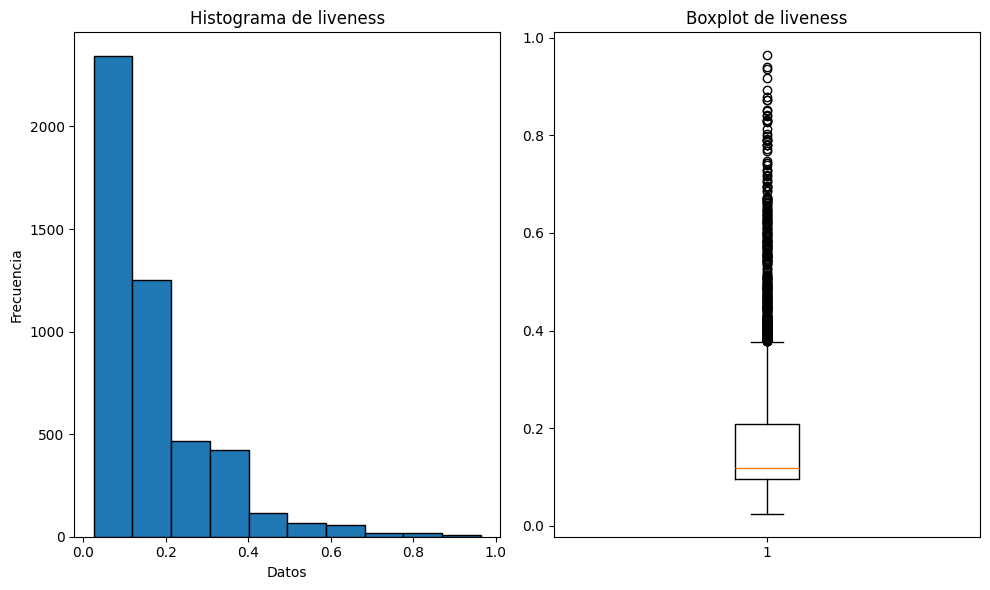

In [33]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_log_duration['liveness'])

Vemos los siguientes detalles:
- **Tendencia:** Sesgado hacia la derecha.
- **Dispersión:** Datos no muy dispersos (concentrados mayormente en el pico entre 0.0 y 0.1-0.2).
- **Forma:** Se asemeja a una beta, pero sin ser simétrica.
- **Atípicos:** Bastantes, reflejados en la cola de la derecha.

Vamos a comprobar el Skew:

In [34]:
# Calculamos skew
dataset_spotify_log_duration['liveness'].skew()

np.float64(2.184979702328802)

Estamos en el punto rojo. Vamos a ver si con alguna transformación lo arreglamos:

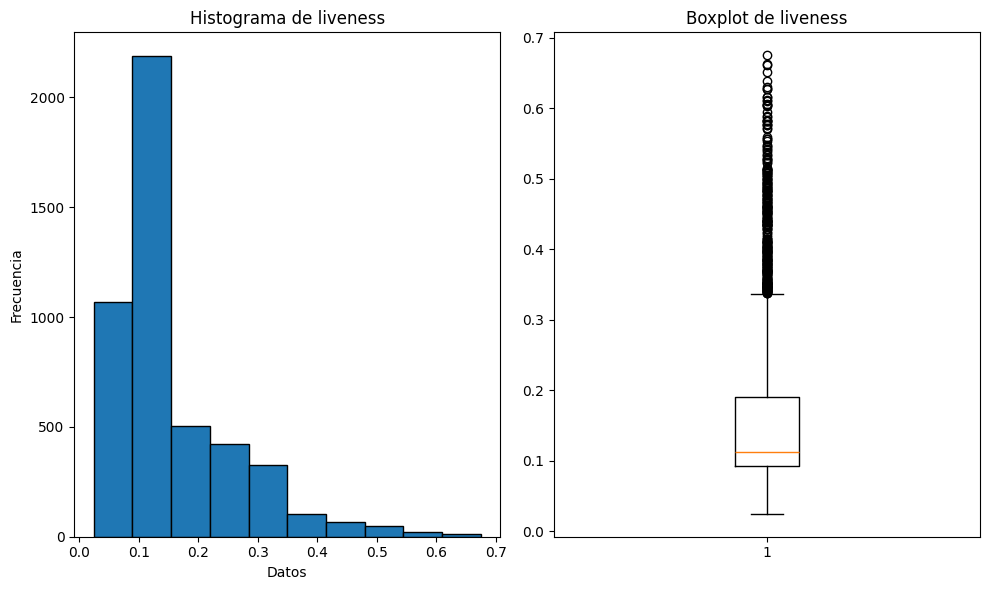

In [35]:
# Sacamos una copia (por si necesitamos ejecutar de nuevo la celda)
dataset_spotify_log_live = dataset_spotify_log_duration.copy()

# Aplicamos el logaritmo a la columna
dataset_spotify_log_live['liveness'] = np.log1p(dataset_spotify_log_live['liveness'])

# Mostramos los nuevos graficos
obtener_caja_bigotes(dataset_spotify_log_live['liveness'])

Vamos a ver el Skew nuevo:

In [36]:
# Calculamos skew
dataset_spotify_log_live['liveness'].skew()

np.float64(1.809076295684504)

No llegamos al punto verde, por lo cual, no aplicamos transformaciones.

**Nota:** Los atípicos son valores reales, no podemos quitarlos (pueden ser canciones que se emitieron en vivo, y es muy normal). Pasa como con instrumentalness, pero al estar en el rango [0, 1], pues podemos dejarlos así por la misma razón: Conservar la información.

#### **Columna 'loudness'**
Según las descripciones, `Volumen promedio de la pista en decibelios (dB).` Vamos a ver la distribución de los datos:

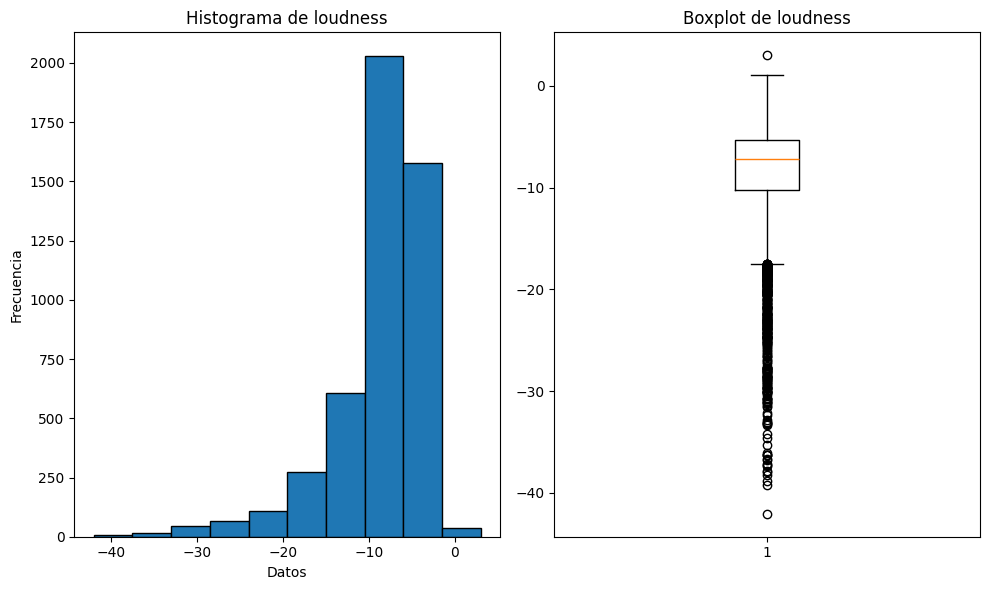

In [37]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_log_duration['loudness'])

Vemos lo siguiente:
- **Tendencia:** Sesgado hacia la izquierda.
- **Dispersión de los datos:** Poca, datos concentrados entre -4 y -15 (más o menos, una aproximación).
- **Forma:** Distribución con asimetría negativa.
- **Atípicos:** Bastantes, en especial, en la cola izquierda.

Vamos a ver el skew:

In [38]:
# Calculamos skew
dataset_spotify_log_duration['loudness'].skew()

np.float64(-2.055255515732926)

Estamos en el punto rojo, por lo cual, vamos a tratar los atípicos a traves de transformaciones, pero con cuidado: Tenemos valores negativos, por lo que ni el logaritmo ni la raíz cuadrada ayudarán. Vamos a hacer una raíz cúbica, la mejor opción que tenemos:

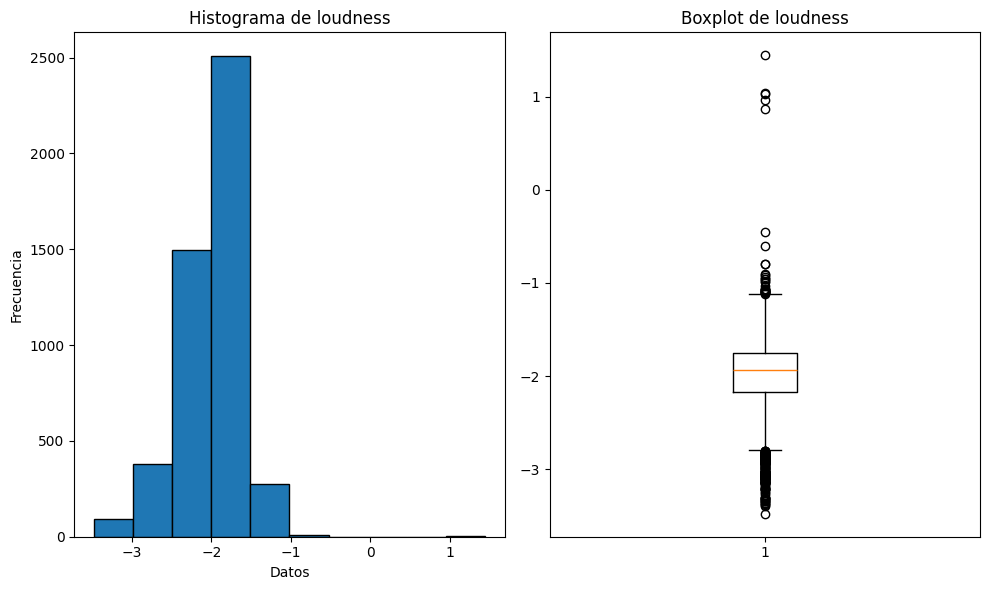

In [39]:
# Sacamos una copia
dataset_spotify_cbrt_loud = dataset_spotify_log_duration.copy()

# Aplicamos la transformacion
dataset_spotify_cbrt_loud['loudness'] = np.cbrt(dataset_spotify_cbrt_loud['loudness'])

# Mostramos los resultados
obtener_caja_bigotes(dataset_spotify_cbrt_loud['loudness'])

Vemos el nuevo skew:

In [40]:
# Calculamos skew
dataset_spotify_cbrt_loud['loudness'].skew()

np.float64(-0.16977683695931264)

Punto verde, perfecto. Nos apuntamos esta columna para escalado (para mantener mismas escalas):

In [41]:
# Añadimos la columna
columnas_valores_grandes.append('loudness')
columnas_valores_grandes

['duration_ms', 'loudness']

#### **Columna 'mode'**
Según las descripciones, `Modo musical: 1 para mayor, 0 para menor.` Vamos a comprobar que solo tenemos datos que sean o 0 y 1:

In [42]:
# Vemos los valores
dataset_spotify_cbrt_loud['mode'].unique()

array([0., 1.])

Confirmado que solo hay dos valores posibles (0 y 1). No hacemos nada, porque prácticamente es un onehot. ¡Perfecto!

#### **Columna 'speechiness'**
Según las descripciones, `Cantidad de palabras habladas en la canción.` Vamos a ver la distribución de los datos:

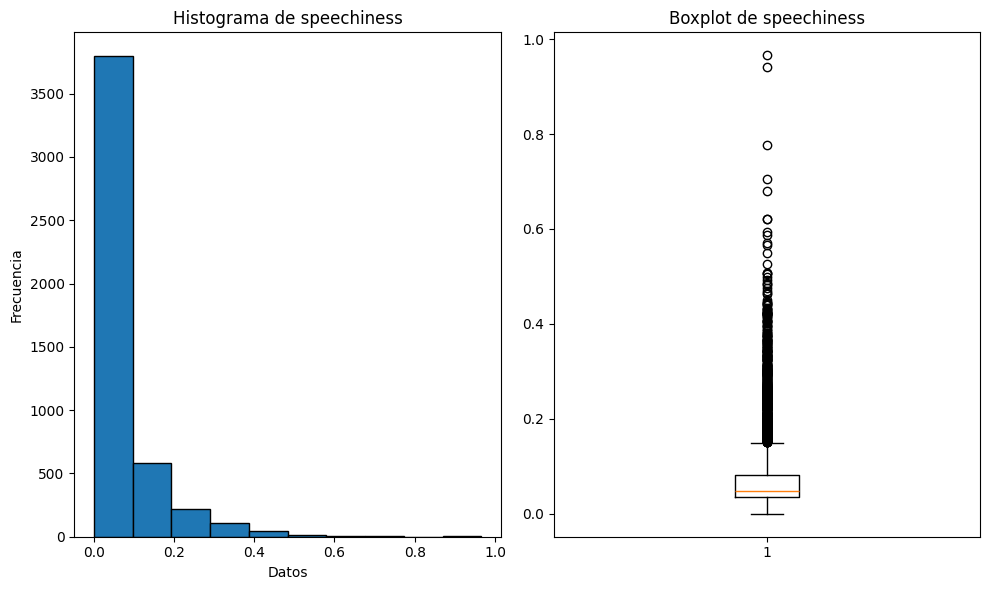

In [43]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_cbrt_loud['speechiness'])

Vemos lo siguiente:
- **Tendencia:** Sesgado hacia la derecha.
- **Dispersión:** Datos concentrados mayormente entre 0.0 y 0.1 (sin mucha/nula dispersión).
- **Forma:** Una Beta, al estar los valores entre 0 y 1, y no ser simétrica para ser una Gaussiana.
- **Atñipicos:** Todos en la cola derecha.

Vemos el skew:

In [44]:
# Calculamos skew
dataset_spotify_cbrt_loud['speechiness'].skew()

np.float64(3.321573804190871)

Punto rojo, probamos una transformación a ver si lo arreglamos:

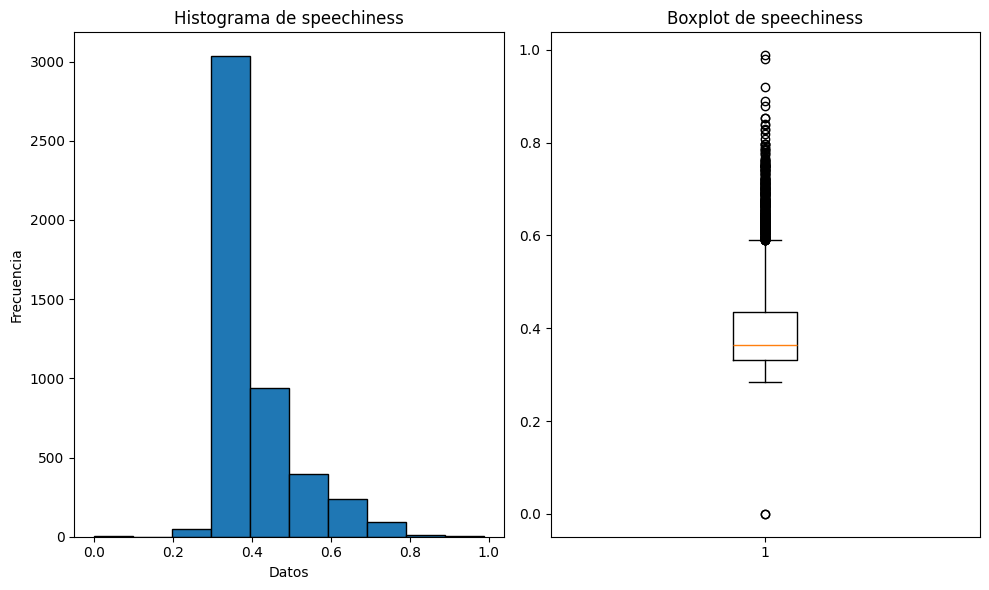

In [45]:
# Sacamos una copia
dataset_spotify_log_speech = dataset_spotify_cbrt_loud.copy()

# Aplicamos la transformacion
dataset_spotify_log_speech['speechiness'] = np.cbrt(dataset_spotify_log_speech['speechiness'])

# Mostramos los resultados
obtener_caja_bigotes(dataset_spotify_log_speech['speechiness'])

Vemos el nuevo skew:

In [46]:
# Calculamos skew
dataset_spotify_log_speech['speechiness'].skew()

np.float64(1.669119085814705)

Nada, no se solucionó el problema. Sin embargo, si buscamos en Spotify, nos encontramos con esto:

**Interpretación de `speechiness:`**

Según los estándares de ingeniería de audio de Spotify, los valores se dividen en tres zonas funcionales:

* **Valores < 0.33 (Música):** Representan pistas compuestas mayoritariamente por música y sin contenido hablado.
* **Valores entre 0.33 y 0.66 (Híbridos):** Describen pistas que contienen tanto música como habla, ya sea por secciones o capas superpuestas. En este rango se suelen clasificar géneros como el **Rap** o la música rítmica hablada.
* **Valores > 0.66 (Habla):** Describen pistas que probablemente están compuestas enteramente de palabras habladas. Aquí se clasifican los **Podcasts, Audiolibros y programas de entrevistas**.

Podemos concluir en no tocar dicha columna, simplemente por el hecho de perder dicha información (la cual, nos cargamos aplicando una transformación, como la logarítmica).

#### **Columna 'tempo'**
Según las descripciones, `Tempo estimado en BPM.` Vamos a ver la distribución de los datos:

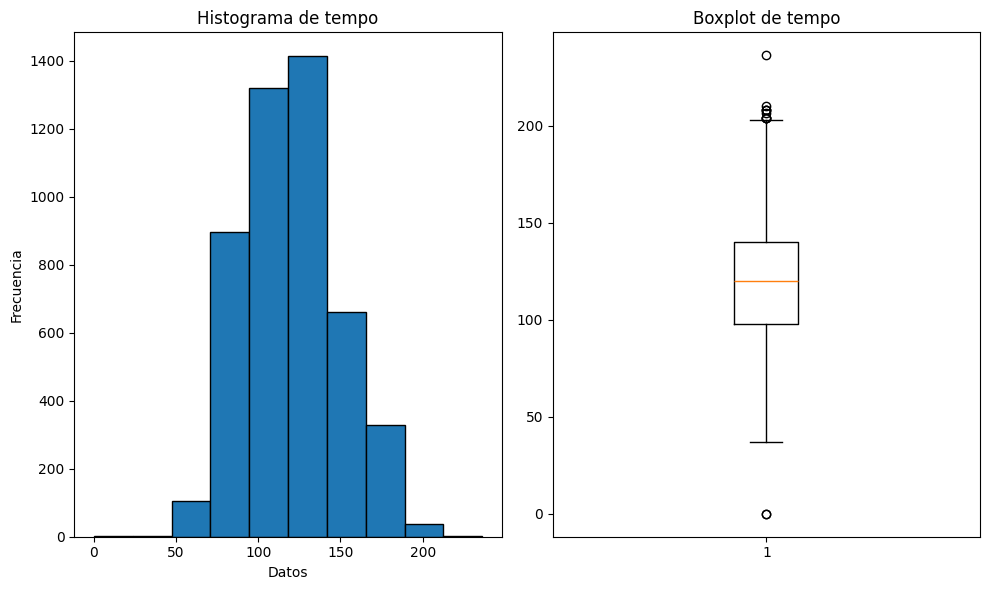

In [47]:
# Vemos los graficos
obtener_caja_bigotes(dataset_spotify_cbrt_loud['tempo'])

Vemos lo siguiente:
- **Tendencia:** Centrada, sin colas.
- **Distribución de los datos:** Buena, se ven datos distribuidos.
- **Forma:** Muy cerca a una Gaussiana, aunque no es muy simétrica.
- **Atípicos:** Unos cuantos, pero manejables.

Veamos el skew de nuevo:

In [48]:
# Calculamos skew
dataset_spotify_cbrt_loud['tempo'].skew()

np.float64(0.29359650610744026)

Punto verde, por lo cual, no hacemos nada

**Nota:** Al no existir muchos atípicos que sean muy exagerados, ya que hay canciones que se diferencian por tener poco tempo (como el Dark Ambient, con menos de 50 BPM, o como el Drum & Basscon más de 175+ BPM). Por seguridad, dejamos así la columna, pero anotándola para escalado:

In [49]:
# Añadimos la columna
columnas_valores_grandes.append('tempo')
columnas_valores_grandes

['duration_ms', 'loudness', 'tempo']

#### **Columna 'time_signature'**
Según las descripciones, `Compás de la canción (por ejemplo, 4 indica 4/4).` Vamos a ver qué valores tenemos:

In [50]:
# Vemos como son los valores de la columna
dataset_spotify_cbrt_loud['time_signature'].value_counts()

time_signature
4.0    4316
3.0     350
5.0      64
1.0      33
0.0       2
Name: count, dtype: int64

Vemos que, son datos categóricos, pero buscando por internet, no representa orden ni similar. Las tratamos como categoricas, y las marcamos como tal (para OneHot más adelante, o no):

In [51]:
# Ponemos la variable como categorica
dataset_spotify_cbrt_loud['time_signature'] = dataset_spotify_cbrt_loud['time_signature'].astype(object)

# Confirmamos que es categorica
dataset_spotify_cbrt_loud.select_dtypes(exclude=np.number).columns

Index(['track_name', 'artist_name', 'key', 'time_signature'], dtype='str')

### **Escalado de las numéricas**
Ahora, vamos a analizar que escalado sería el mejor: Standard o MinMax.

#### **StandardScaler**
Los algorítmos de clústering (y en especial, los basados en distancias) adoran este escalado: Hacemos que las columnas `tengan la misma medida (al estar media centrada).` Es decir, que si variamos una unidad en un eje, es igual que avanzarlo en otro eje. Lo malo es que, si la columna a la que queremos aplicarle este escalado:
* Tiene `outliers considerables.`
* No es `completamente Gaussiana.`

Con esto, **no podemos aplicar un Standard** a todo porque `existen columnas que ni si quieran se pueden transformar a Gaussianas.` Lo segundo, tenemos una mayoria de datos que:
* Ya están **en el rango [0, 1].**
* La mayoría `son modales (uni, bi, etc).` Solo unas pocas tienen aproximádamente la **forma de una GAUSSIANA.**

Por lo cual, descartamos este escalado.

#### **MinMaxScaler**
A diferencia de Standard, MinMax solo `acota el espacio entre un rango.` Pero, ¿Por qué es nuestra mejor opción? Aunque perdemos esa ventaja de Standard (que incluso, le favorecia porque al trabajar en una misma medida, hace que la distancia, que es calculada por los centroides, sea una circunferencia, lo cual ayuda a estos tipos de clústering como el particional o el jerárquico), **la mayoría de datos están ya en [0-1] y tenemos `pocas columnas que se aproximan a una GAUSSIANA.`** Una lástima, ya que sino, hubieramos aplicado el Standard, pero hay que sacrificar cosas porque sino los resultados serían desastrosos. Aclarar que, como a los atípicos que eran exagerados (como en duration_ms) fueron tratados con el logaritmo, potencia y demás, el MinMax no se verán tan afectado por estos:

In [52]:
# Creamos el objeto
min_max = MinMaxScaler(feature_range=(0, 1))

# Escalamos nuestras columnas marcadas
dataset_spotify_cbrt_loud[columnas_valores_grandes] = min_max.fit_transform(dataset_spotify_cbrt_loud[columnas_valores_grandes])

# Mostramos los resultados
dataset_spotify_cbrt_loud.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,mode,speechiness,tempo
count,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000,4765.000000
mean,0.362924,0.602469,0.481557,0.563524,0.153215,0.174589,0.303593,0.612382,0.078468,0.505404
std,0.334355,0.157753,0.055419,0.243561,0.313149,0.130756,0.077938,0.487258,0.080105,0.122757
min,0.000002,0.000000,0.000000,0.001080,0.000000,0.024900,0.000000,0.000000,0.000000,0.000000
25%,0.053800,0.509000,0.453979,0.403000,0.000000,0.096200,0.266062,0.000000,0.036100,0.413081
50%,0.245000,0.623000,0.483959,0.589000,0.000025,0.119000,0.313884,1.000000,0.047900,0.507299
75%,0.668000,0.714000,0.511175,0.751000,0.027600,0.209000,0.351505,1.000000,0.081900,0.591818
max,0.996000,0.976000,1.000000,0.999000,0.993000,0.964000,1.000000,1.000000,0.966000,1.000000


### **Vamos a comprobar los datos de las columnas**
Tratado los numéricos, pasamos ahora con los categóricos (que son poquitos y muy fáciles):

#### **Columna 'track_name'**
No hay descripción para esta, por lo cual, veamos los datos:

In [53]:
# Vemos los datos de la columna
dataset_spotify_cbrt_loud['track_name'].values

<StringArray>
[                                                           '"Honest"',
 '"In The Hall Of The Mountain King" from Peer Gynt Suite N°1, Op. 46',
                                                  '#BrooklynBloodPop!',
                                                                 '$10',
                                          '(I Just) Died In Your Arms',
                                                       '(L)only Child',
                                                               '(lol)',
                  '...And to Those I Love, Thanks for Sticking Around',
                                               '...Baby One More Time',
                                                            '0 to 100',
 ...
                                                 'Young And Beautiful',
                                                  'Young Dumb & Broke',
                                                          'Youngblood',
                                             

Vemos que son los nombres de las canciones. Vamos a quitar esta columna, ya que solo aportará ruido:

In [54]:
# Eliminamos la columna
dataset_spotify_sin_nombre = dataset_spotify_cbrt_loud.drop(columns=['track_name'])

# Vemos si se elimino
dataset_spotify_sin_nombre.select_dtypes(exclude=np.number).columns

Index(['artist_name', 'key', 'time_signature'], dtype='str')

#### **Columna 'artist_name'**
No hay descripción de la columna, pero sabemos que son el nombre de los artistas. Veamos cuantos valores únicos tenemos:

In [55]:
# Vemos los datos de la columna
dataset_spotify_sin_nombre['artist_name'].nunique()

2187

Si nos ponemos a pensar, no aporta mucha información útil: Tenemos más de 2000 artistas, y hacerles un OneHot, nos daría 2187 columnas nuevas. Recordemos que nuestro objetivo principal es **`agrupar canciones por su posible género.`** A través del artista, estaríamos diciendo al algoritmo 'junta las canciones de Post Malone, luego las de Don Toliver o las de The Weeknd', lo cual rompe el objetivo. Por ello, es preferible cargárselas:

In [56]:
# Eliminamos la columna
dataset_spotify_sin_artista = dataset_spotify_sin_nombre.drop(columns=['artist_name'])

# Vemos si se elimino
dataset_spotify_sin_artista.select_dtypes(exclude=np.number).columns

Index(['key', 'time_signature'], dtype='str')

#### **Columna 'key'**
Esta ya la vimos antes. Pero hemos estado buscando, y key `no suele ser muy buena para distinguir géneros.` Asi que preferimos descartar esta columna:

In [57]:
# Eliminamos la columna
dataset_spotify_sin_key = dataset_spotify_sin_artista.drop(columns=['key'])

# Vemos si se elimino
dataset_spotify_sin_key.select_dtypes(exclude=np.number).columns

Index(['time_signature'], dtype='str')

#### **Columna 'time_signature'**
Al igual que `key,` ya la vimos antes. Y justo también, `no suele ser efectiva para distinguir géneros.` La descartamos:

In [58]:
# Eliminamos la columna
dataset_spotify_sin_time_signature = dataset_spotify_sin_key.drop(columns=['time_signature'])

# Vemos si se elimino
dataset_spotify_sin_time_signature.select_dtypes(exclude=np.number).columns

Index([], dtype='str')

#### **Justificación de por qué las quitamos**
Las hemos quitado segñun esta información que encomtramos:

**Justificación**

Para optimizar el rendimiento de los algoritmos de clustering y garantizar una segmentación basada en **estilo musical** y no en teoría musical, se ha decidido eliminar las variables `key` (tonalidad) y `time_signature` (compás).

A continuación se detallan los motivos técnicos y de negocio:

**1. Irrelevancia para la definición de Género Musical**

El objetivo del clustering es agrupar canciones por su "vibe" o género (Pop, Rock, EDM, etc.). Estas variables aportan poco valor discriminatorio:
* **Independencia del Género (`key`):** La tonalidad no define el estilo. Una canción de *Heavy Metal* y una balada de *Piano* pueden estar ambas en **Do Mayor**. Agruparlas por compartir la nota tónica generaría "falsos positivos" (canciones que no se parecen en nada pero están en el mismo grupo).
* **Homogeneidad Estructural (`time_signature`):** La inmensa mayoría de la música occidental moderna (Pop, Rock, Urbano, Electrónica) está compuesta en **4/4**. Al ser una variable casi constante en el dataset, aporta nula varianza útil y solo sirve para aislar casos raros (como vals en 3/4) que ya son detectados por otras variables como `danceability` o `tempo`.

**2. Distorsión de la Distancia**
Los algoritmos utilizados se basan en distancias matemáticas. Estas variables introducen ruido en el cálculo:
* **El problema de la variable Categórica (`key`):** Aunque el dataset la presenta como números (0 a 11), la tonalidad es circular y categórica, no ordinal.
    * *Ejemplo:* La distancia matemática entre la nota 0 (Do) y la nota 11 (Si) es **11** (muy lejos). Sin embargo, musicalmente son notas adyacentes (semitono). El algoritmo interpretaría erróneamente que son canciones "muy distintas" cuando armónicamente son vecinas.
* **El efecto "Escalón" (`time_signature`):** Al ser una variable discreta (3, 4, 5), crea cortes artificiales en el espacio de datos. Esto es crítico ya que podrían fragmentar un clúster de género válido en dos sub-grupos artificiales solo porque una canción tiene un compás distinto, rompiendo la continuidad del estilo.

***Referencias:***

- *Documentación de Spotify for Developers: https://developer.spotify.com/documentation/web-api/reference/get-audio-features*
- *IBM / Documentación técnica de Data Science: https://www.ibm.com/topics/k-means-clustering*

### **Vamos a ver las columnas**
Para encontrar si hay columnas muy correlacionadas, para poder eliminarlas:

In [59]:
# Sacamos las correlaciones de las columnas
correlaciones = dataset_spotify_sin_time_signature.corr()

# Seleccionamos solo el triángulo superior SIN la diagonal (k=1)
correlaciones = correlaciones.where(np.triu(np.ones(correlaciones.shape), k=1).astype(bool))

# Lo sacamos como una serie
correlaciones = correlaciones.stack()

# Sacamos las que sean muy correlacionadas
correlaciones[correlaciones > 0.5]

energy  loudness    0.815294
dtype: float64

Como solo entre energy y loudness están muy correlacionadas, nos quedamos solo con una de ellas. Al tener **`outliers loudness (y bastantes), nos cargamos esta:`**

In [60]:
# Eliminamos loudness
dataset_spotify_preprocesado = dataset_spotify_sin_time_signature.drop(columns=['loudness'])
dataset_spotify_preprocesado.columns

Index(['acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'liveness', 'mode', 'speechiness', 'tempo'],
      dtype='str')

**Exportando el dataset preproceado**

Finalmente, como usaremos este preprocesado para los demás apartados, exportamos el dataset:

In [61]:
# Exportamos en csv
dataset_spotify_preprocesado.to_csv('dataset_preprocesado.csv')

Como recordatorio: Usaremos `dataset_spotify_preprocesado` también para cuando tengamos los clústers, ver las características de estos (ya que svd al final son componentes y no las variables originales que teníamos).

## **Tarea 1: Aplicación del algorítmo de clústering jerárquico, análisis y raultados**
Ahora se procederán a realizar las tareas.

### **Tarea 1.1**
Nos piden: **`Aplica al menos 2 algoritmos de clustering jerárquico sobre el dataset proporcionado, probando y evaluando los efectos de la distancia utilizada (euclídea, coseno…).`**

#### **Primer algoritmo: Agglomerative Clústering**
Algoritmo el cual es jerárquico y **bottom-up** (va de abajo a arriba). Vamos a probarlo con distintos parámetros, como las **distancias** o los **tipos de linkage.** A continuación, veremos algunas pruebas con dichos parámetros:

In [62]:
# Funcion que prueba los algoritmos jerarquicos guardandolos
def probar_cluster_jerarquico(dict_guardar, metrica='euclidean', linkage='ward'):

    # Definimos lo que probaremos (clusters o limites)
    cluster_limite = list()

    # Definimos les clusters a probar de primeras
    cluster_limite = [i for i in range (6, 21)]  # Probamos n_clusters desde 6 a 20 (en el pdf nos dan 6 ejemplos de posibles generos, por eso 6 el minimo)

    # Hacemos un bucle para probar las opciones
    for cluster in cluster_limite:

        # Instanciamos la clase
        ag_cluster = AgglomerativeClustering(n_clusters=cluster, metric=metrica, linkage=linkage)

        # Obtenemos los labels
        labels_clusters = ag_cluster.fit_predict(dataset_spotify_preprocesado)

        # Guardamos
        dict_guardar[f'{cluster}_clusters_{metrica}_{linkage}'] = labels_clusters

##### **Probando la distancia euclídea (l2)**
Vamos a probar la distancia por default, variando un poco los parámetros: probaremos el linkage ward (que minimiza las varianzas entre clústers) y la average (que usa la distancia promedio). Los otros tipos (single y complete) no las probaremos porque **single tiende a crear el 'efecto cadena' al usar la distancia mínima,** y **complete suele fallar cuando tenemos outliers.**

In [63]:
# Lista con los resultados del cluster
resultados_euclidea = dict()

Vamos a probar primero con `ward:`

In [64]:
# Llamamos al metodo para ward con clusters
probar_cluster_jerarquico(resultados_euclidea)

Ahora con `average:`

In [65]:
# Llamamos al metodo para average con clusters
probar_cluster_jerarquico(resultados_euclidea, linkage='average')

Para complementar (veremos el por qué con la siguiente distancia), haremos la `complete:`

In [66]:
# Llamamos al metodo para complete con clusters
probar_cluster_jerarquico(resultados_euclidea, linkage='complete')

**Comparación:**

Ahora, vamos a comparar como cambian los clusters:

In [67]:
# Funcion que devuelve un dataframe para comparar los clusters segun link
def comparar_link(dataframe, resultados, metrica, n_clusters=14):

    # Sacamos copia del df
    df = dataframe.copy()

    # Obtenemos los posibles linkage
    linkage = ('ward', 'average', 'complete') if metrica == 'euclidean' else ('average', 'complete')

    # Obtenemos el nombre de los clusters a comparar
    llave_clusters = [f'{n_clusters}_clusters_{metrica}_{linkage}' for linkage in linkage]
    
    # Recorremos el dict
    for llave in llave_clusters:

        # Obtenemos el grupo de los clusters
        clusters = resultados[llave]

        # Lo concatenamos al df
        df = pd.concat([df, pd.Series(clusters, name=llave)], axis=1)

    # Devolvemos el resultado
    return df

In [68]:
# Dataframe preprocesado mas el nombre de artista y cancion
dataset_spotify_comparar = pd.concat([dataset_spotify_sin_nulos[['track_name', 'artist_name']], dataset_spotify_preprocesado], axis=1)

# Obtenemos el df comparativo
df_comparativo_euclidea = comparar_link(dataset_spotify_comparar, resultados_euclidea, 'euclidean')

# Lo vemos
df_comparativo_euclidea.head(5)

,track_name,artist_name,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo,14_clusters_euclidean_ward,14_clusters_euclidean_average,14_clusters_euclidean_complete
0,"""Honest""",Nico Collins,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.0,0.2120,0.686460,12,5,0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,0.9160,0.475,0.442616,0.130,0.956000,0.1010,1.0,0.0510,0.475203,3,2,1
2,#BrooklynBloodPop!,SyKo,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.0,0.1170,0.558909,12,5,0
3,$10,Good Morning,0.4750,0.624,0.357418,0.596,0.203000,0.1190,1.0,0.0314,0.512155,8,3,5
4,(I Just) Died In Your Arms,Cutting Crew,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0,0.0444,0.528989,5,5,0


Vemos cambios, donde para un registro, según el linkage, cambia de grupo o no. Vamos a analizar los 5 primeros registros, y vamos a ver que linkage encaja mejor:

In [69]:
# Funcion que lanza un dataset con el promedio de los datos del cluster
def obtener_datos_cluster_linkage(df, linkages_tested=3, register=0):
    
    # Datos numéricos
    df_numeric = df.select_dtypes(include=np.number)

    # Columnas de linkage (últimas N)
    columns_linkage = df_numeric.iloc[:, -linkages_tested:].columns

    # Registro de referencia
    registro = df_numeric.iloc[register]

    # Resultado de las medias
    resultados = {}

    # Recorremos cada linkage
    for column_cluster in columns_linkage:

        # Cluster segun el linkage
        cluster = registro[column_cluster]

        # Registros del mismo cluster
        registros_cluster = df_numeric[df_numeric[column_cluster] == cluster]

        # Medias (sin columnas de linkage)
        medias = registros_cluster.drop(columns=columns_linkage).mean()

        # Canciones y artistas del cluster
        canciones_artistas_cluster = (
            df[df[column_cluster] == cluster]
            .select_dtypes(exclude=np.number)
            .agg(lambda x: ', '.join(x.astype(str).unique()[:5]))
        )

        # Construimos la serie final
        resultado = pd.concat([
            pd.Series({'cluster': cluster}),
            medias.add_prefix('mean_'),
            canciones_artistas_cluster
        ])

        # Añadimos al dict
        resultados[column_cluster] = resultado

    # DataFrame final
    df_registro = pd.DataFrame(resultados)

    # Añadimos el registro para comparar
    registro_vals = registro.drop(labels=columns_linkage)

    # Ponemos a nan sus datos al inicio
    df_registro['registro'] = np.nan

    # Ponemos los valores que tiene el registro
    for feature, value in registro_vals.items():
        row_name = f'mean_{feature}'
        if row_name in df_registro.index:
            df_registro.loc[row_name, 'registro'] = value

    # Devolvemos el df
    return df_registro

In [70]:
# Obtenemos el df del primer datos
df_registro_primero = obtener_datos_cluster_linkage(df_comparativo_euclidea)
df_registro_primero

,14_clusters_euclidean_ward,14_clusters_euclidean_average,14_clusters_euclidean_complete,registro
cluster,12.0,5.0,0.0,NaN
mean_acousticness,0.086003,0.212278,0.124294,0.016200
mean_danceability,0.63912,0.643638,0.644243,0.476000
mean_duration_ms,0.491168,0.489798,0.489792,0.481982
mean_energy,0.778461,0.673484,0.699327,0.799000
mean_instrumentalness,0.007035,0.020913,0.011467,0.000000
mean_liveness,0.377335,0.183788,0.193633,0.257000
mean_mode,0.0,0.0,0.0,0.000000
mean_speechiness,0.107073,0.091364,0.090747,0.212000
mean_tempo,0.523387,0.51403,0.512872,0.686460


En general, los datos en este primer registro no cambian mucho: La mayoria son medias muy similares, aunque es verdad que justo tanto el **average** como el **complete** `tienen datos muy parecidos.` En general, con los 3 linkages, los clústers son `muy parecidos.` Vamos a buscar si con los datos de cada clúster, qué **prosible genero sería:**

**1. Pop / Pop Dance**
- Danceability medio-alto  
- Energy media  
- Speechiness baja  
- Instrumentalness baja  
- Compás 4/4  
→ Muy típico de pop moderno tipo Dua Lipa, Calvin Harris (más suave), The Weeknd (lado más pop), etc.

**2. Electropop / Synthpop suave**
- Acousticness moderado  
- Energy media  
→ Sonidos electrónicos pero no agresivos.

**3. Indie Pop / Indie Dance**
- Energy no muy alta  
- Danceability buena  
→ Bastante típico de artistas tipo M83, CHVRCHES, The 1975 (lado más bailable).

---

**Géneros que NO encajan**
- **Rap / Trap / Reggaetón** → speechiness demasiado baja.  
- **Rock duro / Metal** → energy demasiado baja.  
- **Baladas acústicas** → acousticness demasiado bajo.  
- **EDM fuerte** → energy demasiado baja y danceability no tan alta.  
- **Jazz / Clásica** → no coincide en absoluto.

---

**Conclusión**

Con estos valores, las canciones probablemente pertenecen a algo como:

**`Pop bailable / Electropop / Indie pop dance`**

*Nota: Ayuda de ChatGPT, porque no conocemos mucho de música.*

En efecto, 'Honest' es una canción del género Pop:

Según las fuentes que encontramos, **“Honest” de Nico Collins** se clasifica principalmente dentro de estos géneros:

- **Pop Rap**  
- **Electropop**

Además, en plataformas como SoundCloud aparece etiquetada simplemente como **Pop**.

Los 3 tipos de linkage justo indican eso: Incluso `logran acertar el subgenero de ElectroPop.` Por lo cual, en este registro de ejemplo, `los linkage nos dieron buenos resultados.` Vamos a coger un registro donde cada linkage nos dice 'clústers distintos:`

In [71]:
# Obtenemos el df del tercer datos
df_registro_tercero = obtener_datos_cluster_linkage(df_comparativo_euclidea, register=2)
df_registro_tercero

,14_clusters_euclidean_ward,14_clusters_euclidean_average,14_clusters_euclidean_complete,registro
cluster,12.0,5.0,0.0,NaN
mean_acousticness,0.086003,0.212278,0.124294,0.016400
mean_danceability,0.63912,0.643638,0.644243,0.691000
mean_duration_ms,0.491168,0.489798,0.489792,0.436870
mean_energy,0.778461,0.673484,0.699327,0.814000
mean_instrumentalness,0.007035,0.020913,0.011467,0.000000
mean_liveness,0.377335,0.183788,0.193633,0.366000
mean_mode,0.0,0.0,0.0,0.000000
mean_speechiness,0.107073,0.091364,0.090747,0.117000
mean_tempo,0.523387,0.51403,0.512872,0.558909


Vemos aquí otras cosas:
* Los linkages `average y complete` siguen siendo **parecidos.**
* Los datos de cada clúster según el linkage que hemos puesto **son muy similares.** Solo ward `logra tener la media del clúster más similar que el registro.`
* Como extra, ambos linkages `logran clasificarlo en el mismo clúster que el primer registro.`

Como son los mismos clústers, `no es necesario saber qué genero pueden ser.`

Esta canción (#BrooklynBloodPop!) es del género pop en general (aunque es de distinto sub-género por asi decirlo):

**Géneros principales**

- **Hyperpop**  
- **Digicore**  
- **Pop Rap**  
- **Dance‑Pop**  
- También se asocia con elementos de **Hands Up**, **Hip House** y **House**  

Además, un artículo describe que SyKo trabaja con un enfoque **avant‑garde dentro del trance**, y menciona que #BrooklynBloodPop! ejemplifica ese estilo experimental.

Y lo mejor es que `el algoritmo logra agruparlo con la primera canción, sea cual sea el linkage.` ESto es bueno, pero vamos a ver que tal lo hace con una canción que no es pop:

In [72]:
# Obtenemos el df del quinto datos
df_registro_quinto = obtener_datos_cluster_linkage(df_comparativo_euclidea, register=4)
df_registro_quinto

,14_clusters_euclidean_ward,14_clusters_euclidean_average,14_clusters_euclidean_complete,registro
cluster,5.0,5.0,0.0,NaN
mean_acousticness,0.060388,0.212278,0.124294,0.015800
mean_danceability,0.614424,0.643638,0.644243,0.625000
mean_duration_ms,0.496829,0.489798,0.489792,0.543864
mean_energy,0.771387,0.673484,0.699327,0.726000
mean_instrumentalness,0.007515,0.020913,0.011467,0.000169
mean_liveness,0.118874,0.183788,0.193633,0.062500
mean_mode,0.0,0.0,0.0,0.000000
mean_speechiness,0.066517,0.091364,0.090747,0.044400
mean_tempo,0.538909,0.51403,0.512872,0.528989


Aquí, `complete y average ahora tienen datos similares.` Pero vemos cosas más interesantes:

- Con `average y complete,` esta canción se termina yendo al mismo clúster de las otras 2, cosa que en principio **no debería de ser.**
- Con `ward,` la cosa cambia: Logra **agruparla en otro clúster, lo cual dice que logra diferenciarlo.**
- Justo con `ward` es la que más se acerca al dato de esta canción.

Vamos a ver a que género pueden ser el clúster de ward:

**1. Power Pop / Pop-Rock de Estadio**
Es el encaje más fuerte con los datos del centroide:
- **Energy muy alta (0.77):** Indica presencia de instrumentos potentes (baterías, guitarras eléctricas o sintetizadores fuertes).
- **Acousticness extremadamente baja (0.06):** Confirma una producción totalmente eléctrica o de estudio, nada acústico.
- **Instrumentalness baja (0.007):** Voces muy presentes y protagonistas (no es instrumental).
- **BPM medio‑alto (tempo ~0.54):** Ritmo constante y enérgico.

*Contexto:* Muy típico de himnos de rock ochentero y pop potente (tipo "Arena Rock").

---

**2. Synthpop / Dance Pop Enérgico**
- **Danceability buena (0.61):** Ritmo marcado y bailable (típico del pop-rock de los 80s/90s).
- **Energy alta:** Mantiene la intensidad arriba, ideal para radio.
- **Voces claras:** Estructura verso-estribillo clásica.
- **Producción híbrida:** Mezcla de instrumentos reales y electrónicos.

*Contexto:* Encaja con el pop bailable con "fuerza" y sintetizadores.

---

**3. Rock Melódico / New Wave**
Si la producción es más clásica:
- **Energy alta:** Baterías fuertes y sonido denso.
- **Acousticness casi nula:** Sonido puramente eléctrico.
- **Voces usadas como hook:** Estribillos pegadizos y melódicos.
- **Sonido "festivalero" o de radio:** Melódico pero intenso.

---

**Géneros descartados (Justificación por Datos)**
- **Rap / Trap:** La *speechiness* (0.06) es demasiado baja.
- **Metal Extremo / Hardcore:** Aunque la energía encaja, es demasiado "limpio" y melódico; la *danceability* es alta para el metal puro.
- **Baladas / Folk:** La *energy* (0.77) es demasiado alta y la *acousticness* (0.06) es nula.
- **EDM Instrumental:** La *instrumentalness* (0.007) es demasiado baja (aquí hay mucha letra, no largos drops).
- **Indie Lo-Fi:** La *energy* es demasiado alta y la producción muy pulida.

---

**Conclusión**

Basándonos en las medias del cluster, este registro encaja mejor en el perfil:

**`Power Pop / Synthpop / Pop-Rock Enérgico`**

Si vemos, la canción '(I Just) Died In Your Arms' es del género rock:

**Género musical**

- **Synth‑rock**  
- **New wave**  
- **Rock progresivo** (elementos)  

En varias clasificaciones también aparece como:
- **Pop rock / AOR**  
- **Synthpop** (por su fuerte presencia de sintetizadores en la producción típica de los 80)

Es una **power ballad** muy representativa del sonido ochentero, con esa mezcla de guitarras, sintetizadores y un tono emocional muy marcado.

Justo vemos que ward `clava con ello.` Podemos decir entonces, que `ward es quien mejor hace los clústers (de momento).`

##### **Probando la distancia coseno**
Ahora probaremos la distancia coseno, que `se basa más en ver similitudes entre puntos:`

In [73]:
# Lista con los resultados del cluster
resultados_coseno = dict()

Como ward `solo funciona con la euclídea,` vamos a probar la **complete (no la single por crear el efecto cadena):**

In [74]:
# Llamamos al metodo para complete con clusters
probar_cluster_jerarquico(resultados_coseno, metrica='cosine', linkage='complete')

Ahora con `average:`

In [75]:
# Llamamos al metodo para average con clusters
probar_cluster_jerarquico(resultados_coseno, metrica='cosine', linkage='average')

**Comprobación**

Para hacerlo simple, miraremos los datos de los registros que vimos antes:

In [76]:
# Obtenemos el df comparativo
df_comparativo_coseno = comparar_link(dataset_spotify_comparar, resultados_coseno, 'cosine')

# Lo vemos
df_comparativo_coseno.head(5)

,track_name,artist_name,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo,14_clusters_cosine_average,14_clusters_cosine_complete
0,"""Honest""",Nico Collins,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.0,0.2120,0.686460,0,1
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,0.9160,0.475,0.442616,0.130,0.956000,0.1010,1.0,0.0510,0.475203,6,6
2,#BrooklynBloodPop!,SyKo,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.0,0.1170,0.558909,0,1
3,$10,Good Morning,0.4750,0.624,0.357418,0.596,0.203000,0.1190,1.0,0.0314,0.512155,2,10
4,(I Just) Died In Your Arms,Cutting Crew,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0,0.0444,0.528989,0,1


In [77]:
# Obtenemos el df del primer datos
df_registro_primero = obtener_datos_cluster_linkage(df_comparativo_coseno, linkages_tested=2)
df_registro_primero

,14_clusters_cosine_average,14_clusters_cosine_complete,registro
cluster,0.0,1.0,NaN
mean_acousticness,0.096744,0.070912,0.016200
mean_danceability,0.646687,0.604427,0.476000
mean_duration_ms,0.490148,0.494736,0.481982
mean_energy,0.726647,0.81032,0.799000
mean_instrumentalness,0.020245,0.010649,0.000000
mean_liveness,0.193476,0.243735,0.257000
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.09349,0.090813,0.212000
mean_tempo,0.520406,0.515239,0.686460


Vemos que ambos dan resultados `parecidos al ward de euclídea.` Es verdad que ward llega a dar mejores resultados como en **instrumentalness,** pero `complete cosine llega a mejorar algunos (como liveness).` Vamos a ver el otro registro a ver si vemos cambios:

In [78]:
# Obtenemos el df del tercer datos
df_registro_tercero = obtener_datos_cluster_linkage(df_comparativo_coseno, linkages_tested=2, register=2)
df_registro_tercero

,14_clusters_cosine_average,14_clusters_cosine_complete,registro
cluster,0.0,1.0,NaN
mean_acousticness,0.096744,0.070912,0.016400
mean_danceability,0.646687,0.604427,0.691000
mean_duration_ms,0.490148,0.494736,0.436870
mean_energy,0.726647,0.81032,0.814000
mean_instrumentalness,0.020245,0.010649,0.000000
mean_liveness,0.193476,0.243735,0.366000
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.09349,0.090813,0.117000
mean_tempo,0.520406,0.515239,0.558909


Igual que ward, `llegan a agrupar bien el dato.` Como no vemos diferencias, vamos a ver el último registro:

In [79]:
# Obtenemos el df del quinto datos
df_registro_quinto = obtener_datos_cluster_linkage(df_comparativo_coseno, linkages_tested=2, register=4)
df_registro_quinto

,14_clusters_cosine_average,14_clusters_cosine_complete,registro
cluster,0.0,1.0,NaN
mean_acousticness,0.096744,0.070912,0.015800
mean_danceability,0.646687,0.604427,0.625000
mean_duration_ms,0.490148,0.494736,0.543864
mean_energy,0.726647,0.81032,0.726000
mean_instrumentalness,0.020245,0.010649,0.000169
mean_liveness,0.193476,0.243735,0.062500
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.09349,0.090813,0.044400
mean_tempo,0.520406,0.515239,0.528989


Aquí vemos que ward `sigue siendo mejor,` ya que **llega a agrupar esta canción en otro clúster,** cosa que cosine, ni con distinto linkage logró hacer.

Vamos a ver los clústers (tamaño) que forma cosine:

In [80]:
# Vemos los tamaños de los clusters
pd.Series(resultados_coseno['14_clusters_cosine_average']).value_counts()

2     2446
0      964
1      517
6      282
5      212
4      185
10     133
3       12
7        4
13       4
11       2
8        2
9        1
12       1
Name: count, dtype: int64

En efecto, un `super clúster genérico.` Vamos a ver con complete:

In [81]:
# Vemos los tamaños de los clusters
pd.Series(resultados_coseno['14_clusters_cosine_complete']).value_counts()

10    1685
3      788
1      490
5      444
0      312
6      285
11     193
4      174
8      160
2       91
12      50
13      46
9       46
7        1
Name: count, dtype: int64

Aquí ya es menos, pero aún así, hay `dominancia, lo cual puede ser algo no muy bueno.`

Vamos a descartar usar cosine, porque **hay dominancia, cosa que hace que agrupe mal estos registros.**

##### **Probando la distancia manhattan (l1)**
Parecida a la euclídea, solo que no son **las diferencias al cuadrado, sino el valor absoluto:**

In [82]:
# Lista con los resultados del cluster
resultados_manhattan = dict()

Probamos la `complete:`

In [83]:
# Llamamos al metodo para complete con clusters
probar_cluster_jerarquico(resultados_manhattan, metrica='manhattan', linkage='complete')

Ahora con `average:`

In [84]:
# Llamamos al metodo para average con clusters
probar_cluster_jerarquico(resultados_manhattan, metrica='manhattan', linkage='average')

**Comprobación**

Vamos a ver de nuevo los mismos registros:

In [85]:
# Obtenemos el df comparativo
df_comparativo_manhattan = comparar_link(dataset_spotify_comparar, resultados_manhattan, 'manhattan')

# Lo vemos
df_comparativo_manhattan.head(5)

,track_name,artist_name,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo,14_clusters_manhattan_average,14_clusters_manhattan_complete
0,"""Honest""",Nico Collins,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.0,0.2120,0.686460,2,10
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,0.9160,0.475,0.442616,0.130,0.956000,0.1010,1.0,0.0510,0.475203,12,6
2,#BrooklynBloodPop!,SyKo,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.0,0.1170,0.558909,2,10
3,$10,Good Morning,0.4750,0.624,0.357418,0.596,0.203000,0.1190,1.0,0.0314,0.512155,0,4
4,(I Just) Died In Your Arms,Cutting Crew,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0,0.0444,0.528989,2,0


In [86]:
# Obtenemos el df del primer datos
df_registro_primero = obtener_datos_cluster_linkage(df_comparativo_manhattan, linkages_tested=2)
df_registro_primero

,14_clusters_manhattan_average,14_clusters_manhattan_complete,registro
cluster,2.0,10.0,NaN
mean_acousticness,0.270065,0.24586,0.016200
mean_danceability,0.630197,0.633405,0.476000
mean_duration_ms,0.488903,0.493992,0.481982
mean_energy,0.635198,0.756626,0.799000
mean_instrumentalness,0.017672,0.009713,0.000000
mean_liveness,0.183649,0.269357,0.257000
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.089063,0.09809,0.212000
mean_tempo,0.510355,0.532262,0.686460


Podemos ver como manhattan `falla en algunos datos, como el acousticness.` Cosine si lograba dar algo más cercano, pero manhattan no. Quitando lo demás, logra dar resultados similares que los antes vistos. Vamos a ver el otro registro:

In [87]:
# Obtenemos el df del tercer datos
df_registro_tercero = obtener_datos_cluster_linkage(df_comparativo_manhattan, linkages_tested=2, register=2)
df_registro_tercero

,14_clusters_manhattan_average,14_clusters_manhattan_complete,registro
cluster,2.0,10.0,NaN
mean_acousticness,0.270065,0.24586,0.016400
mean_danceability,0.630197,0.633405,0.691000
mean_duration_ms,0.488903,0.493992,0.436870
mean_energy,0.635198,0.756626,0.814000
mean_instrumentalness,0.017672,0.009713,0.000000
mean_liveness,0.183649,0.269357,0.366000
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.089063,0.09809,0.117000
mean_tempo,0.510355,0.532262,0.558909


Logra agrupar bien la canción, igual que las otras 2 distancias. Veremos por último que tal lo hace con el último registro (coseno falló):

In [88]:
# Obtenemos el df del quinto datos
df_registro_quinto = obtener_datos_cluster_linkage(df_comparativo_manhattan, linkages_tested=2, register=4)
df_registro_quinto

,14_clusters_manhattan_average,14_clusters_manhattan_complete,registro
cluster,2.0,0.0,NaN
mean_acousticness,0.270065,0.149571,0.015800
mean_danceability,0.630197,0.659636,0.625000
mean_duration_ms,0.488903,0.488117,0.543864
mean_energy,0.635198,0.651041,0.726000
mean_instrumentalness,0.017672,0.043065,0.000169
mean_liveness,0.183649,0.148438,0.062500
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.089063,0.085984,0.044400
mean_tempo,0.510355,0.503634,0.528989


Vemos que con complete, `si logra agruparlo en otro clúster.` Los datos no son tan similares que ward, pero son **lo suficientemente para poder agruparlo en un nuevo clúster.**

Nos quedamos entonces con manhattan complete, pero aún así, `ward es más cercano al registro, por lo que sigue siendo mejor opción.`

##### **Probando la distancia chebyshev**
Por último, esta distancia solo mide el eje `donde la diferencia es mayor:`

In [89]:
# Lista con los resultados del cluster
resultados_chebyshev = dict()

Probamos la `complete:`

In [90]:
# Llamamos al metodo para complete con clusters
probar_cluster_jerarquico(resultados_chebyshev, metrica='chebyshev', linkage='complete')

Ahora con `average:`

In [91]:
# Llamamos al metodo para average con clusters
probar_cluster_jerarquico(resultados_chebyshev, metrica='chebyshev', linkage='average')

**Comprobación**

Vamos a ver de nuevo los mismos registros:

In [92]:
# Obtenemos el df comparativo
df_comparativo_chebyshev = comparar_link(dataset_spotify_comparar, resultados_chebyshev, 'chebyshev')

# Lo vemos
df_comparativo_chebyshev.head(5)

,track_name,artist_name,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo,14_clusters_chebyshev_average,14_clusters_chebyshev_complete
0,"""Honest""",Nico Collins,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.0,0.2120,0.686460,4,6
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,0.9160,0.475,0.442616,0.130,0.956000,0.1010,1.0,0.0510,0.475203,10,5
2,#BrooklynBloodPop!,SyKo,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.0,0.1170,0.558909,4,6
3,$10,Good Morning,0.4750,0.624,0.357418,0.596,0.203000,0.1190,1.0,0.0314,0.512155,5,0
4,(I Just) Died In Your Arms,Cutting Crew,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0,0.0444,0.528989,4,6


In [93]:
# Obtenemos el df del primer datos
df_registro_primero = obtener_datos_cluster_linkage(df_comparativo_chebyshev, linkages_tested=2)
df_registro_primero

,14_clusters_chebyshev_average,14_clusters_chebyshev_complete,registro
cluster,4.0,6.0,NaN
mean_acousticness,0.183287,0.13246,0.016200
mean_danceability,0.643911,0.64537,0.476000
mean_duration_ms,0.489978,0.490835,0.481982
mean_energy,0.684092,0.696357,0.799000
mean_instrumentalness,0.022746,0.021461,0.000000
mean_liveness,0.186343,0.17272,0.257000
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.091133,0.087981,0.212000
mean_tempo,0.514622,0.515627,0.686460


En general, lo hace bien, pero estando algo lejos en algunos datos como speechiness. Pero en general, lo hace bien (algo cercano al ward). Vamos a ver el siguiente registro:

In [94]:
# Obtenemos el df del tercer datos
df_registro_tercero = obtener_datos_cluster_linkage(df_comparativo_chebyshev, linkages_tested=2, register=2)
df_registro_tercero

,14_clusters_chebyshev_average,14_clusters_chebyshev_complete,registro
cluster,4.0,6.0,NaN
mean_acousticness,0.183287,0.13246,0.016400
mean_danceability,0.643911,0.64537,0.691000
mean_duration_ms,0.489978,0.490835,0.436870
mean_energy,0.684092,0.696357,0.814000
mean_instrumentalness,0.022746,0.021461,0.000000
mean_liveness,0.186343,0.17272,0.366000
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.091133,0.087981,0.117000
mean_tempo,0.514622,0.515627,0.558909


Hace bien al agrupar estas 2 canciones. Veremos como le va con el último registro:

In [95]:
# Obtenemos el df del quinto datos
df_registro_quinto = obtener_datos_cluster_linkage(df_comparativo_chebyshev, linkages_tested=2, register=4)
df_registro_quinto

,14_clusters_chebyshev_average,14_clusters_chebyshev_complete,registro
cluster,4.0,6.0,NaN
mean_acousticness,0.183287,0.13246,0.015800
mean_danceability,0.643911,0.64537,0.625000
mean_duration_ms,0.489978,0.490835,0.543864
mean_energy,0.684092,0.696357,0.726000
mean_instrumentalness,0.022746,0.021461,0.000169
mean_liveness,0.186343,0.17272,0.062500
mean_mode,0.0,0.0,0.000000
mean_speechiness,0.091133,0.087981,0.044400
mean_tempo,0.514622,0.515627,0.528989


Aqui vemos algo igual que cosine: Ningún linkage `pudo agrupar a este en otro clúster.` Vamos a ver estos clústers, en especial, sus tamaños, ya que tiene pinta de clúster genérico:

In [96]:
# Vemos los tamaños de los clusters
pd.Series(resultados_chebyshev['14_clusters_chebyshev_average']).value_counts()

5     1824
4     1299
2      653
10     294
8      213
9      198
0      139
3      129
12       5
7        4
6        3
1        2
11       1
13       1
Name: count, dtype: int64

Confirma las sospechas, un clúster muy genérico. Vamos a ver con complete:

In [97]:
# Vemos los tamaños de los clusters
pd.Series(resultados_chebyshev['14_clusters_chebyshev_complete']).value_counts()

0     1843
6     1093
3      628
2      213
13     196
4      175
7      166
8      161
1      122
5       94
12      38
9       24
11       7
10       5
Name: count, dtype: int64

Pues con esto podemos descartar esta distancia al ser la peor en resultados (aunque sin demostración profunda).

Obviamente, `euclidean ward es quien mejor lo hace.`

#### **Segundo algoritmo: BIRCH**
Algoritmo el cual es jerárquico y **Top-down** (va de arriba a abajo). Vamos a probarlo similar que con Agglomerative, a diferencia que aquí `no podemos definir distintas distancias,` **solo podemos definir el threshold,** por lo cual, probaremos algunos de estos (solo sera de prueba, más adelante ya probaremos hiperparámetros más estables):

In [98]:
# Definimos los thresholds a probar
thresholds_birch = np.linspace(0, 3, 50)[1:]

# Diccionario para guardar resultados
resultados_birch = dict()

# Bucle para probar
for threshold in thresholds_birch:

    # Creamos la instancia
    birch = Birch(threshold=threshold, n_clusters=None)

    # Obtenemos los labels
    labels = birch.fit_predict(dataset_spotify_preprocesado)

    # Vemos si genera al menos más de 9 clusters y limitamos a 50 (no queremos muchos subgeneros)
    if 50 > np.unique(labels).size > 9:
        resultados_birch[f'{threshold:.2f}_threshold'] = labels

# Vemos los resultados
resultados_birch

{'0.37_threshold': array([ 0,  1,  0, ..., 27,  7, 12], shape=(4765,)),
 '0.43_threshold': array([0, 1, 0, ..., 8, 5, 8], shape=(4765,)),
 '0.49_threshold': array([0, 1, 0, ..., 4, 7, 4], shape=(4765,))}

Vamos a poner los grupos de clúster a los que pertenece cada canción:

In [99]:
# Creamos un df con los resultados de birch
df_birch = pd.DataFrame({key: value for key, value in resultados_birch.items()})

# Añadimos los clusters
df_comparativo_birch = pd.concat([dataset_spotify_comparar, df_birch], axis=1)
df_comparativo_birch

,track_name,artist_name,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo,0.37_threshold,0.43_threshold,0.49_threshold
0,"""Honest""",Nico Collins,0.0162,0.476,0.481982,0.799,0.000000,0.2570,0.0,0.2120,0.686460,0,0,0
1,"""In The Hall Of The Mountain King"" from Peer G...",London Symphony Orchestra,0.9160,0.475,0.442616,0.130,0.956000,0.1010,1.0,0.0510,0.475203,1,1,1
2,#BrooklynBloodPop!,SyKo,0.0164,0.691,0.436870,0.814,0.000000,0.3660,0.0,0.1170,0.558909,0,0,0
3,$10,Good Morning,0.4750,0.624,0.357418,0.596,0.203000,0.1190,1.0,0.0314,0.512155,4,2,4
4,(I Just) Died In Your Arms,Cutting Crew,0.0158,0.625,0.543864,0.726,0.000169,0.0625,0.0,0.0444,0.528989,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4760,Younger,Ruel,0.2020,0.745,0.505967,0.477,0.000000,0.1200,0.0,0.0880,0.576026,0,0,0
4761,Younger with Time.,Ben Zaidi,0.9610,0.537,0.506339,0.143,0.005720,0.1100,1.0,0.0331,0.555124,12,8,4
4762,Your Love Is My Drug (8 Bit Slowed),just valery,0.4380,0.282,0.394865,0.158,0.134000,0.4740,1.0,0.0311,0.275839,27,8,4
4763,Your Power,Billie Eilish,0.9320,0.632,0.522425,0.284,0.000476,0.2330,0.0,0.0801,0.548875,7,5,7


Ahora, vamos a formar un dataframe informativo como lo hicimos antes. Veremos los 3 registros que escogimos para dar una conclusión final. Vamos con el primero:

In [100]:
# Numero de threshold probados
num_thresholds = len(resultados_birch)

# Informacion de primer registro
df_registro_primero = obtener_datos_cluster_linkage(df_comparativo_birch, linkages_tested=num_thresholds)
df_registro_primero

,0.37_threshold,0.43_threshold,0.49_threshold,registro
cluster,0.0,0.0,0.0,NaN
mean_acousticness,0.11977,0.120146,0.12374,0.016200
mean_danceability,0.648449,0.648799,0.64888,0.476000
mean_duration_ms,0.489908,0.490153,0.490181,0.481982
mean_energy,0.709665,0.71112,0.710693,0.799000
mean_instrumentalness,0.006362,0.015154,0.017448,0.000000
mean_liveness,0.191624,0.19241,0.191924,0.257000
mean_mode,0.0,0.0,0.0,0.000000
mean_speechiness,0.091184,0.091683,0.091744,0.212000
mean_tempo,0.51769,0.517552,0.517394,0.686460


Ahora mostramos en tercer registro:

In [101]:
# Informacion de tercer registro
df_registro_tercero = obtener_datos_cluster_linkage(df_comparativo_birch, linkages_tested=num_thresholds, register=2)
df_registro_tercero

,0.37_threshold,0.43_threshold,0.49_threshold,registro
cluster,0.0,0.0,0.0,NaN
mean_acousticness,0.11977,0.120146,0.12374,0.016400
mean_danceability,0.648449,0.648799,0.64888,0.691000
mean_duration_ms,0.489908,0.490153,0.490181,0.436870
mean_energy,0.709665,0.71112,0.710693,0.814000
mean_instrumentalness,0.006362,0.015154,0.017448,0.000000
mean_liveness,0.191624,0.19241,0.191924,0.366000
mean_mode,0.0,0.0,0.0,0.000000
mean_speechiness,0.091184,0.091683,0.091744,0.117000
mean_tempo,0.51769,0.517552,0.517394,0.558909


Por último, el quinto registro:

In [102]:
# Informacion de quinto registro
df_registro_quinto = obtener_datos_cluster_linkage(df_comparativo_birch, linkages_tested=num_thresholds, register=4)
df_registro_quinto

,0.37_threshold,0.43_threshold,0.49_threshold,registro
cluster,0.0,0.0,0.0,NaN
mean_acousticness,0.11977,0.120146,0.12374,0.015800
mean_danceability,0.648449,0.648799,0.64888,0.625000
mean_duration_ms,0.489908,0.490153,0.490181,0.543864
mean_energy,0.709665,0.71112,0.710693,0.726000
mean_instrumentalness,0.006362,0.015154,0.017448,0.000169
mean_liveness,0.191624,0.19241,0.191924,0.062500
mean_mode,0.0,0.0,0.0,0.000000
mean_speechiness,0.091184,0.091683,0.091744,0.044400
mean_tempo,0.51769,0.517552,0.517394,0.528989


Con estos resultados, podemos sacar esta conclusión:

Birch no es adecuado para este tipo de datos porque **no capta la estructura acústica real** de las canciones. Es extremadamente sensible al *threshold*, lo que provoca **clústers inestables** y asignaciones que cambian completamente con mínimos ajustes. Además, genera **un clúster genérico, parecido a chebyshev.** Por lo cual, lo descartamos debido a ser tan genérico como chebyshev.

Pues con esto, nos vamos a quedar con `agglomerative + euclidean + ward.` Solo nos queda definir mejor el número de clústers **(o mejor el threshold, que lo veremos ahora).**

### **Tarea 1.2**
Nos piden: **`Analiza a determinadas profundidades la distribución de los ejemplos en el dendograma. ¿Es uniforme la distribución independientemente de la profundidad?`**

Para ello, vamos a generar el dendograma comprobando `las mejores combinaciones de cada distancia probada: euclidea, coseno, manhattan y chebyshev.`

#### **Para la euclídea**
Sabemos que quien mejor rindió fue **ward.** Con ello, vamos a `elegir los cortes (profundidad) a analizar para tenerlo todo de una.` Veremos las profundidades. Lo primero, vamos a calcular la estructura del dendograma:

In [103]:
# Calculamos la estructura del árbol (Linkage)
linkage_matrix_ward = linkage(dataset_spotify_preprocesado, method='ward')  # Usamos 'ward' porque es el método que hemos elegido

Con esto, podemos ver las `distancias de fusión,` donde mira **la distancia (en este caso, la euclídea) a la que se fucionan las ramas del dendograma.** Vamos a sacar la distancia mínima y máxima:

In [104]:
# Funcion que saca las distancias minimas y maximas del dendograma para hacer las fusiones
def obtener_distancias_dendograma(linkage_matrix):

    # Sacamos las distancias
    distancias = linkage_matrix[:, 2]

    # Obtenemos la distancia minima
    min_dist = distancias.min()

    # Obtenemos la distancia maxima
    max_dist = distancias.max()

    # Devolvemos las distancias
    return min_dist, max_dist

In [105]:
# Vemos las distancias
min_dist, max_dist = obtener_distancias_dendograma(linkage_matrix_ward)

# Mostramos
print(f"Distancia mínima: {min_dist:.2f}")
print(f"Distancia máxima: {max_dist:.2f}")

Distancia mínima: 0.00
Distancia máxima: 44.57


Con esto, vamos a probar unas 15 distancias entre 0 y 38 (aproximadamente). Con eso, ya podemos ver el dendograma:

In [106]:
# Funcion que construye un dendograma segun una matriz de distancias precalculada, poniendo cortes segun profundidades
def dibujar_dendograma(linkage_matrix, tamanio_profundidad=15):

    # Obtenemos las distancias minima y maxima
    min_dist, max_dist = obtener_distancias_dendograma(linkage_matrix)

    # Definimos las distancias a probar
    distancias_dendograma = np.linspace(min_dist, max_dist, tamanio_profundidad)[1:]  # Asi evitamos distancia 0

    # Pintamos el Dendrograma
    plt.figure(figsize=(20, 10))
    plt.title('Dendrograma Jerárquico')
    plt.xlabel('Indices de Canciones')
    plt.ylabel('Distancia')

    # Pintamos el árbol
    dendrograma = dendrogram(
        linkage_matrix,
        truncate_mode='lastp',  # Pinta un resumen para no ver las mas de 4000 canciones 
        p=100,  # Muestra solo las últimas 30 ramas principales para que se vea limpio
        show_leaf_counts=True,
        leaf_rotation=90.,
        leaf_font_size=12.,
        show_contracted=True,
    )

    # Dibujamos los cortes
    for distancia in distancias_dendograma:

        # Dibujamos un corte
        plt.axhline(y=distancia, color='red', linestyle='--', label=f'Corte profundidad {distancia:.2f}')

    # Mostramos el dendograma
    plt.legend(loc='upper right')
    plt.show()

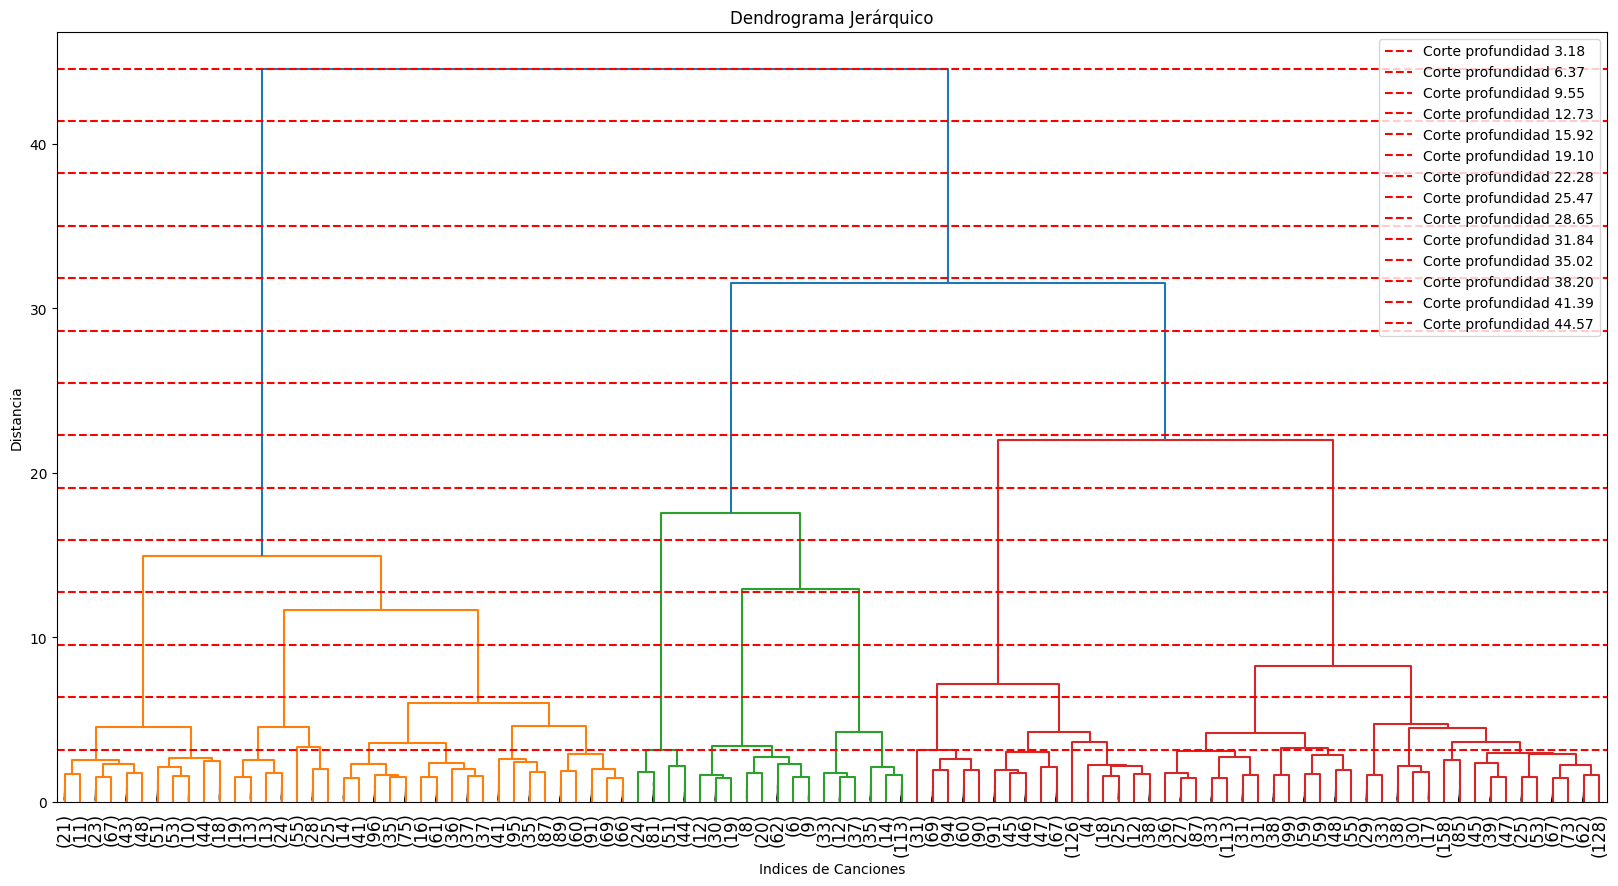

In [107]:
# Mostramos el dendograma
dibujar_dendograma(linkage_matrix_ward)

Con esto, podemos sacar algunas conclusiones:
- Cortes con distancias mayores a 6 `no generan suficientes clústers.`
- Cortes con distancias menores a 3 `generan demasiados clústers.`
- Entre 3 y 6 `se ven clústers razonables, asi que este es nuestro punto de partida a analizar.`

Ahora, vamos a ver el tamaño de los clústers en esas profundidades:

In [108]:
# Funcion que imprime el tamaño de los clusters segun una matriz de distancias precalculada
def mostrar_tamanio_clusters(linkage_matrix, tamanio_profundidad=15):

    # Obtenemos las distancias minima y maxima
    min_dist, max_dist = obtener_distancias_dendograma(linkage_matrix)

    # Obtenemos las distancias
    distancias_dendograma = np.linspace(min_dist, max_dist, tamanio_profundidad)[1:]  # Asi evitamos distancia 0

    # Recorremos las distancias pribadas
    for distancia in distancias_dendograma:

        # Sacamos los clusters
        etiquetas = fcluster(linkage_matrix, distancia, criterion='distance')

        # Si los clusters son muchos o son pocos (minimo 10), descartamos
        if 50 > np.unique(etiquetas).size > 9:

            # Formamos una serie para ver los datos
            distribucion = pd.Series(etiquetas).value_counts().sort_index()

            # Mostramos los tamaños
            print('=' * 50)
            print(f"{distancia:.2f} de distancia de corte → tamaños:", distribucion.values)
            print(f'Total de clusters: {len(distribucion.values)}')

In [109]:
# Mostramos los tamaños de los clusters
mostrar_tamanio_clusters(linkage_matrix_ward)

3.18 de distancia de corte → tamaños: [213 176  69  55  53 261 187 258 375 200  61 105  82 162 344 296 126  97
 358 137 221  62  85 243 539]
Total de clusters: 25
6.37 de distancia de corte → tamaños: [ 389  177 1081  200  166  244  344  519  716  929]
Total de clusters: 10


Con esto, podemos decir lo siguiente:
- Con una distancia de 3.18, creemos que `generamos los suficientes clústers (ni muchos ni pocos).`
- Con distancia de 6.37, son `clústers muy cortos (solo 10, cuando pueden existir más de 9).`

Vamos a analizar la uniformidad de estos clústers a ver si la profundidad importa. Aunque ya tenemos una idea, verlo gráficamente es mejor:

In [110]:
# Funcion que muestra un grafico de barras para ver la uniformidad de los clusters
def mostrar_uniformidad_clusters(linkage_matrix, tamanio_profundidad=15):
    
    # Obtenemos las distancias minima y maxima
    min_dist, max_dist = obtener_distancias_dendograma(linkage_matrix)

    # Obtenemos las distancias
    distancias_dendograma = np.linspace(min_dist, max_dist, tamanio_profundidad)[1:]  # Asi evitamos distancia 0

    # Tamaño del grafico
    tamanio_grafico = distancias_dendograma.shape[0]

    # Graficamos los 2 graficos de barras
    fig, axes = plt.subplots(tamanio_grafico, 1, figsize=(20, tamanio_grafico * 5))

    # Graficamos en ccada uno cada gráfico
    for axe, distancia in zip(axes, distancias_dendograma):

        # Sacamos los labels
        etiquetas = fcluster(linkage_matrix, distancia, criterion='distance')

        # Agrupamos y contamos
        tamanio_clusters = pd.Series(etiquetas).value_counts().sort_index()

        # Graficamos el grafico de barras
        axe.bar(tamanio_clusters.index, tamanio_clusters.values, edgecolor='black')
        axe.set_xlabel(f'clusters')
        axe.set_ylabel('Tamanio clusters')
        axe.set_title(f'Tamanio de clusters con distancia de {distancia:.2f}')

    # Mostramos todo
    plt.tight_layout()
    plt.show()

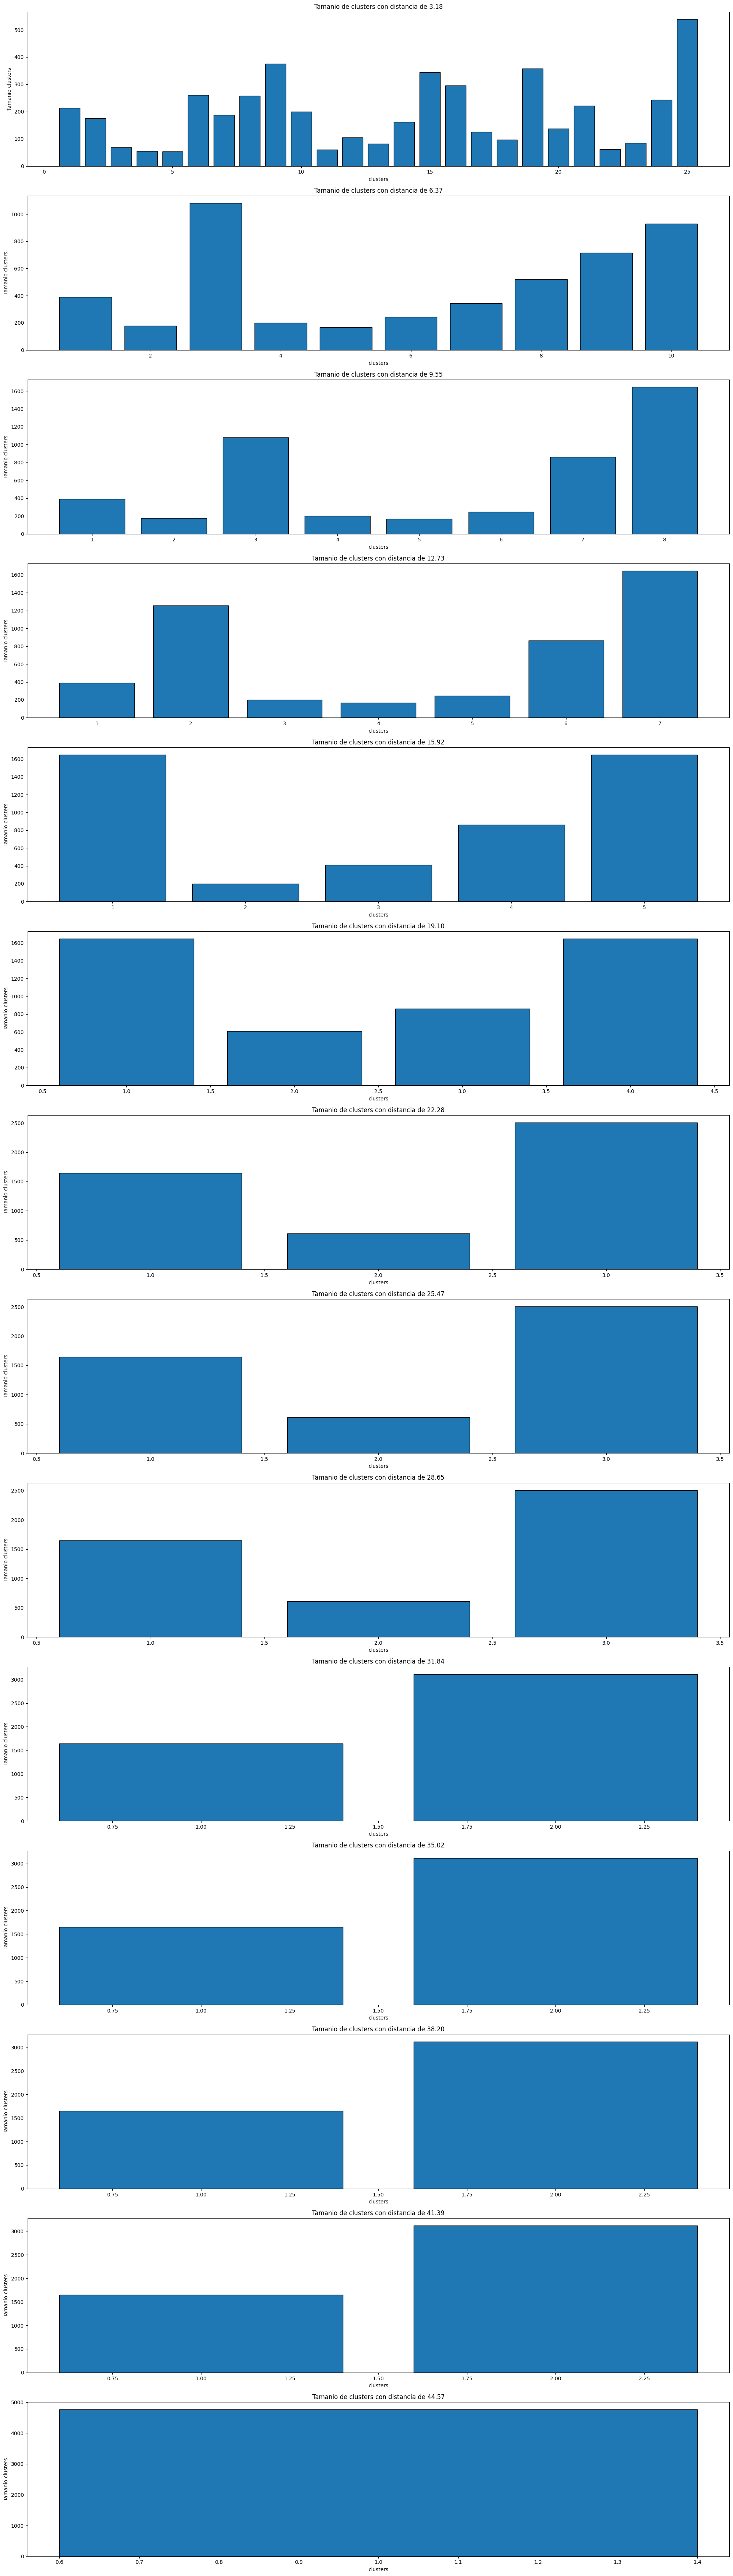

In [111]:
# Mostramos el grafico
mostrar_uniformidad_clusters(linkage_matrix_ward)

Respondiendo a la pregunta de :`¿Es uniforme la distribución independientemente de la profundidad?` Viendo este gran gráfico podemos decir esto:

Observando el gráfico de barras con los tamaños de clúster a distintas distancias de corte, la respuesta es **NO**. La uniformidad no es constante, sino que depende críticamente de la profundidad (altura del corte):

1.  **A mayor profundidad (Distancias bajas, ej: 3.18):** Observamos la **mayor uniformidad**. Las barras tienen alturas bastante homogéneas (la mayoría entre 100 y 350 muestras). Aquí el algoritmo Ward logra un reparto 'equilibrado'.
2.  **A profundidad media (Distancias intermedias, ej: 9.55 - 19.10):** La uniformidad **se degrada notablemente**. Aparecen clústers dominantes, conviviendo con grupos residuales muy pequeños. Es el punto de mayor desequilibrio.
3.  **A poca profundidad (Distancias altas, ej: >22):** Aunque los grupos más pequeños terminan fusionándose, el desbalance estructural se mantiene.

**Conclusión:**

`La uniformidad NO es independiente de la profundidad.`

In [112]:
# Funcion que mostrará todo el analisis del dendograma
def analisis_completo_dendigrama(linkage_matrix, tamanio_profundidad=15):

    # Graficamos el dendograma
    dibujar_dendograma(linkage_matrix, tamanio_profundidad)

    # Mostramos el grafico de barras para ver profundidad
    mostrar_uniformidad_clusters(linkage_matrix, tamanio_profundidad)

    # Mostramos los tamanios de los clusters
    mostrar_tamanio_clusters(linkage_matrix, tamanio_profundidad)

#### **Para la coseno**
Aunque sea malo, para hacer este apartado, vamos a analizarlo. Recordemos que `complete` era quien lo hacia algo mejor:

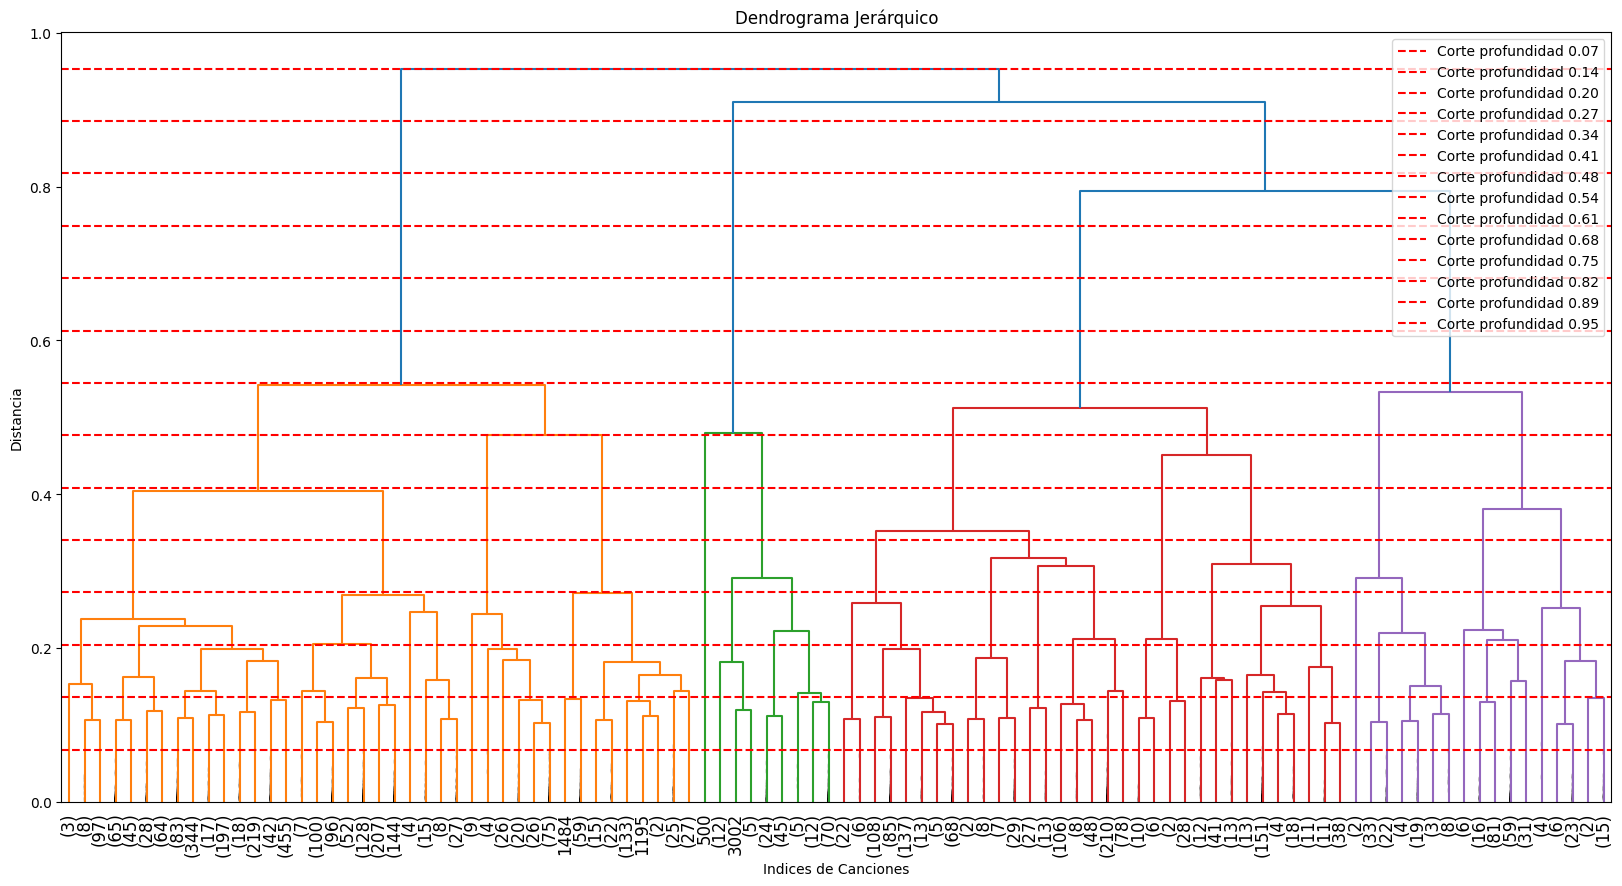

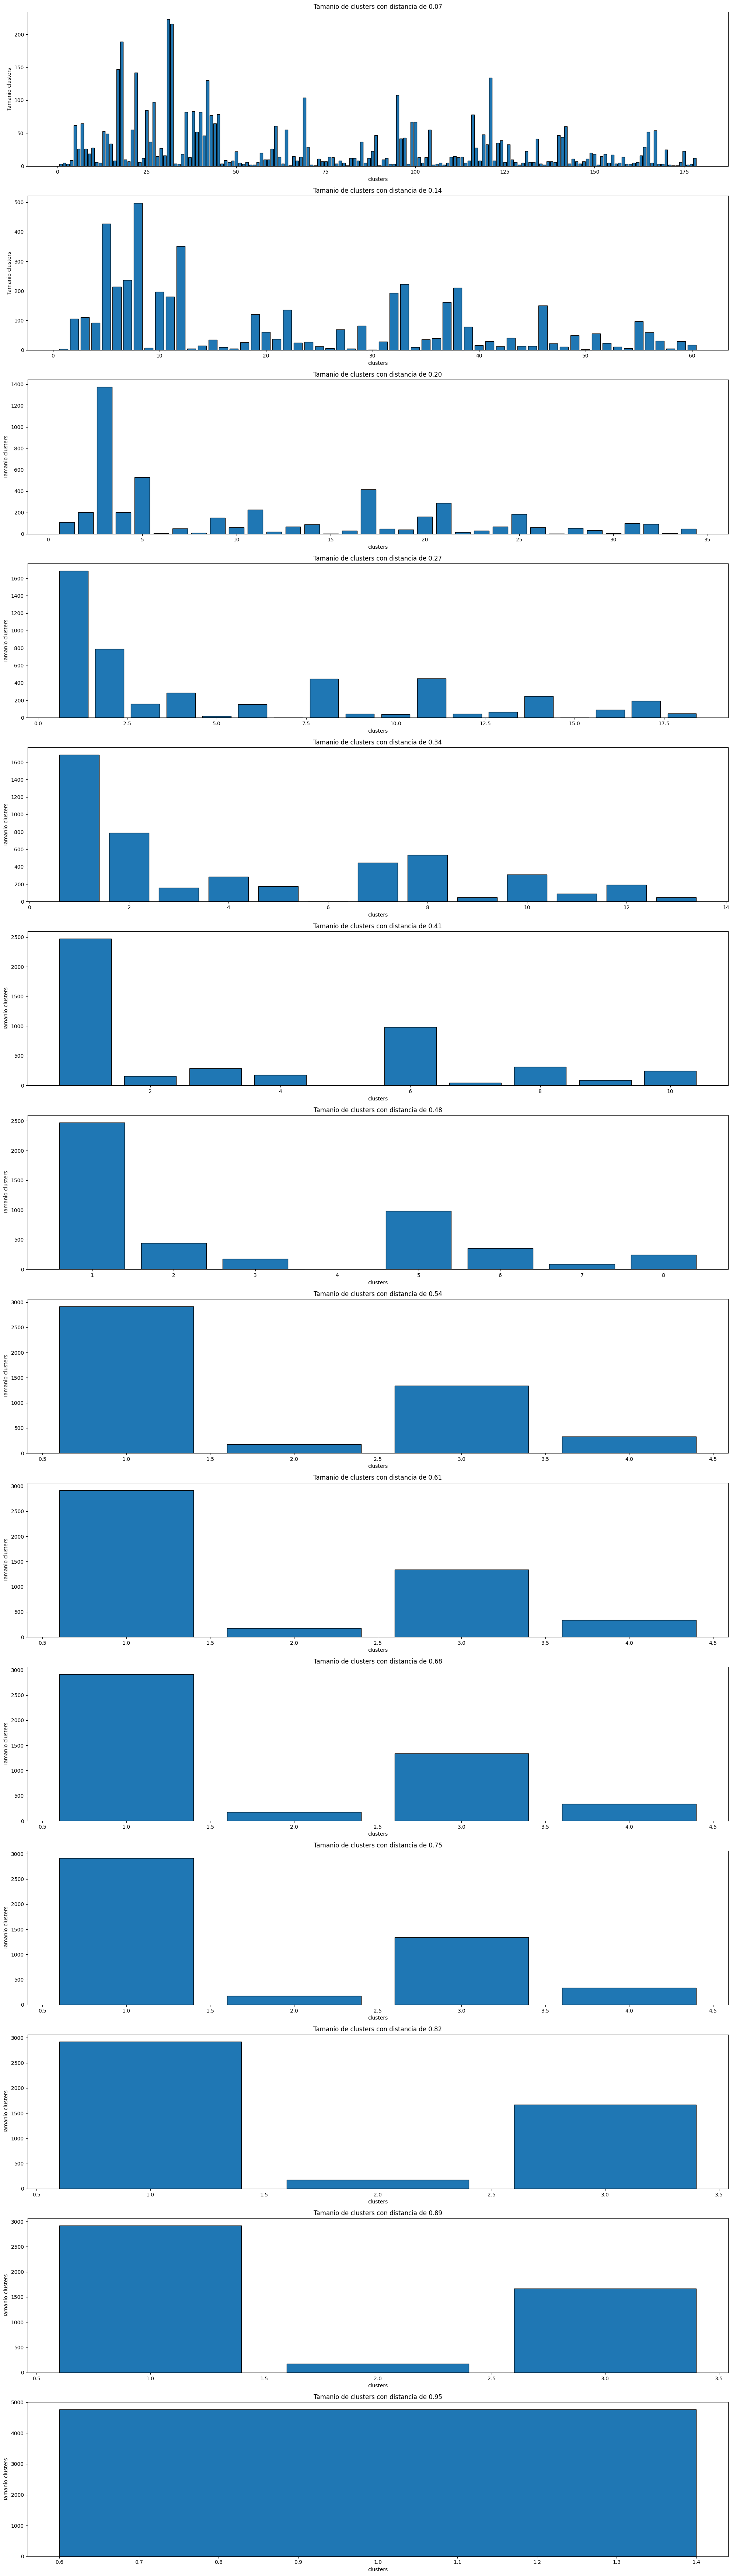

0.20 de distancia de corte → tamaños: [ 108  202 1375  203  531    4   50    9  151   60  225   18   69   87
    1   28  416   46   40  162  288   16   30   66  186   60    2   55
   34    6   97   90    4   46]
Total de clusters: 34
0.27 de distancia de corte → tamaños: [1685  788  160  285   18  156    1  444   46   40  450   46   66  246
    2   89  193   50]
Total de clusters: 18
0.34 de distancia de corte → tamaños: [1685  788  160  285  174    1  444  536   46  312   91  193   50]
Total de clusters: 13
0.41 de distancia de corte → tamaños: [2473  160  285  174    1  980   46  312   91  243]
Total de clusters: 10


In [113]:
# Calculamos la estructura del árbol (Linkage)
linkage_matrix_cosine = linkage(dataset_spotify_preprocesado, method='complete', metric='cosine')

# Hacemos el analisis
analisis_completo_dendigrama(linkage_matrix_cosine)

Analizada las profundidades del dendograma, podemos sacar lo siguiente:
- Los clústers `están muy desvalanceados:` Siempre hay unos cuantos que dominan frente a otros.
- Esto confirma que la uniformidad **es dependiente de la profundidad.** Es verdad que casi nunca (por no decir nunca), se ve uniformidad debido a la dominancia de algunos clústers.
- Solo 2 distancias forman clústers 'aceptables': Con 0.27, formando 18 clústers y con 0.34, formando 13. En ambos, siempre `hay un clúster dominante.`
- Mientras `menos profundidad, más gigantes serán los clúster dominante.`

Con todo esto, `la distribución con coseno y average NO es uniforme, y no se puede lograr una uniformidad ni con distintas profundidades debido a la dominancia de un clúster.`

#### **Para la manhattan**
Sabemos que quien mejor rindió fue **complete.** Con ello, vamos a `elegir los cortes (profundidad) a analizar para tenerlo todo de una.` Al tener todo ya automatizado, miremos todo de una:

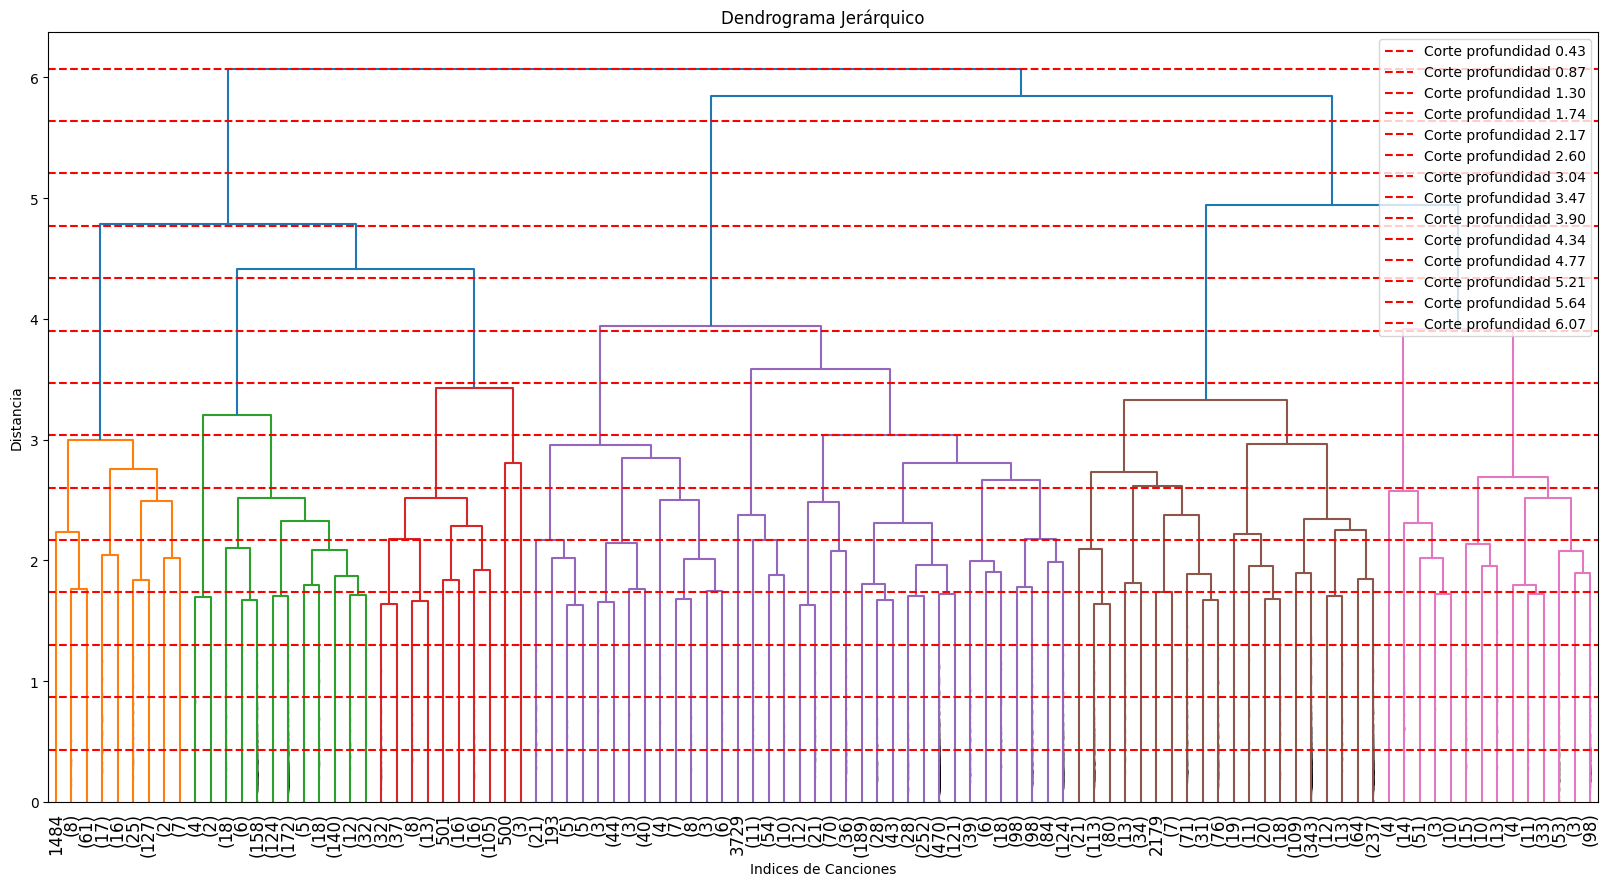

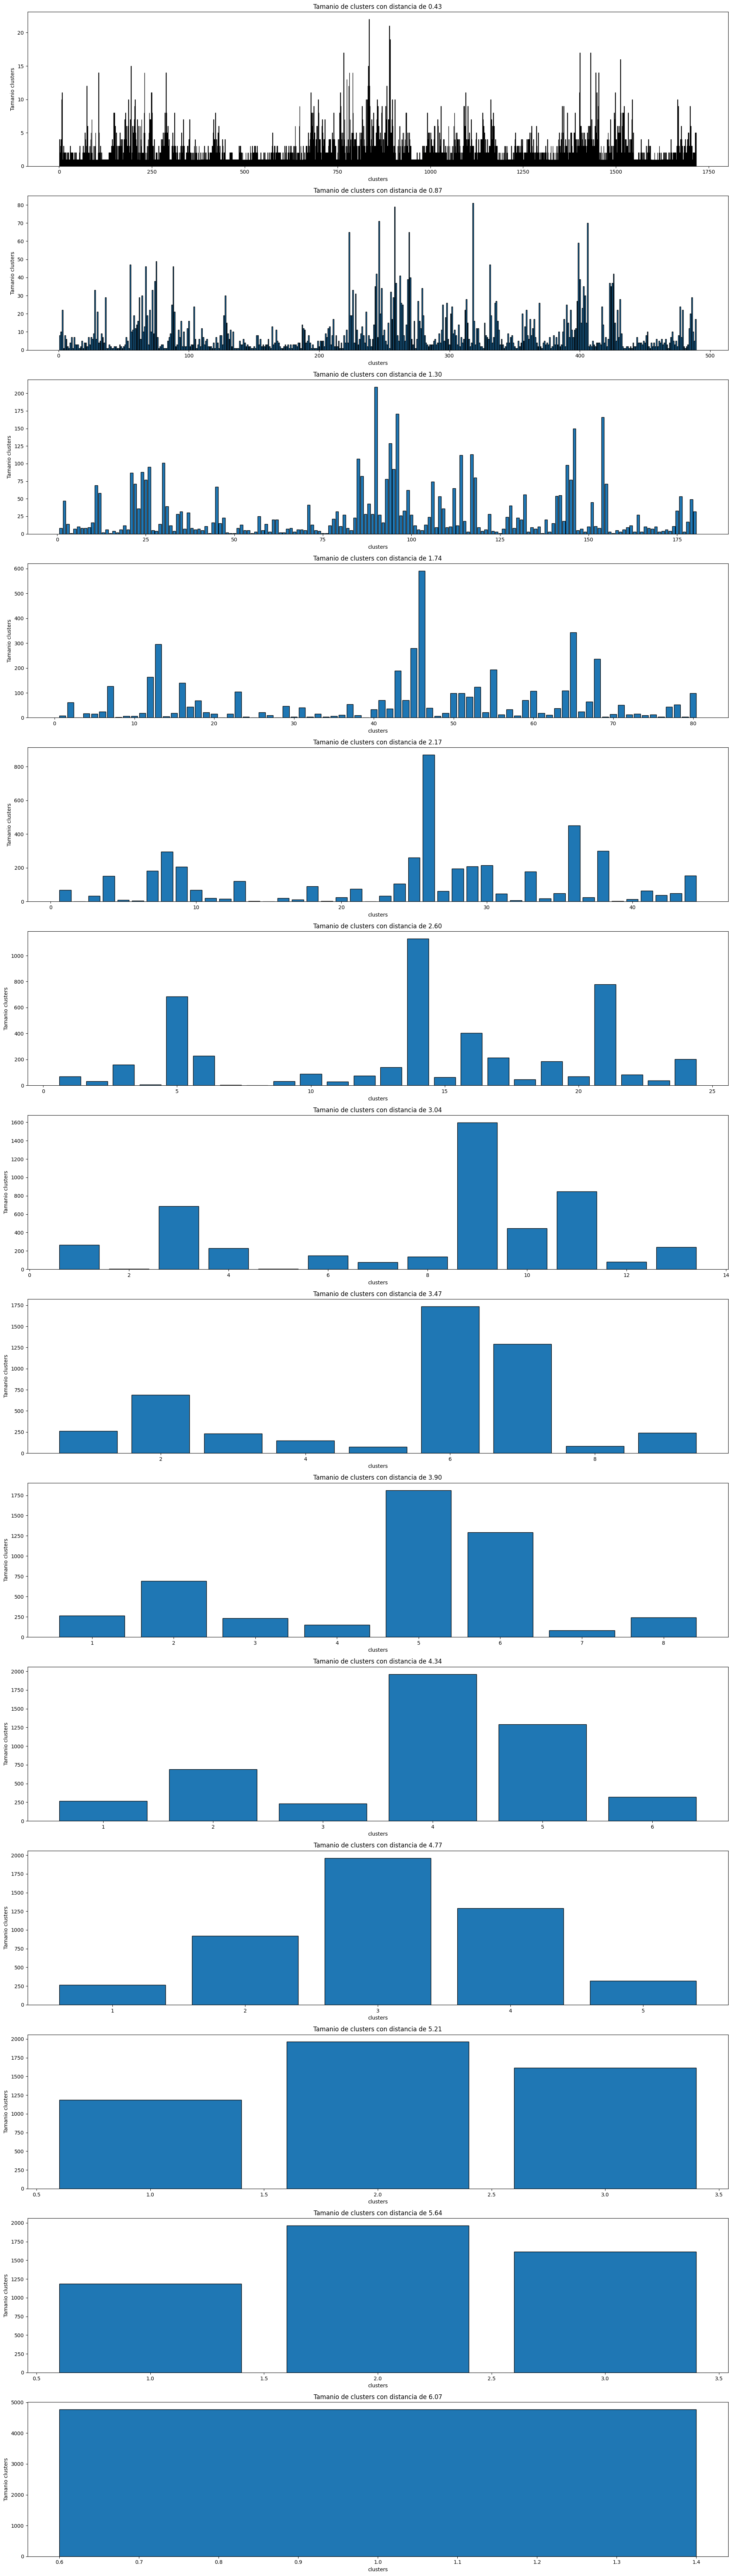

2.17 de distancia de corte → tamaños: [ 69   1  33 152   9   6 182 296 207  69  21  17 121   3   1  21  11  90
   4  24  75   1  33 106 260 871  63 196 208 214  47   8 178  19  49 452
  25 301   4  14  64  38  48 154]
Total de clusters: 44
2.60 de distancia de corte → tamaños: [  70   33  161    6  685  228    3    1   32   90   28   76  139 1131
   63  404  214   47  186   68  778   82   38  202]
Total de clusters: 24
3.04 de distancia de corte → tamaños: [ 264    6  685  228    4  150   76  139 1598  447  846   82  240]
Total de clusters: 13


In [114]:
# Calculamos la estructura del árbol (Linkage)
linkage_matrix_manhattan = linkage(dataset_spotify_preprocesado, method='complete', metric='cityblock')  # Asi se llama ahora manhattan: 'cityblock'

# Hacemos el analisis
analisis_completo_dendigrama(linkage_matrix_manhattan)

Viendo y analizando las profundidades, podemos concluir lo siguiente:
- Pasa algo parecido que con coseno, pero en mucha menor medida: `Clústers dominantes y clústers muy pequeños.`
- Solo 2 distancias nos dan **clústers razonables:** Con 2.60, tenemos 24, lo cual en verdad `es algo grande (aunque es el que tiene menos dominancia).` Con 3.04, tenemos 13, lo cual `son muy pocos clústers.`
- Y lo mismo que con coseno: `Mientras menos profundidad, más grande es el clúster dominante, y más pequeños son los clústers pequeños.` Obviamente en menor medida.

En general, los 24 clústers podrían ser coherentes, pero que haya grupos que no llegan **ni a las 2 cifras puede significar problemas (incluso existiendo un clúster de 1 dato).** En conclusión, `La distribución de los clústers NO es uniforme, y no depende de la profundidad, ya que casi siempre, por la existencia de clústers dominantes y clústers muy pequeños, no se podrá lograr la uniformidad.`

#### **Para la chebishev**
No analizaremos esta ya que dio malos resultados (fue incluso peor que coseno al formar 2 o 3 super clústers, cosa que al menos con complete no hacia tanto cosine).

#### **Conclusión final**
Respondiendo a la pregunta planteada: `La distribución NO es uniforme independientemente de la profundidad ni del algoritmo.`

La uniformidad es una propiedad que depende críticamente **de la función de enlace (Linkage) utilizada:**
* Con métodos que minimizan la varianza (Ward), la distribución `tiende a ser uniforme y estable a medida que aumentamos la profundidad.`
* Con métodos basados en promedios (Average), la distribución `es altamente irregular,` mostrando una fuerte dependencia de la profundidad donde los clusters dominantes crecen desproporcionadamente (efecto bola de nieve) y los clusters pequeños (ruido) no logran integrarse.

Por tanto, para obtener una distribución uniforme útil para negocio, es imprescindible descender a una profundidad media-alta (10-15 clusters) y utilizar métodos de varianza mínima como Ward.

### **Tarea 1.3**
Nos piden: **`¿Cómo afectan las diferentes métricas de distancia a la estructura del dendrograma?`**

Como ya hemos hecho el análisis de cada profundidad, solo vamos a mostrar los dendogramas de cada una:

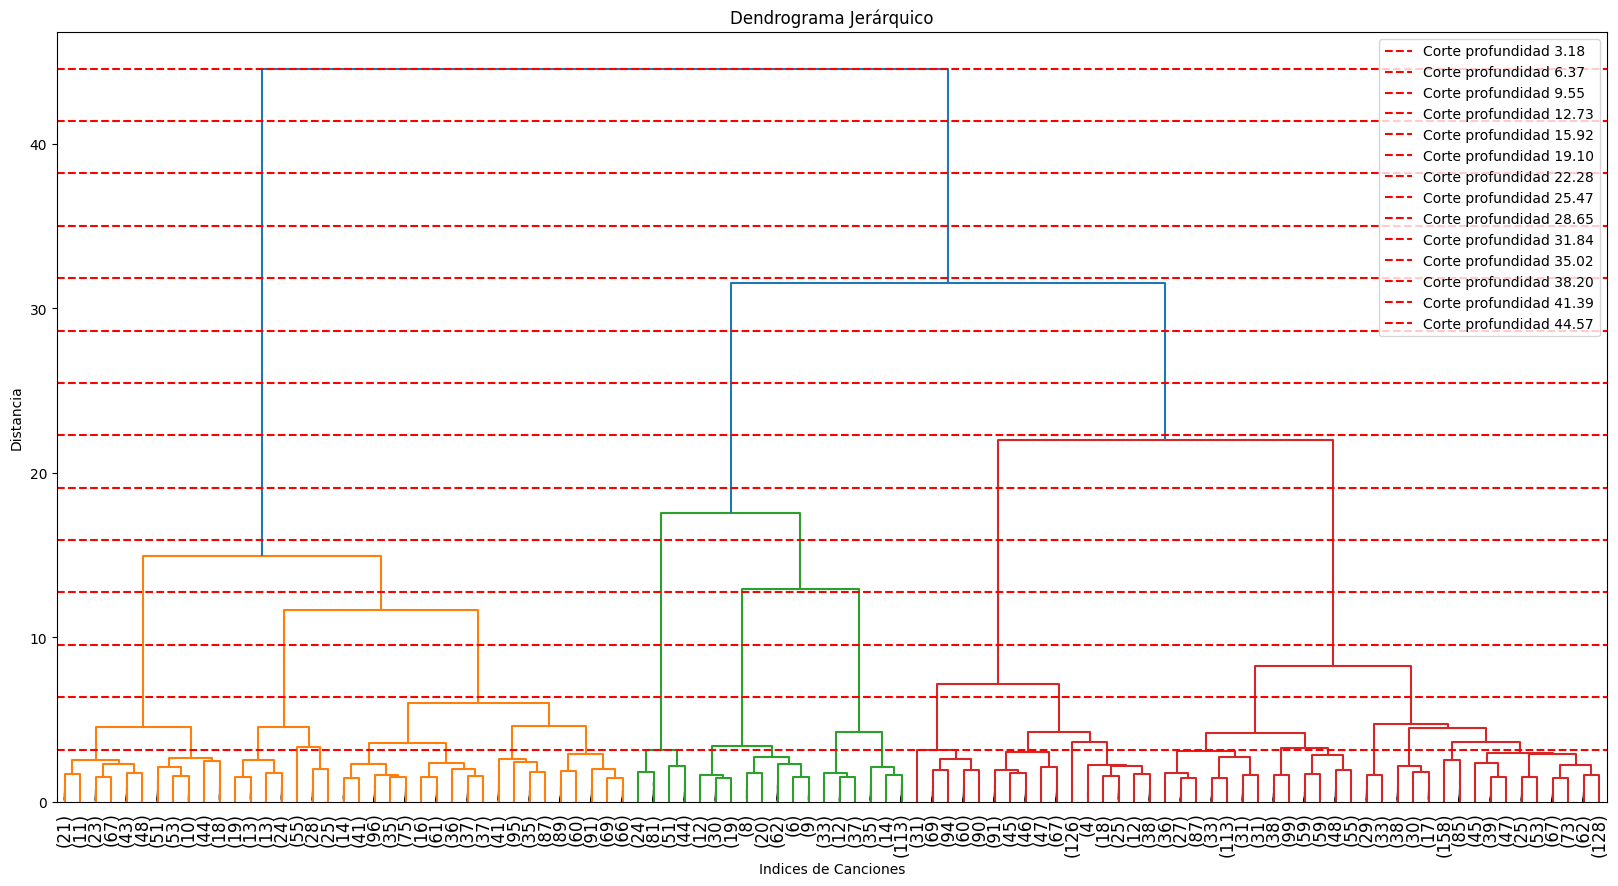

In [115]:
# Dendograma de ward
dibujar_dendograma(linkage_matrix_ward)

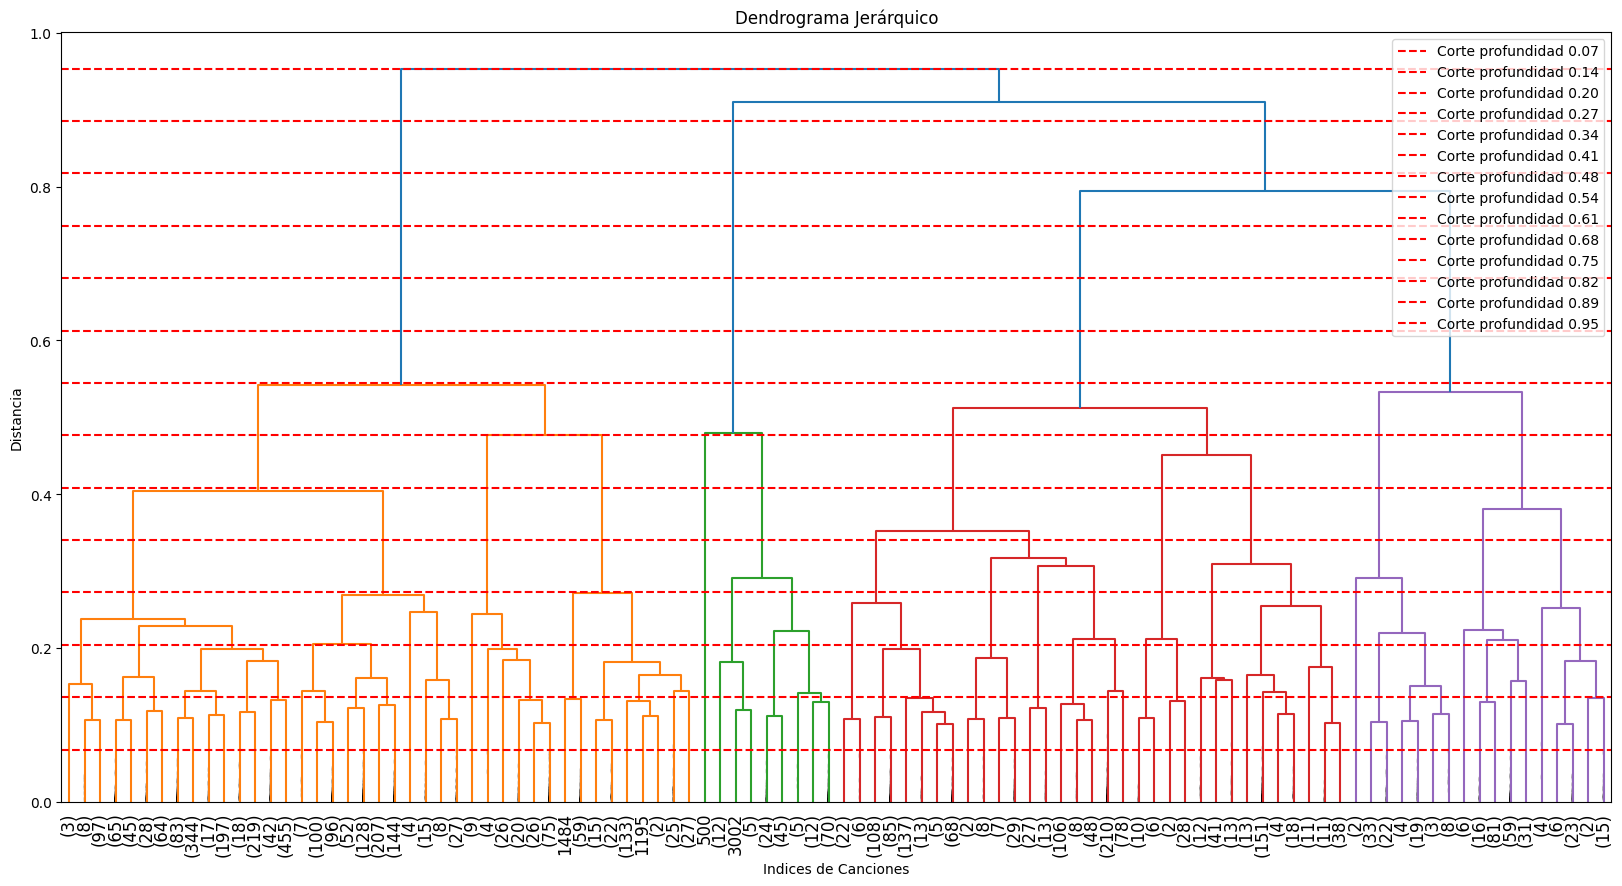

In [116]:
# Dendograma de cosine
dibujar_dendograma(linkage_matrix_cosine)

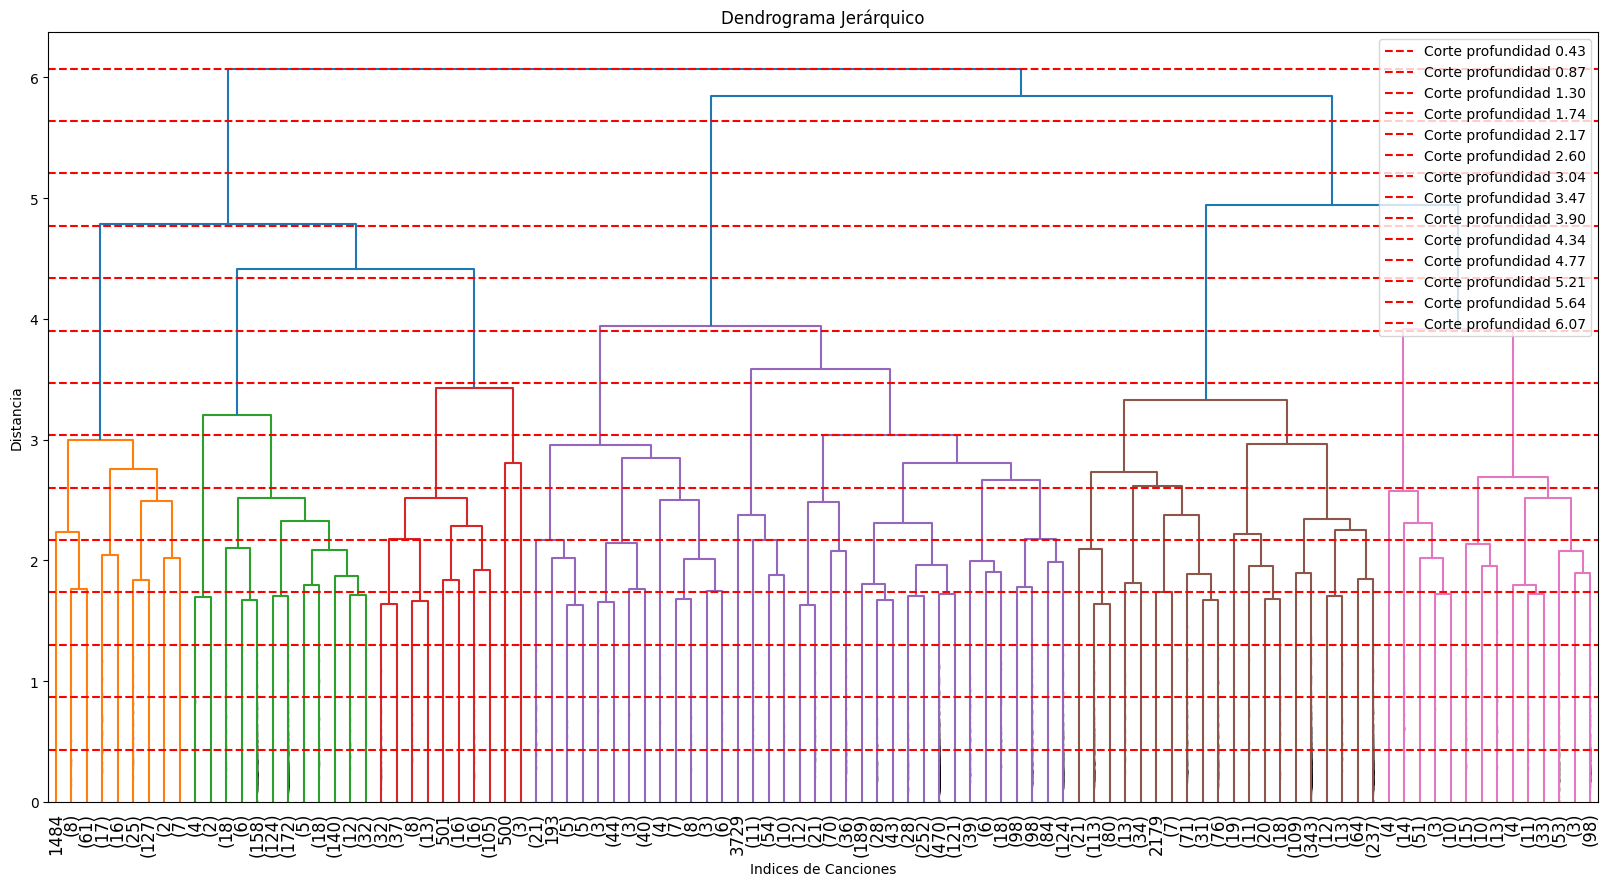

In [117]:
# Dendograma de manhattan
dibujar_dendograma(linkage_matrix_manhattan)

Esto ya casi lo hemos respondido sin querer en 1.2:
- Con la distancia `euclídea,` vemos que 'rápidamente' logra detectar un clúster, y en el otro lado, pues `los clústers tardan en fusionarse.` Esto se debe más al linkage **ward,** que intenta minimizar varianzas al fusionar clústers. Por eso vemos que un grupo se fusiona relativamente rápido, mientras que los demás demmoran.
- Con `coseno,` se ve que esto no ocurre: Los clústers `demoran algo más en fusionarse.` Necesitamos algo más de profundidad para que se fusionene. Es verdad que la parte de la izquierda logra fusionarse algo más rápido, pero aún así demora un poco. Como coseno mira `similidad entre vectores,` pues eso proboca que al final **pueda haber clústers dominantes debido a muchas similitudes,** lo cual absorve a los demás datos.
- Con `manhattan,` a pesar de ser el valor absoluto en vez del cuadrado de las distancias, `es quien más le cuesta fusionar clústers.` Necesitamos una gran profundidad para poder fusionar clústers. En cuanto a por qué genera clústers dominantes, como al no elevar al cuadrado hace que **no se penalice tanto las distancias,** es más fácil absorver datos.

Lo que ayuda a la distancia euclídema, a parte de `penalizar más las distancias que son algo más lejanas,` es el hecho de que **ward minimiza las distancias inter-clúster, para que la varianza en los clústers no aumente.** Este puede ser el motivo por el cuál funciona mejor con los datos.

### **Tarea 1.4**
Nos piden: **`Utiliza por lo menos dos índices de calidad de clustering y y analiza sus resultados.`**

Vamos a probar 2 métricas de calidad: Primero, la `Calinski,` ya que **mira la dispersión entre clústers comparado con la dispersión de los clústers,** evaluando que la dispersión de los clústers sea menor que la dispersión entre los clústers.

Probaremos luego el `silueta,` ya que este mira si **los puntos deberían de pertenecer a su clúster o al clúster más cercano.**

#### **Calinski**
Este nos indica que `si mayor es el resultado mejor son los clústers,` al ser estos poco dispersos y muy dispersos entre sí. Vamos a probarlo, viendo los resultados obtenidos:

##### **Evaluando la euclídea-ward**
Vamos a evaluar, de momento, el que creemos la `mejor configuración:`

In [118]:
# Resultados de euclidea ward
resultados_euclidea_ward = {key: value for key, value in resultados_euclidea.items() if 'euclidean_ward' in key}
resultados_euclidea_ward

{'6_clusters_euclidean_ward': array([1, 0, 1, ..., 3, 5, 3], shape=(4765,)),
 '7_clusters_euclidean_ward': array([0, 3, 0, ..., 1, 5, 1], shape=(4765,)),
 '8_clusters_euclidean_ward': array([2, 7, 2, ..., 1, 5, 1], shape=(4765,)),
 '9_clusters_euclidean_ward': array([2, 7, 2, ..., 0, 5, 0], shape=(4765,)),
 '10_clusters_euclidean_ward': array([0, 7, 0, ..., 5, 2, 9], shape=(4765,)),
 '11_clusters_euclidean_ward': array([1, 7, 1, ..., 5, 2, 9], shape=(4765,)),
 '12_clusters_euclidean_ward': array([0, 7, 0, ..., 5, 2, 9], shape=(4765,)),
 '13_clusters_euclidean_ward': array([12,  7, 12, ...,  2,  0,  9], shape=(4765,)),
 '14_clusters_euclidean_ward': array([12,  3, 12, ...,  2,  7,  9], shape=(4765,)),
 '15_clusters_euclidean_ward': array([12,  1, 12, ...,  2,  7,  9], shape=(4765,)),
 '16_clusters_euclidean_ward': array([12,  0, 12, ...,  2,  7,  9], shape=(4765,)),
 '17_clusters_euclidean_ward': array([12, 14, 12, ...,  0,  7,  9], shape=(4765,)),
 '18_clusters_euclidean_ward': array([

In [119]:
# Funcion que muestra los resultados calinski y silueta
def evaluar_indices_calidad(X, dict_clusters, show_calinski=True, show_silueta=True):

    # Guardamos resultados
    resultados = list()

    # Guardamos los numeros de clusters
    num_clusters = list()

    # Definimos por default los scores
    calinski = np.nan
    silueta = np.nan

    # Evaluamos cada cluster que probamos
    for nombre, labels in dict_clusters.items():

        # Calculamos calinsky
        if show_calinski:
            calinski = calinski_harabasz_score(X, labels)

        # Calculamos silueta
        if show_silueta:
            silueta = silhouette_score(X, labels)

        # Almacenamos resultados
        resultados.append({
            'calinski_harabasz': calinski,
            'silueta': silueta
        })

        # Almacenamos indices
        num_clusters.append(len(set(labels)))

    # Creamos un df con los resultados
    resultados_metricas = pd.DataFrame(resultados, index=num_clusters)

    # Borramos los nulos (si solo vimos una metrica)
    resultados_metricas = resultados_metricas.dropna(axis=1)

    # Lo devolvemos
    return resultados_metricas

In [120]:
# Vemos los resultados de calinski
resultados_calinski_ward = evaluar_indices_calidad(dataset_spotify_preprocesado, resultados_euclidea_ward, show_silueta=False)
resultados_calinski_ward

,calinski_harabasz
6,2596.214821
7,2543.787347
8,2516.284084
9,2376.282137
10,2243.202364
11,2108.516140
12,1969.622128
13,1854.140718
14,1757.074508
15,1675.709061


Vamos a ver los resultados gráficamente:

In [121]:
# Funcion que grafica los resultados
def dibujar_resultados_metricas(X, dict_clusters, show_calinski=True, show_silueta=True):

    # Obtenemos los resultados
    resultados_metricas = evaluar_indices_calidad(X, dict_clusters, show_calinski, show_silueta)

    # Hacemos el lienzo
    fig, axes = plt.subplots(resultados_metricas.shape[1], 1, figsize=(12, 6 * resultados_metricas.shape[1]))

     # Si solo hay una métrica, lo convertimos en lista
    if resultados_metricas.shape[1] == 1:
        axes = [axes]

    # Dibujamos los resultados
    for axe, columna_metrica in zip(axes, resultados_metricas.columns):

        # Obtenemos la columna de la metrica
        resultado_metrica = resultados_metricas[columna_metrica]

        # Grafico de lineas
        axe.plot(resultado_metrica.index, resultado_metrica)
        axe.set_xlabel('Numero de clusters')
        axe.set_ylabel('Score')
        axe.set_title(f'Resultados {resultado_metrica.name}')

        # Añadimos puntos y etiquetas
        for x, y in zip(resultado_metrica.index, resultado_metrica):

            # Creamos el punto
            axe.scatter(x, y, marker='s')

            # Le ponemos etiqueta
            axe.annotate(f"{y:.2f}", (x, y), textcoords="offset points",xytext=(0, 8), ha='center', fontsize=9)

    # Mostramos graficos
    plt.tight_layout()
    plt.show()

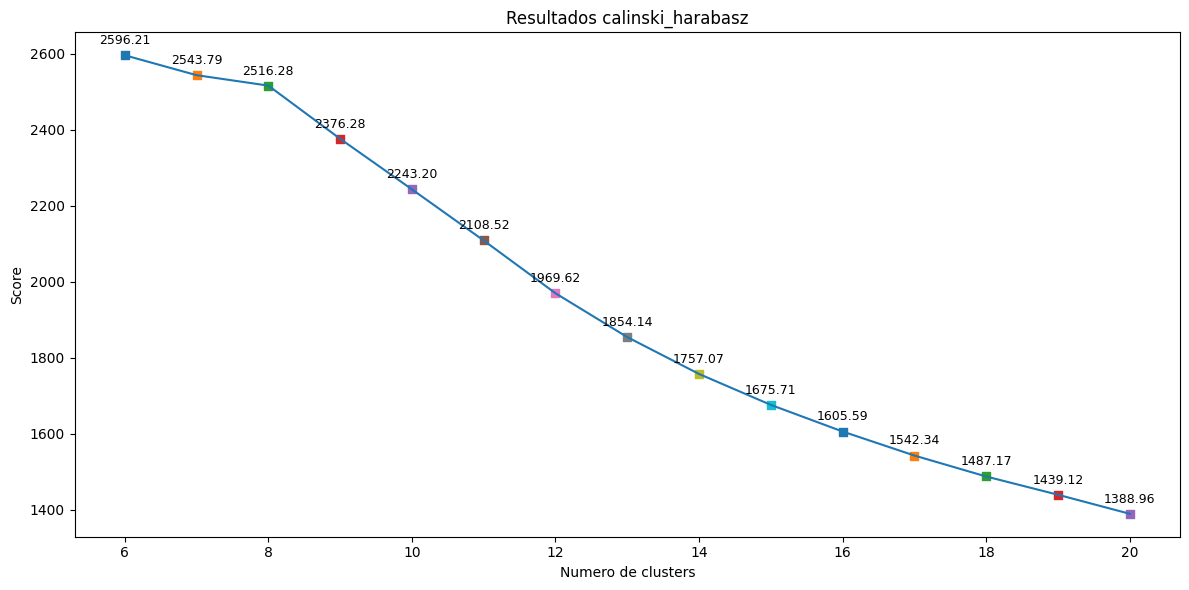

In [122]:
# Mostramos resultados graficamente
dibujar_resultados_metricas(dataset_spotify_preprocesado, resultados_euclidea_ward, show_silueta=False)

Con esto, podemos concluir lo siguiente:
- Mientras `más clústers, peor es el índice.`
- Vemos que ya no baja mucho a partir de 14-15 clústers, pero son **scores 'bajos'.**
- Lamentablemente, aunque **6 clústers son buenos,** al decirlos que `hay muchos más de 6 géneros,` hace pensar que se queda algo justo.

De momento, lo más razonable es pensar que es `7-9 clústers.` Vamos a ver de casualidad los resultados de manhattan, que era en teoría el segundo mejor:

##### **Evaluando la manhattan-complete**
Vamos a evaluar, en teoría, el `segundo mejor:`

In [123]:
# Sacamos los resultados mejores de manhattan
resultados_manhattan_complete = {key: value for key, value in resultados_manhattan.items() if 'manhattan_complete' in key}

# Vemos los resultados de calinski
resultados_calinski = evaluar_indices_calidad(dataset_spotify_preprocesado, resultados_manhattan_complete, show_silueta=False)
resultados_calinski

,calinski_harabasz
6,2362.748079
7,2199.646755
8,2083.205769
9,2002.263608
10,1790.167834
11,1648.593675
12,1509.506445
13,1416.549890
14,1331.138576
15,1274.852441


Y los gráficos:

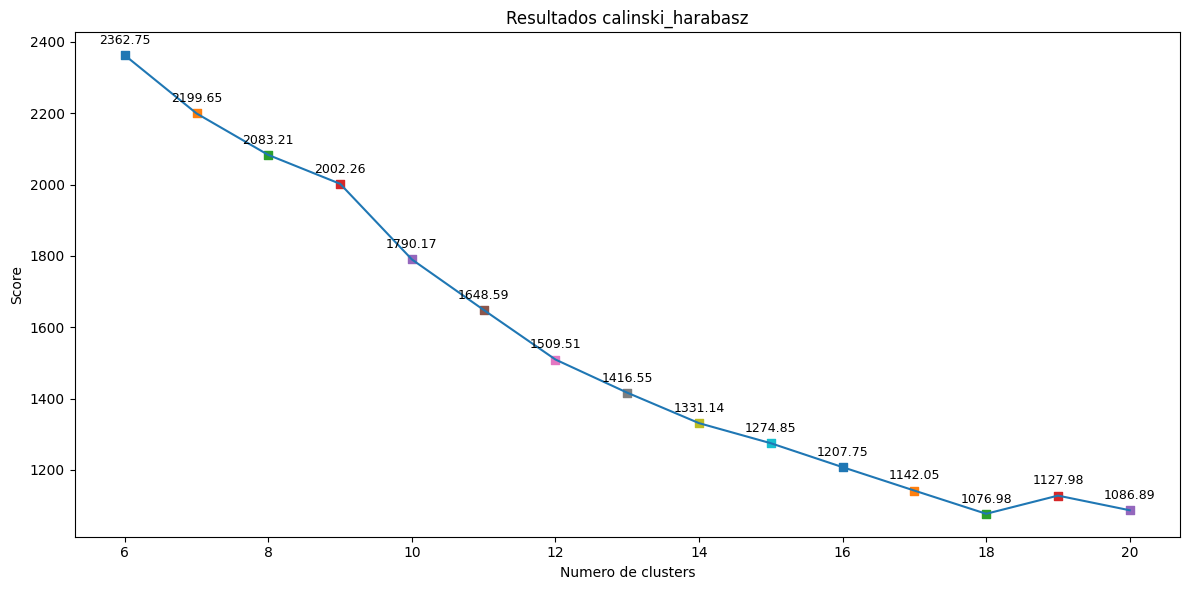

In [124]:
# Mostramos resultados graficamente
dibujar_resultados_metricas(dataset_spotify_preprocesado, resultados_manhattan_complete, show_silueta=False)

Aquí el análisis es más curioso:
- De nuevo, `6 clústers suele ser lo mejor.`
- Similar a ward, con **7-9 clústers logramos un resultado bueno,** aunque el score baja más rápido.
- Igual que antes, `podríamos quedarnos con 6,` pero al ser algo corto, **7-9 clústers con esta distancia sería lo ideal.**

#### **Silueta**
Este nos indica que `si el punto debería de pertenecer a su clúster o al más cercano.` Según lo visto en la asignatura, tenemos estos rangos para ver si los resultados son buenos o no:

- 0.51-0.70, las estructuras encontradas son razonables.
- 0.26-0.50, las estructuras encontradas son débiles y tienen a ser artificiales. Se deberían intentar métodos alternativos para el análisis de los datos.
- < 0.25, no se encuentran estructuras.

Vamos a ver los resultados tanto con ward como con manhattan:

##### **Evaluando la euclídea-ward**

In [125]:
# Vemos los resultados de silueta
resultados_silueta_ward = evaluar_indices_calidad(dataset_spotify_preprocesado, resultados_euclidea_ward, show_calinski=False)
resultados_silueta_ward

,silueta
6,0.358629
7,0.372014
8,0.384848
9,0.285343
10,0.263934
11,0.195775
12,0.196653
13,0.190873
14,0.181985
15,0.178225


Y el gráfico:

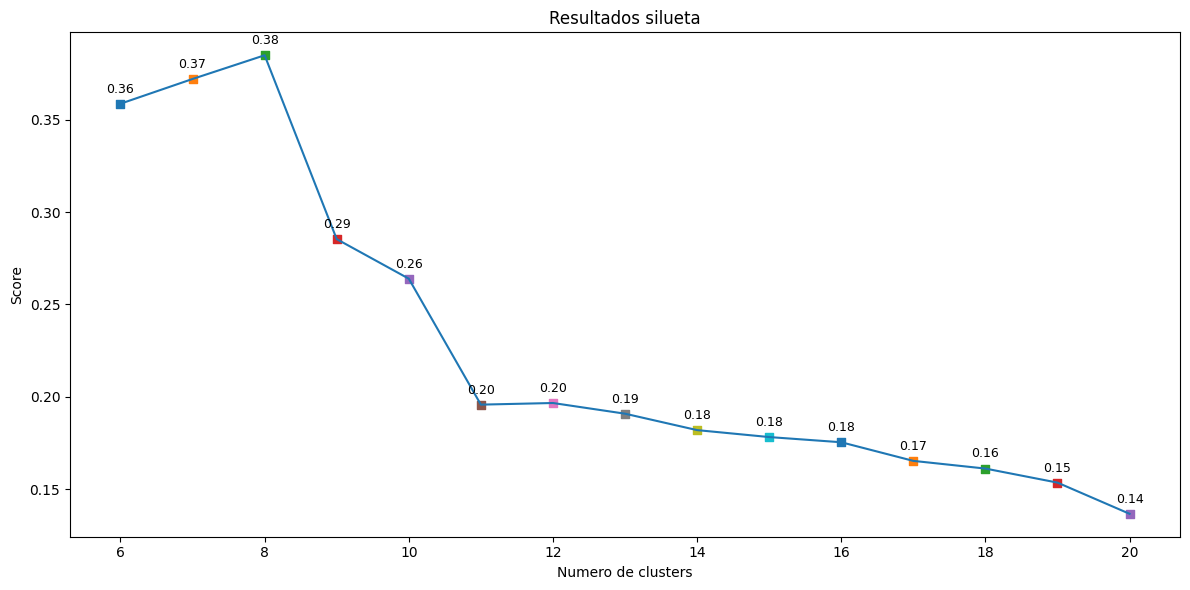

In [126]:
# Mostramos resultados graficamente
dibujar_resultados_metricas(dataset_spotify_preprocesado, resultados_euclidea_ward, show_calinski=False)

Como extra, miraremos `los diagramas de sierra:`

In [127]:
# Funcion que genera los diagramas de sierra
def dibujar_diagrama_sierra(X, dict_clusters):

    # Recorremos los resultados de los clusters usando items para tener la clave y el array
    for clave, clusters in dict_clusters.items():

        # Obtenemos el numero de clusters
        num_clusters = np.unique(clusters).size
        
        # Creamos la figura
        fig, axe = plt.subplots(1, 1, figsize=(15, 10))

        # Calculamos métricas (Individuales y el promedio)
        resultado_silueta_puntos = silhouette_samples(X, clusters)
        silueta_average = np.mean(resultado_silueta_puntos)

        # Diferencia entre sierras (Punto de inicio en el eje Y)
        diferencia_y = 10

        # Recorremos cada cluster
        for i in range(num_clusters):

            # Obtenemos los resultados del silueta de los puntos del cluster i
            resultado_silueta_cluster_i = resultado_silueta_puntos[clusters == i]

            # Lo ordenamos de menor a mayor para crear la forma de sierra
            resultado_silueta_cluster_i.sort()

            # Obtenemos el tamanio del cluster
            tamanio_cluster_i = resultado_silueta_cluster_i.shape[0]

            # Definimos los limites del eje y para cada sierra
            limite_y = diferencia_y + tamanio_cluster_i

            # Obtenemos un color para la sierra
            color = cm.nipy_spectral(float(i) / num_clusters)

            # Coloreamos la sierra
            axe.fill_betweenx(np.arange(diferencia_y, limite_y), 0, resultado_silueta_cluster_i, facecolor=color, edgecolor=color, alpha=0.7)

            # Etiquetamos el cluster
            axe.text(-0.05, diferencia_y + 0.5 * tamanio_cluster_i, str(i))
            
            # Actualizamos para la siguiente sierra dejando un espacio de 10
            diferencia_y = limite_y + 10

        # Ponemos nombres
        axe.set_title(f'Análisis de Silueta: {num_clusters} clusters (Clave: {clave})')
        axe.set_xlabel('Coeficiente de Silueta')
        axe.set_ylabel('Clusters')

        # Línea del promedio (Calculada dinámicamente para cada k)
        axe.axvline(x=silueta_average, color='black', linestyle='--')
        
        # Ajustes de ejes para legibilidad
        axe.set_yticks([]) 
        axe.set_xticks(np.arange(-1, 1.1, 0.2)) 

        # Mostramos el grafico
        plt.show()
        print(f"{clave} -> Score Promedio: {silueta_average:.4f}")

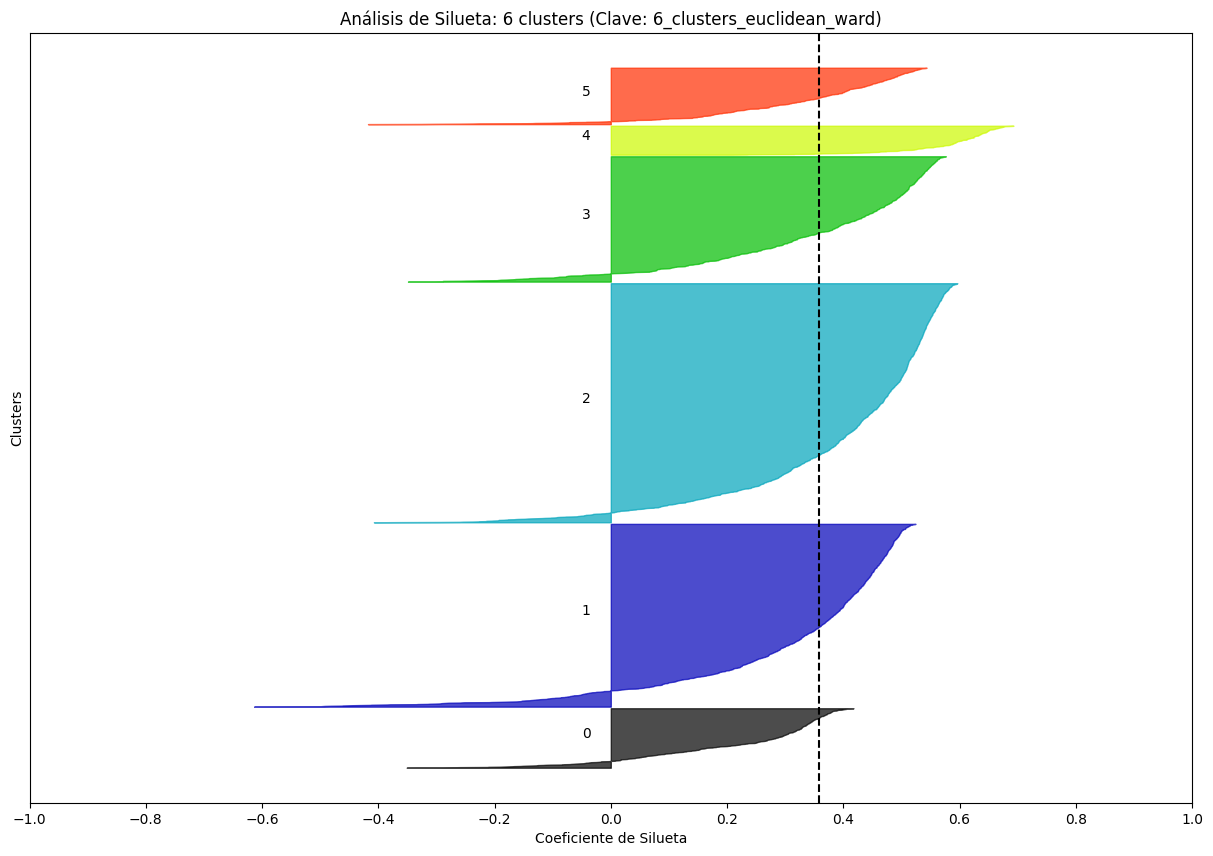

6_clusters_euclidean_ward -> Score Promedio: 0.3586


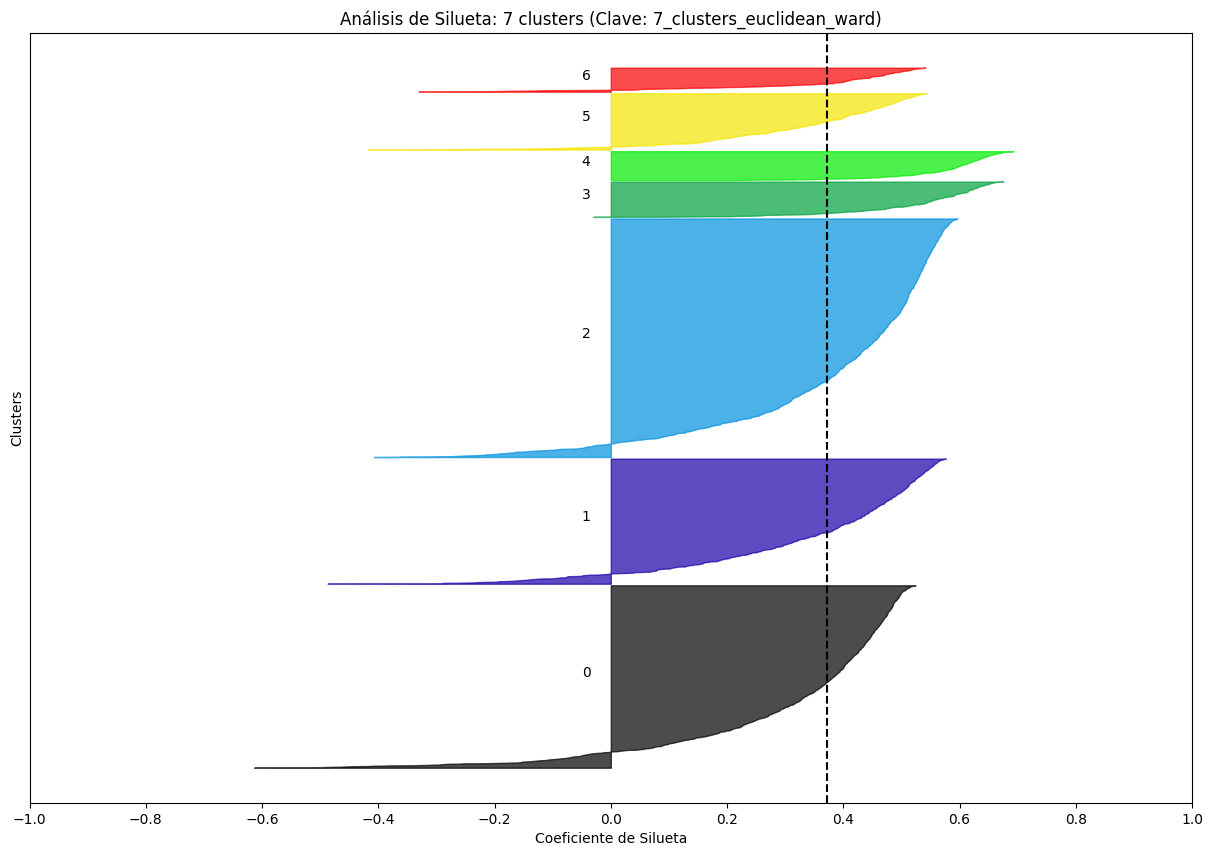

7_clusters_euclidean_ward -> Score Promedio: 0.3720


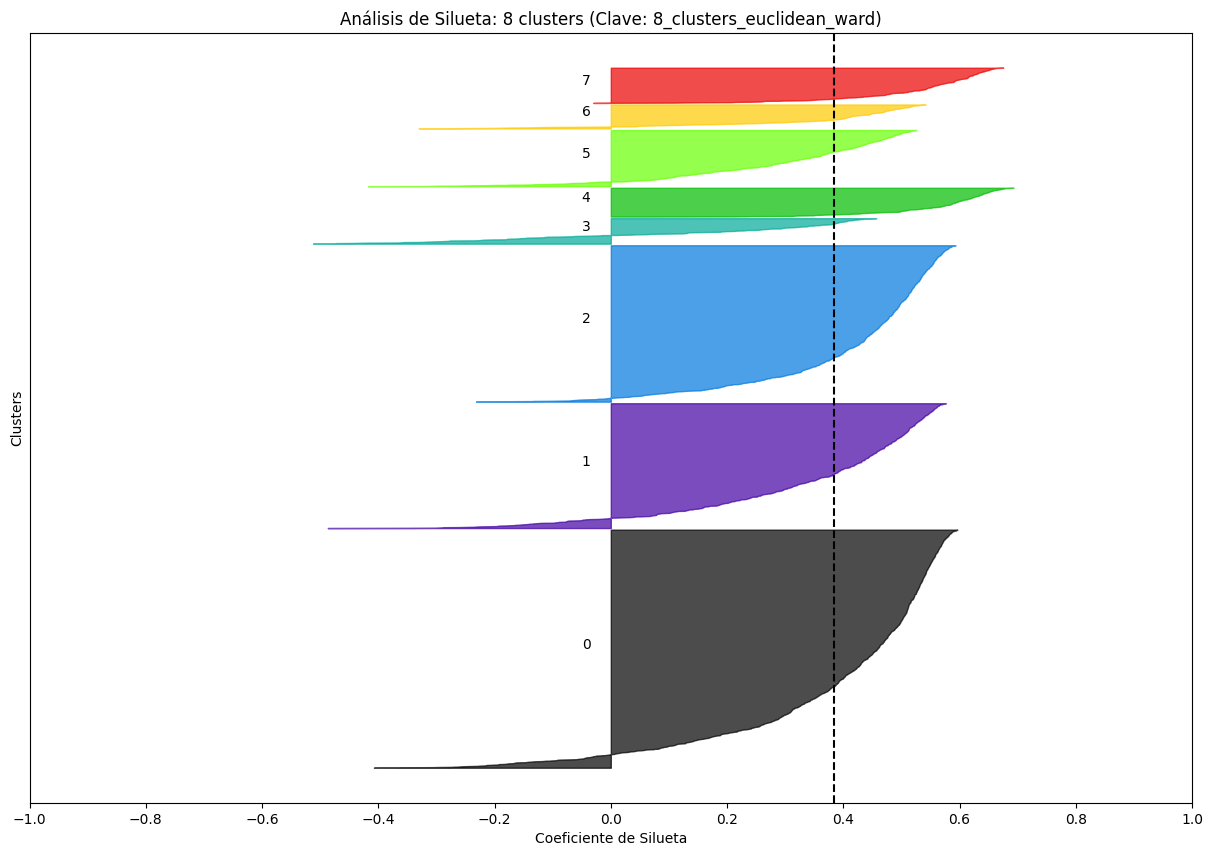

8_clusters_euclidean_ward -> Score Promedio: 0.3848


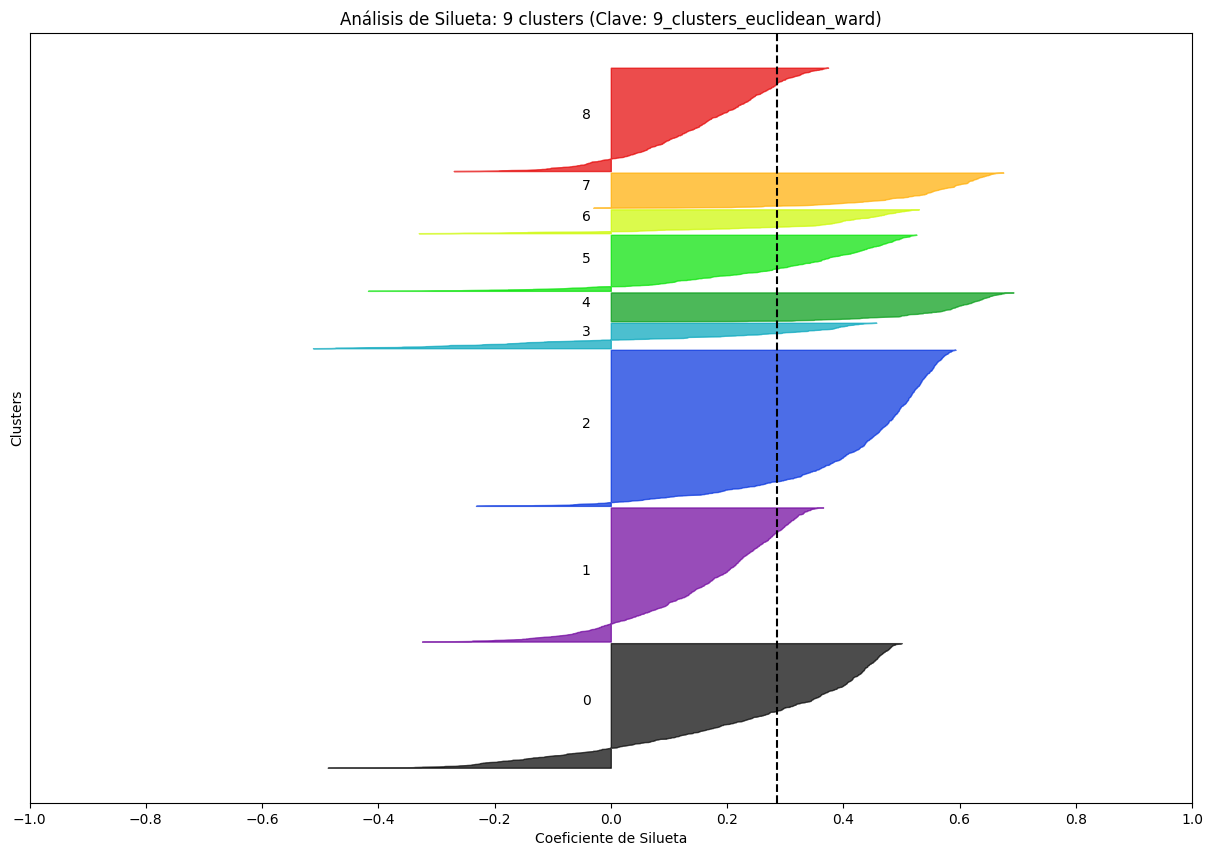

9_clusters_euclidean_ward -> Score Promedio: 0.2853


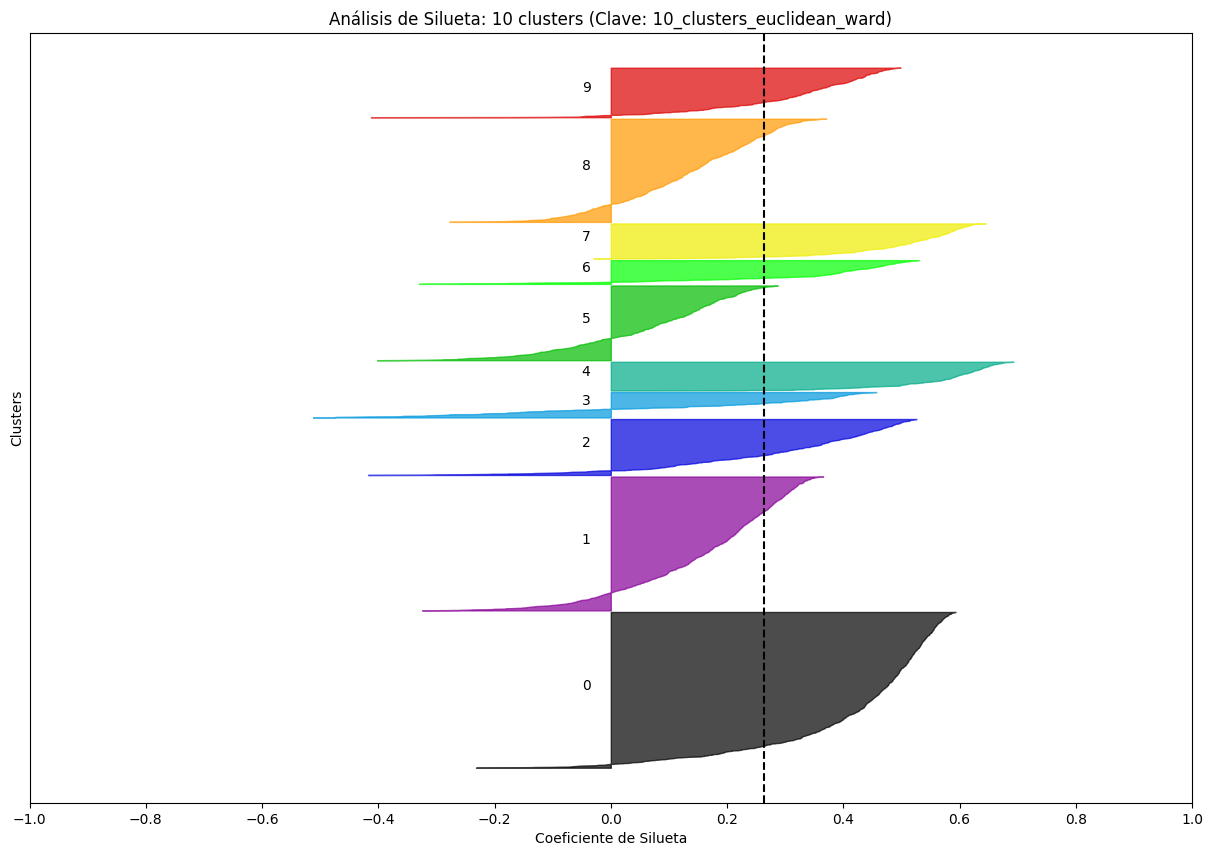

10_clusters_euclidean_ward -> Score Promedio: 0.2639


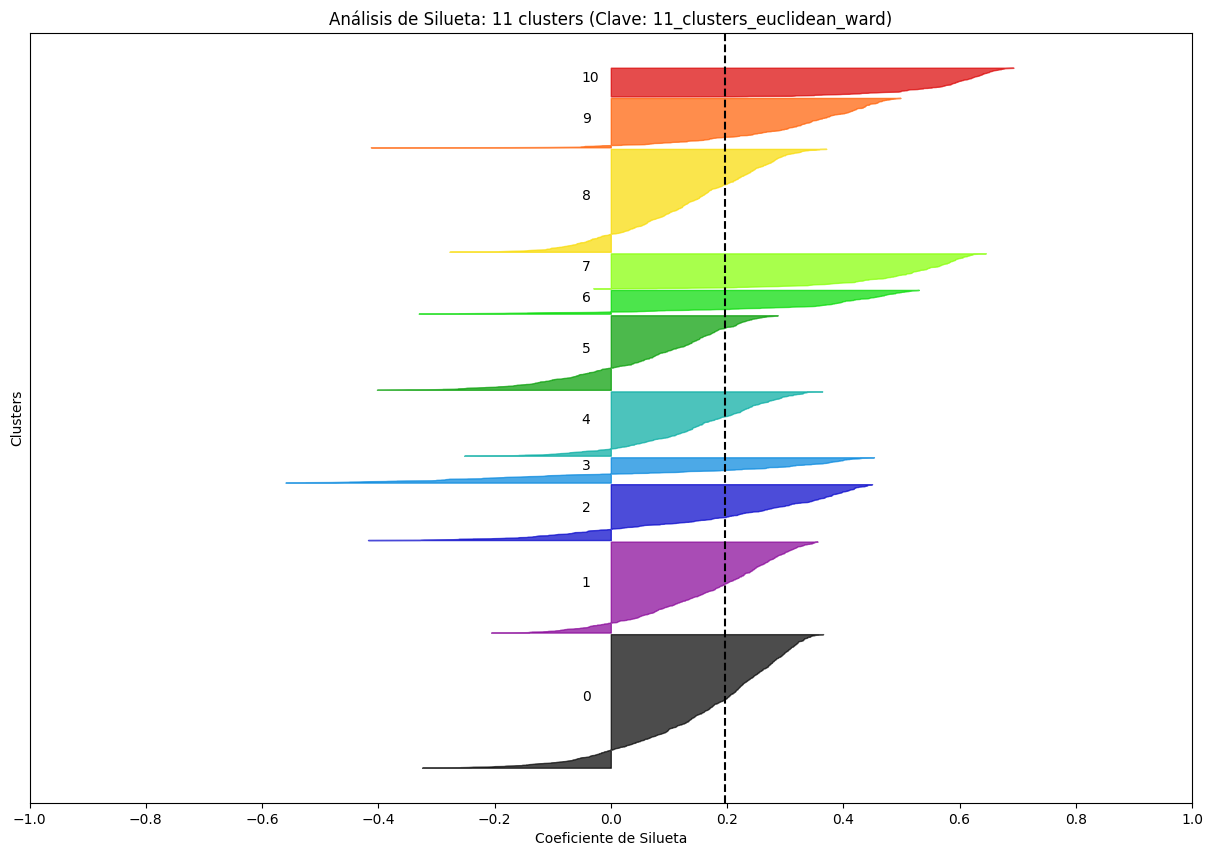

11_clusters_euclidean_ward -> Score Promedio: 0.1958


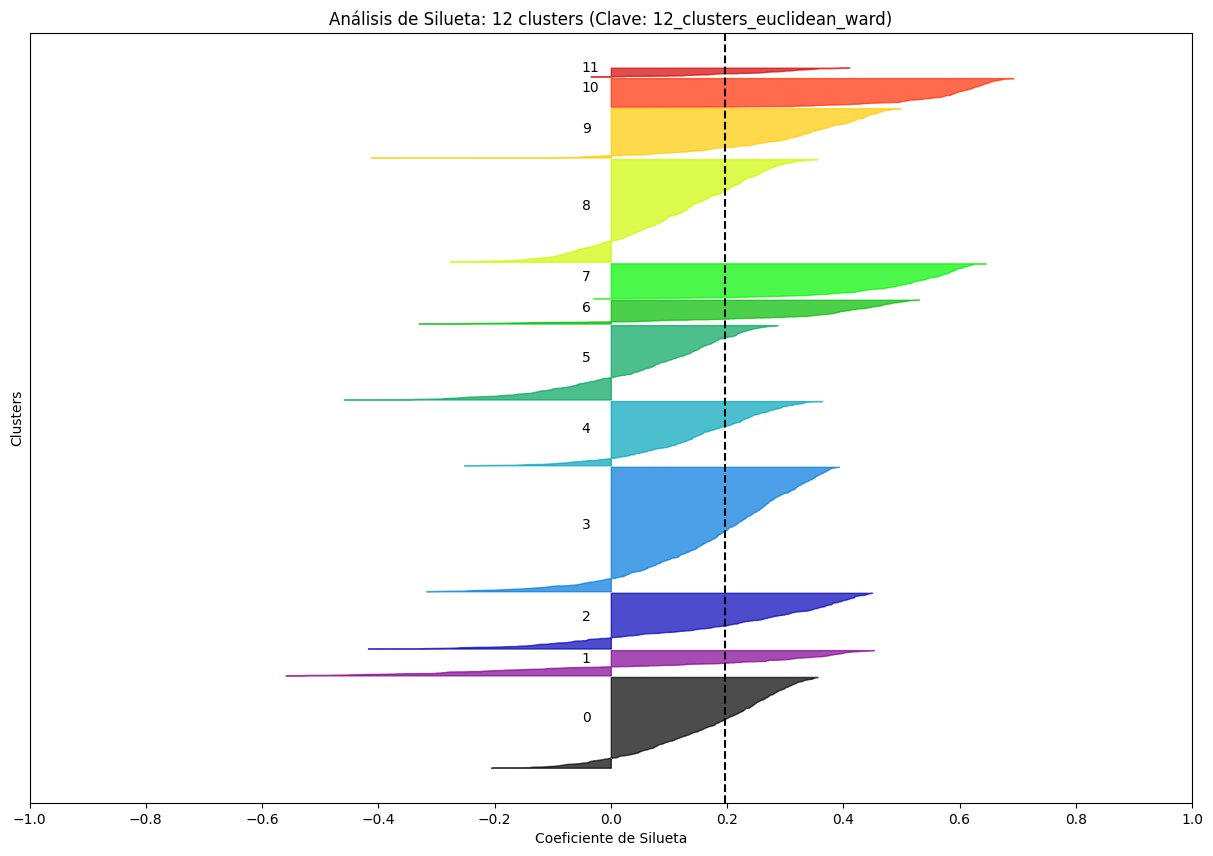

12_clusters_euclidean_ward -> Score Promedio: 0.1967


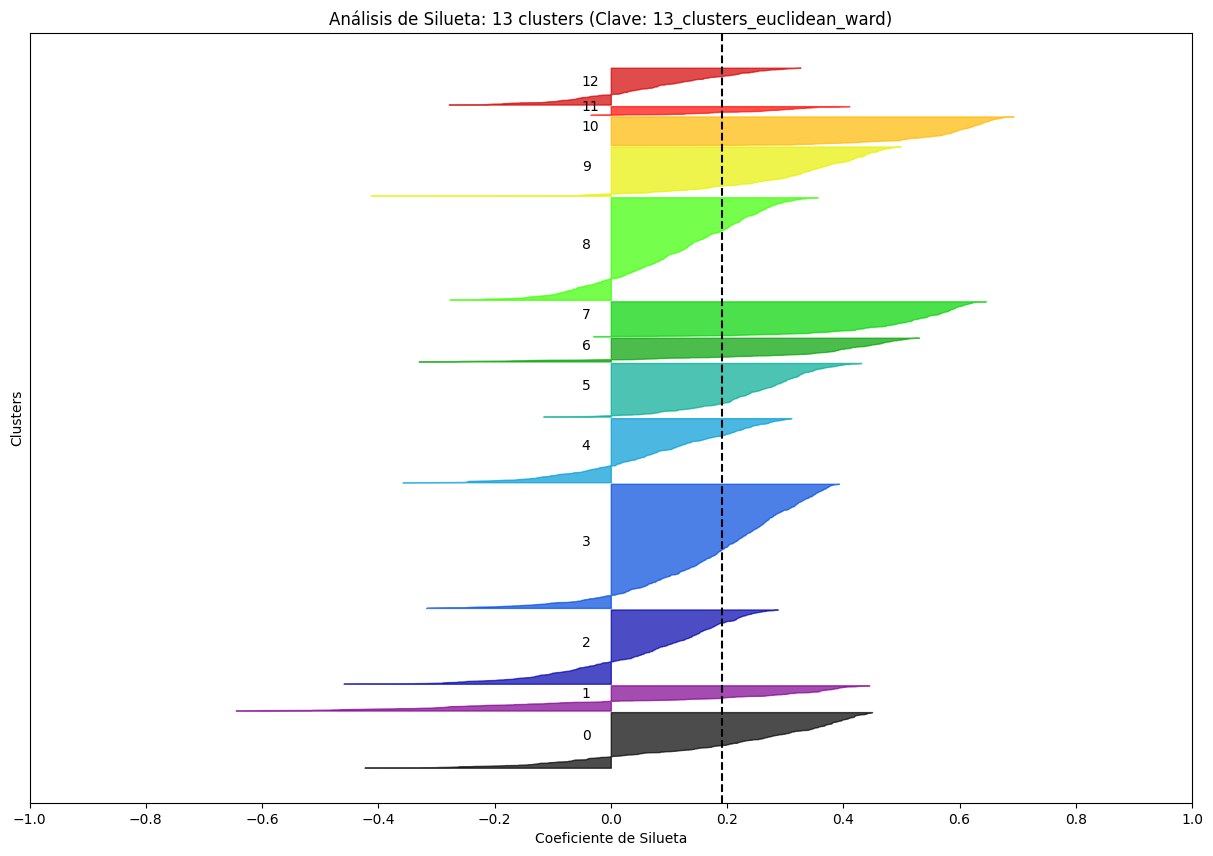

13_clusters_euclidean_ward -> Score Promedio: 0.1909


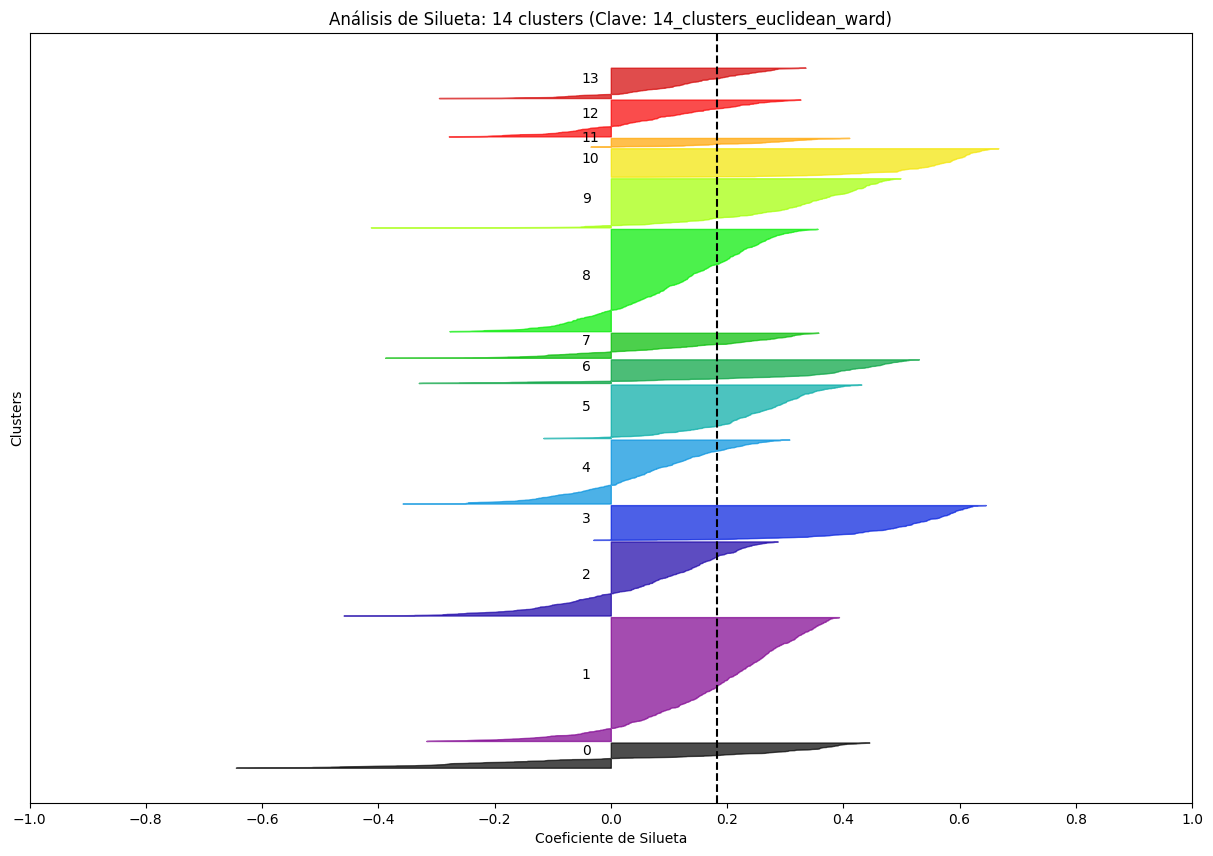

14_clusters_euclidean_ward -> Score Promedio: 0.1820


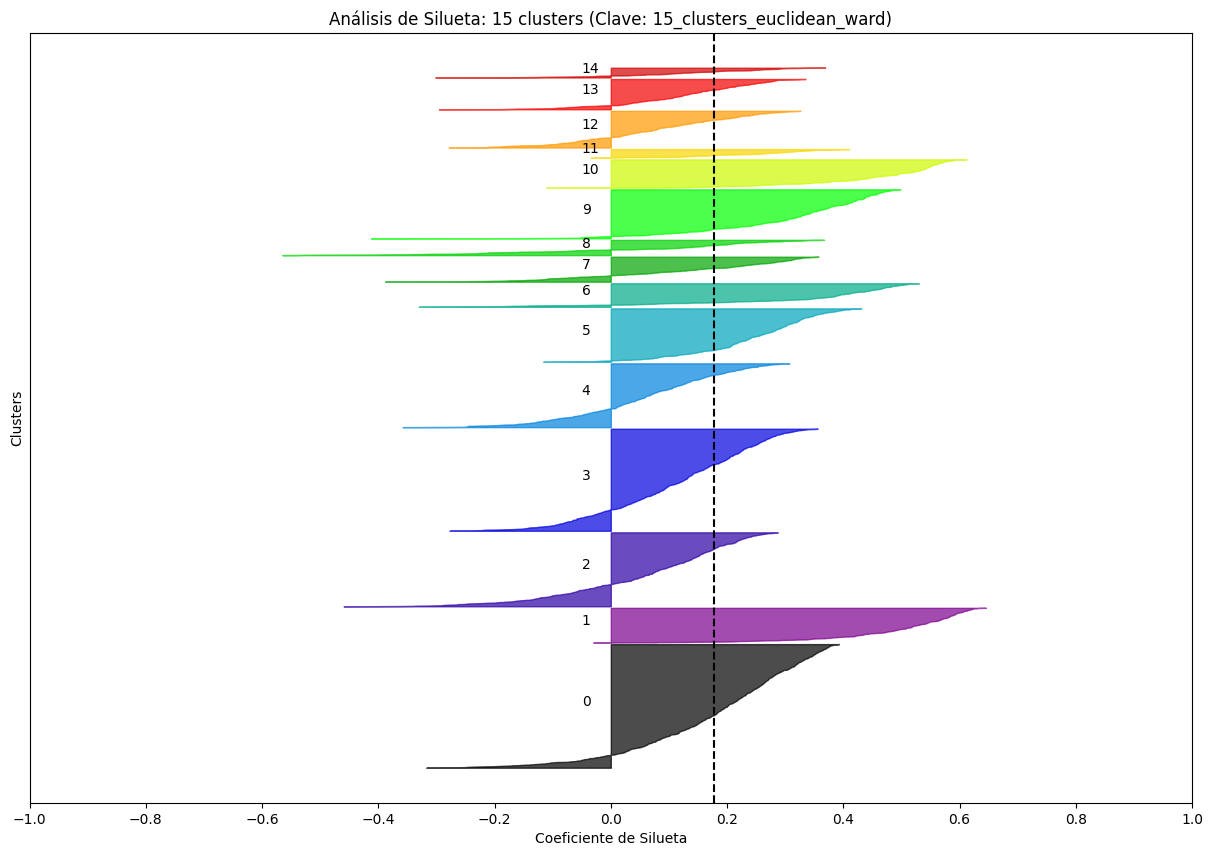

15_clusters_euclidean_ward -> Score Promedio: 0.1782


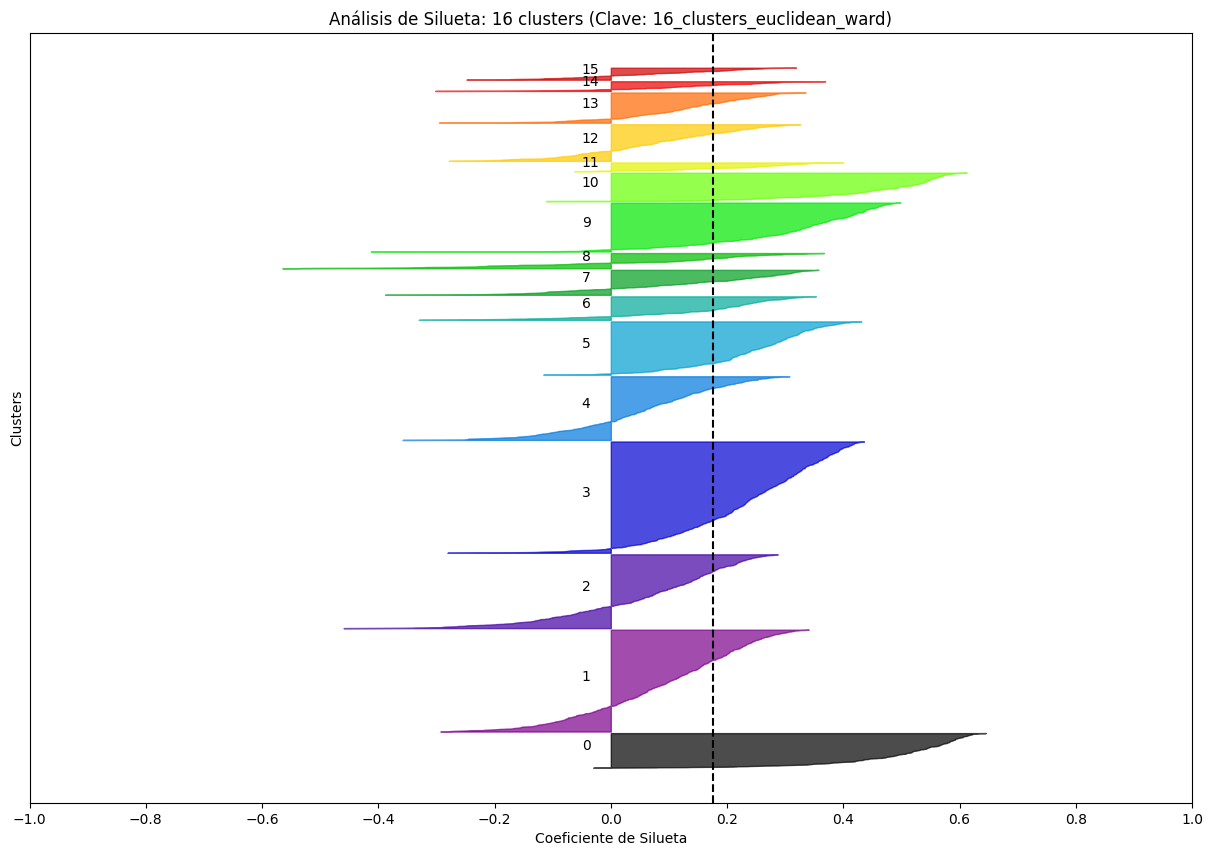

16_clusters_euclidean_ward -> Score Promedio: 0.1754


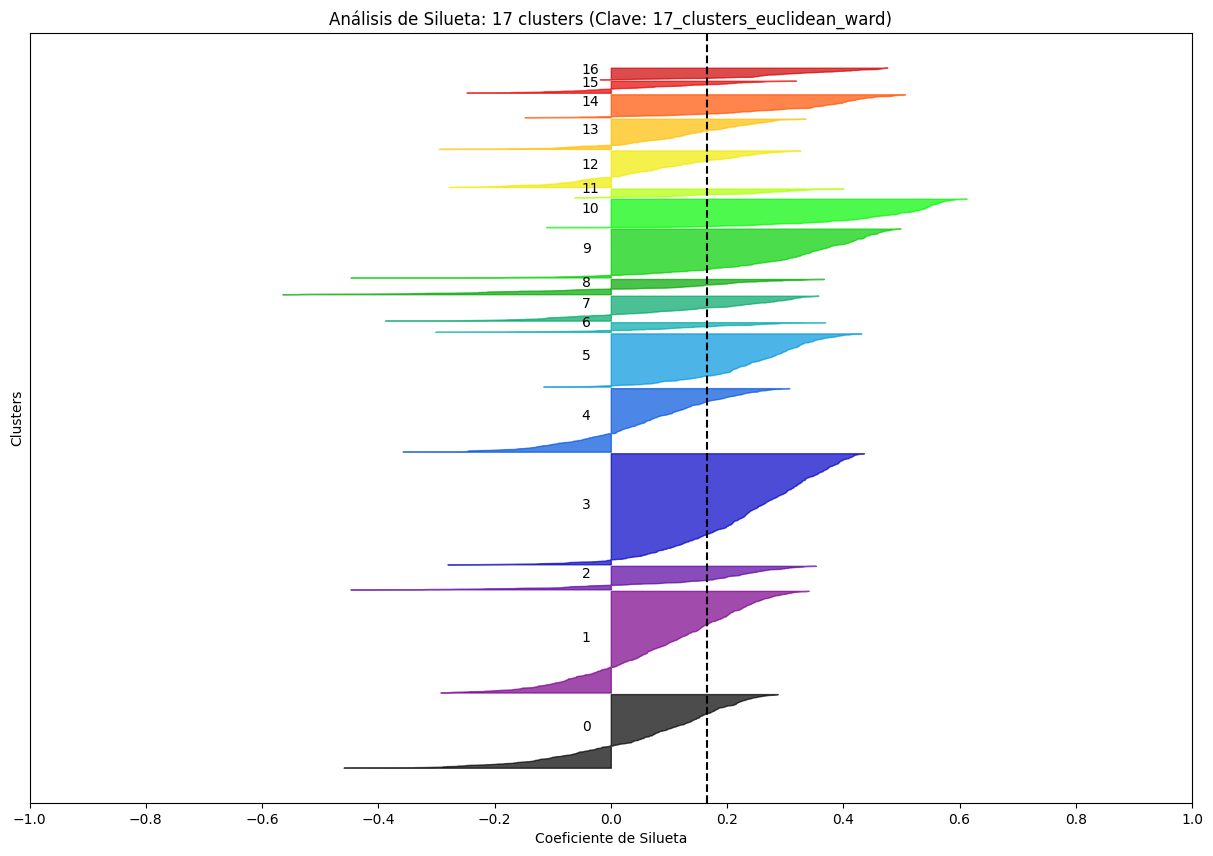

17_clusters_euclidean_ward -> Score Promedio: 0.1653


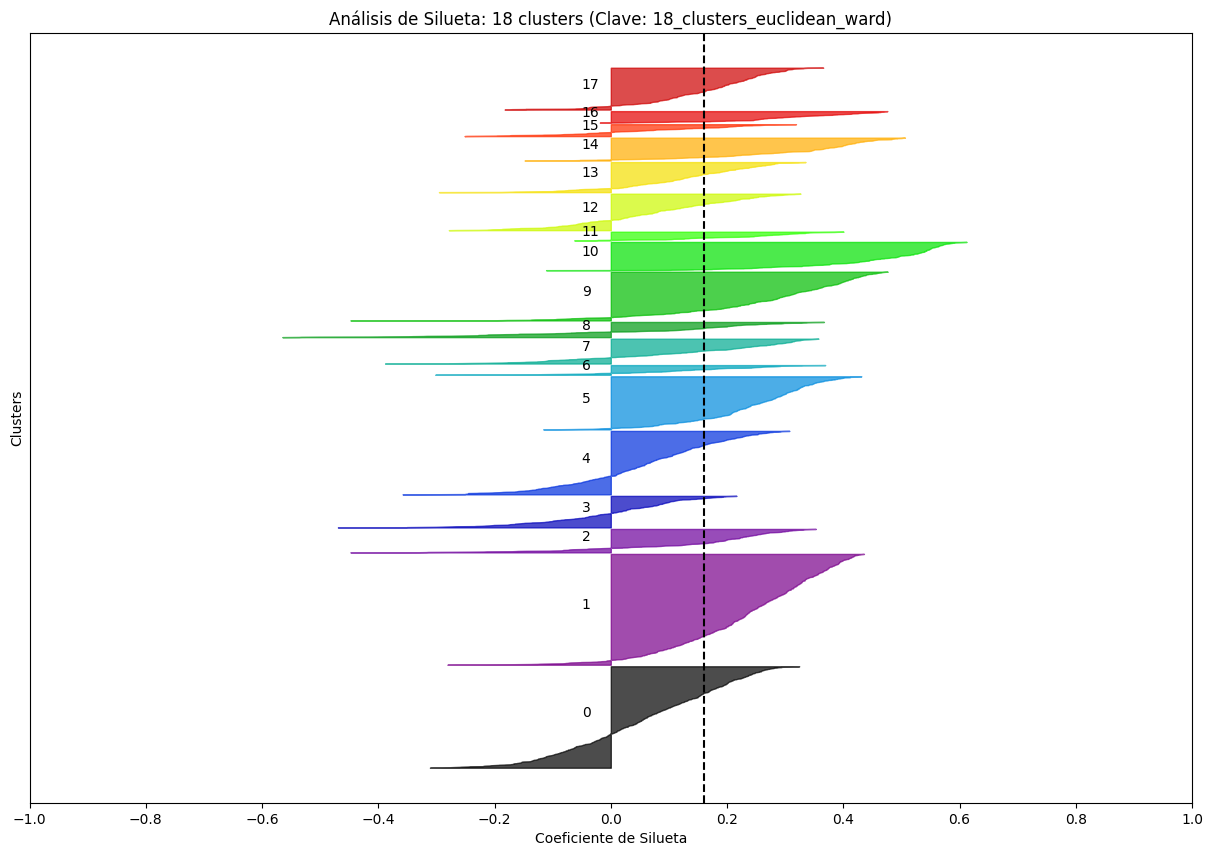

18_clusters_euclidean_ward -> Score Promedio: 0.1612


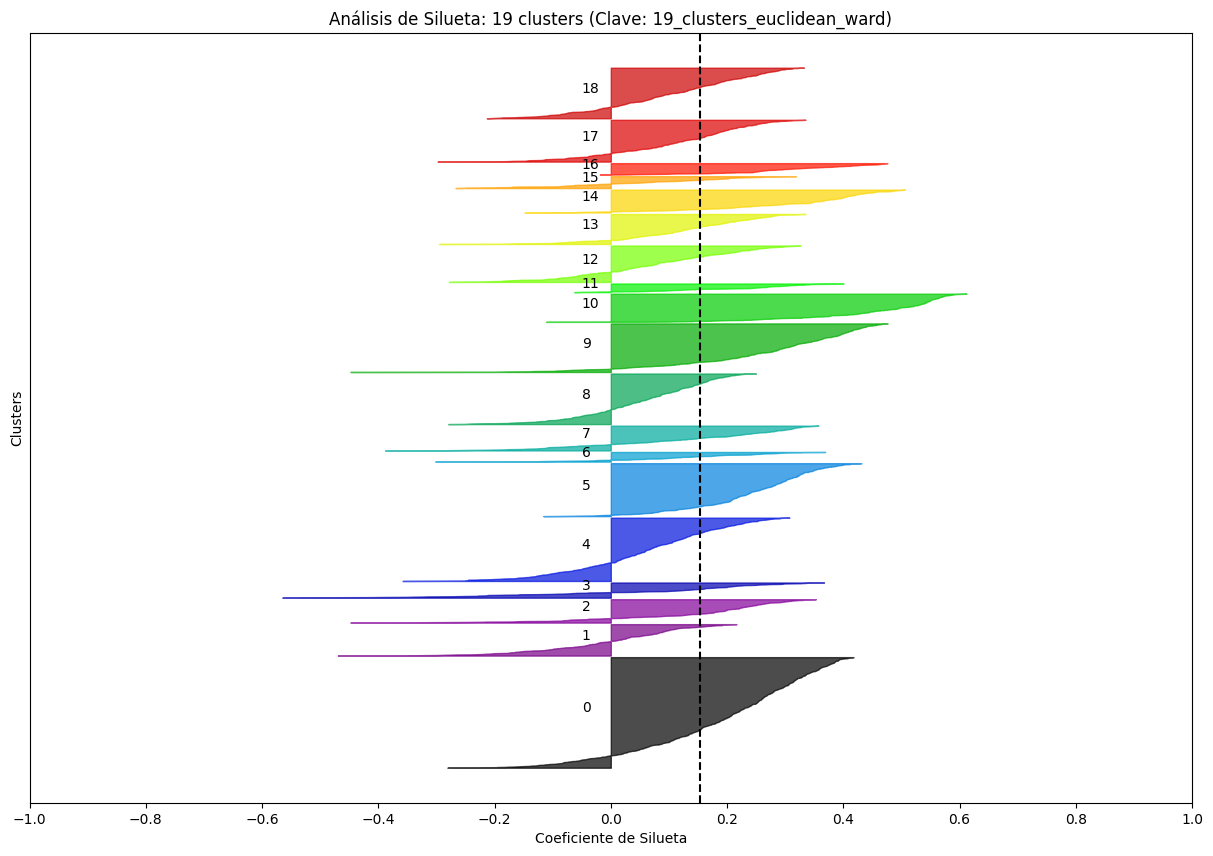

19_clusters_euclidean_ward -> Score Promedio: 0.1536


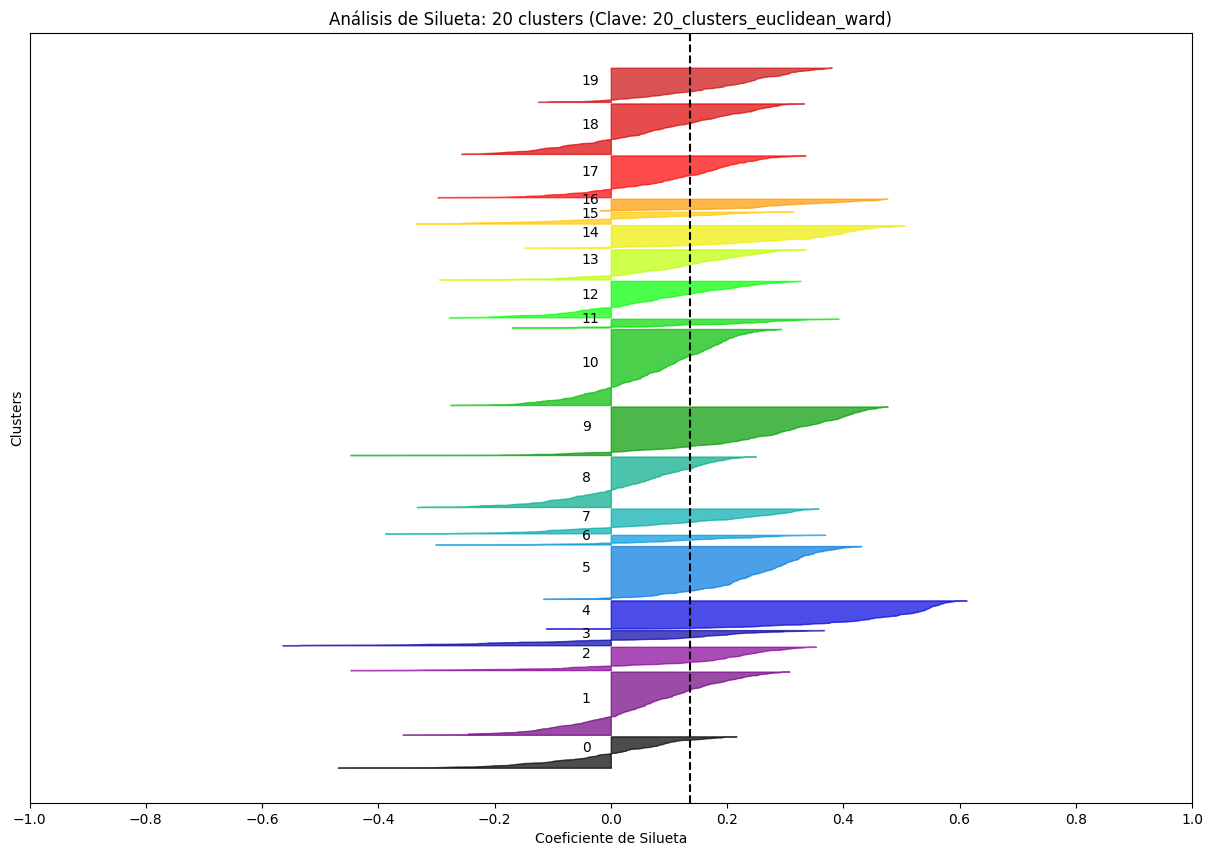

20_clusters_euclidean_ward -> Score Promedio: 0.1367


In [128]:
# Mostramos el diagrama de sierra
dibujar_diagrama_sierra(dataset_spotify_preprocesado, resultados_euclidea_ward)

Con esto, podemos concluir lo siguiente:
- Como con calinski: Mientras `más clústers, peor es el índice.`
- A diferencia de calinski, `8 clústers es lo más ideal.` Al bajar de 10, el emporamiento del score **es notório (ninguno pasa del 0.20).**
- Aunque 8 da el mejor score, `silueta dice que estamos en el rango de 0.26-0.50`, con **estructuras, pero débiles.**

Como vemos, pues silueta es directo y no ve estructuras claras, mientras que calinski no era tan negativo y decia que si habían buenos clústers (tanto con 6 como con 7-9). Antes de concluir, vamos a ver que tal le va a manhattan:

##### **Evaluando la manhattan-complete**

In [129]:
# Vemos los resultados de silueta
resultados_silueta_manhattan = evaluar_indices_calidad(dataset_spotify_preprocesado, resultados_manhattan_complete, show_calinski=False)
resultados_silueta_manhattan

,silueta
6,0.332477
7,0.332787
8,0.339582
9,0.345492
10,0.343373
11,0.271743
12,0.270695
13,0.195300
14,0.182912
15,0.184656


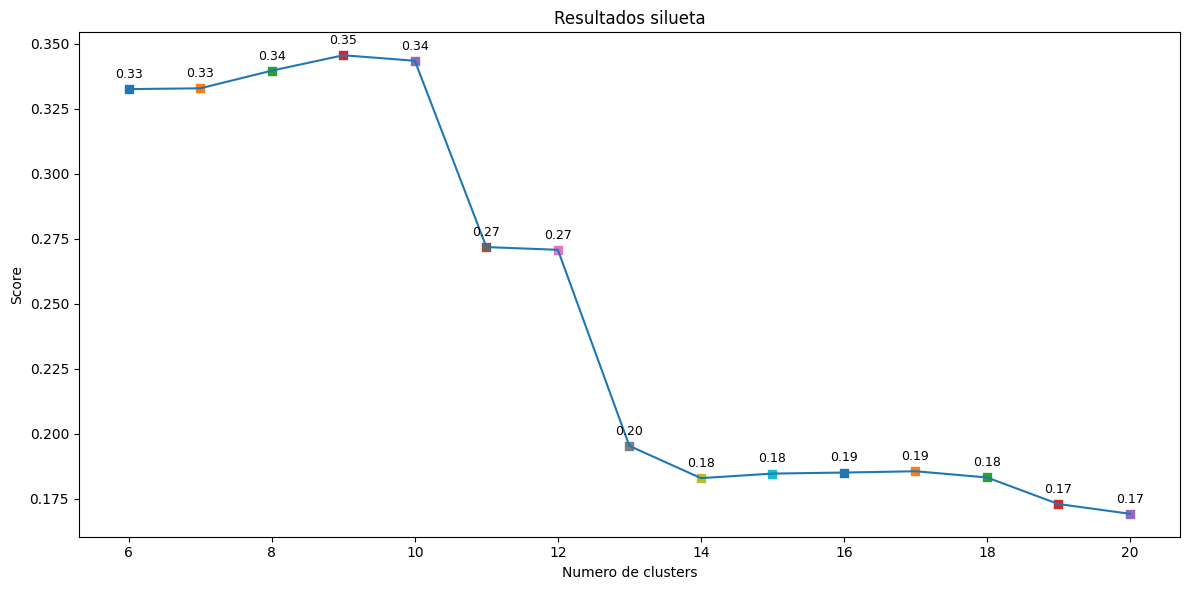

In [130]:
# Mostramos resultados graficamente
dibujar_resultados_metricas(dataset_spotify_preprocesado, resultados_manhattan_complete, show_calinski=False)

Y el diagrama de sierra:

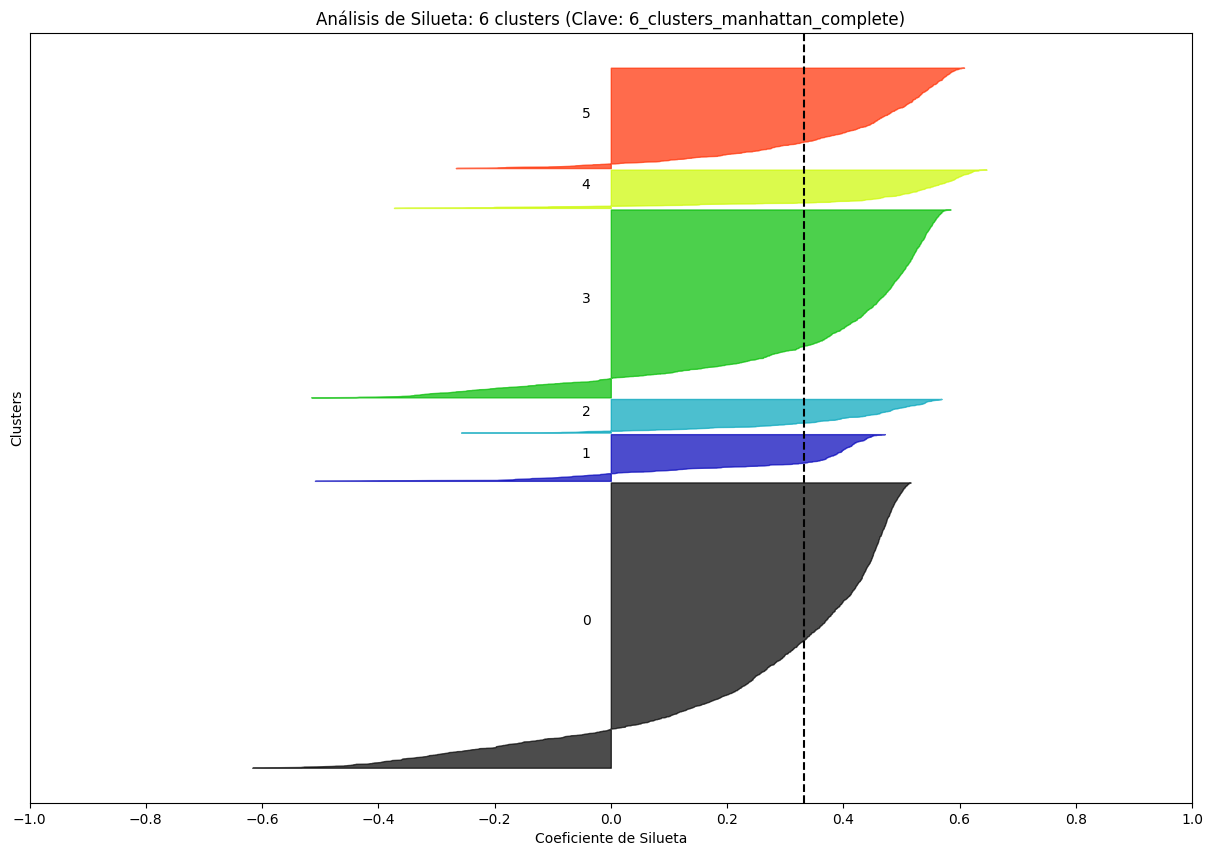

6_clusters_manhattan_complete -> Score Promedio: 0.3325


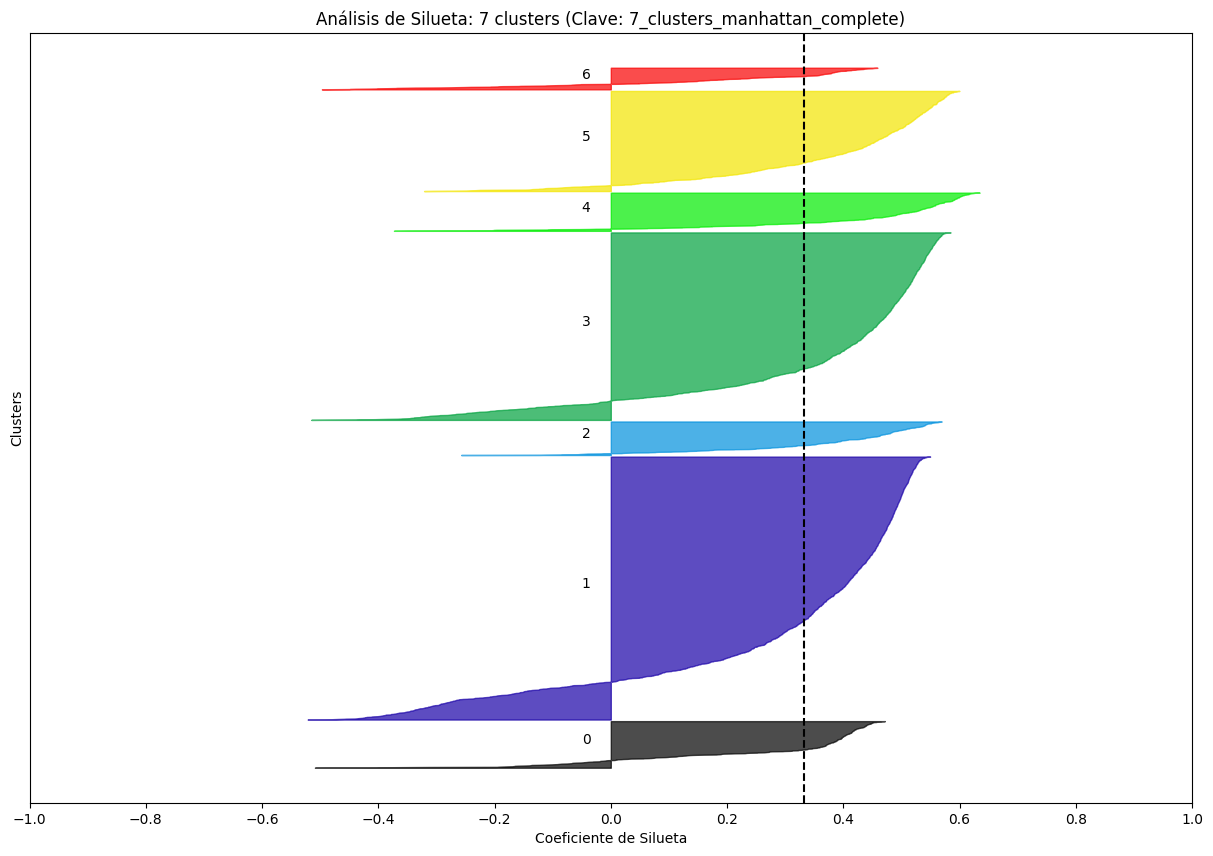

7_clusters_manhattan_complete -> Score Promedio: 0.3328


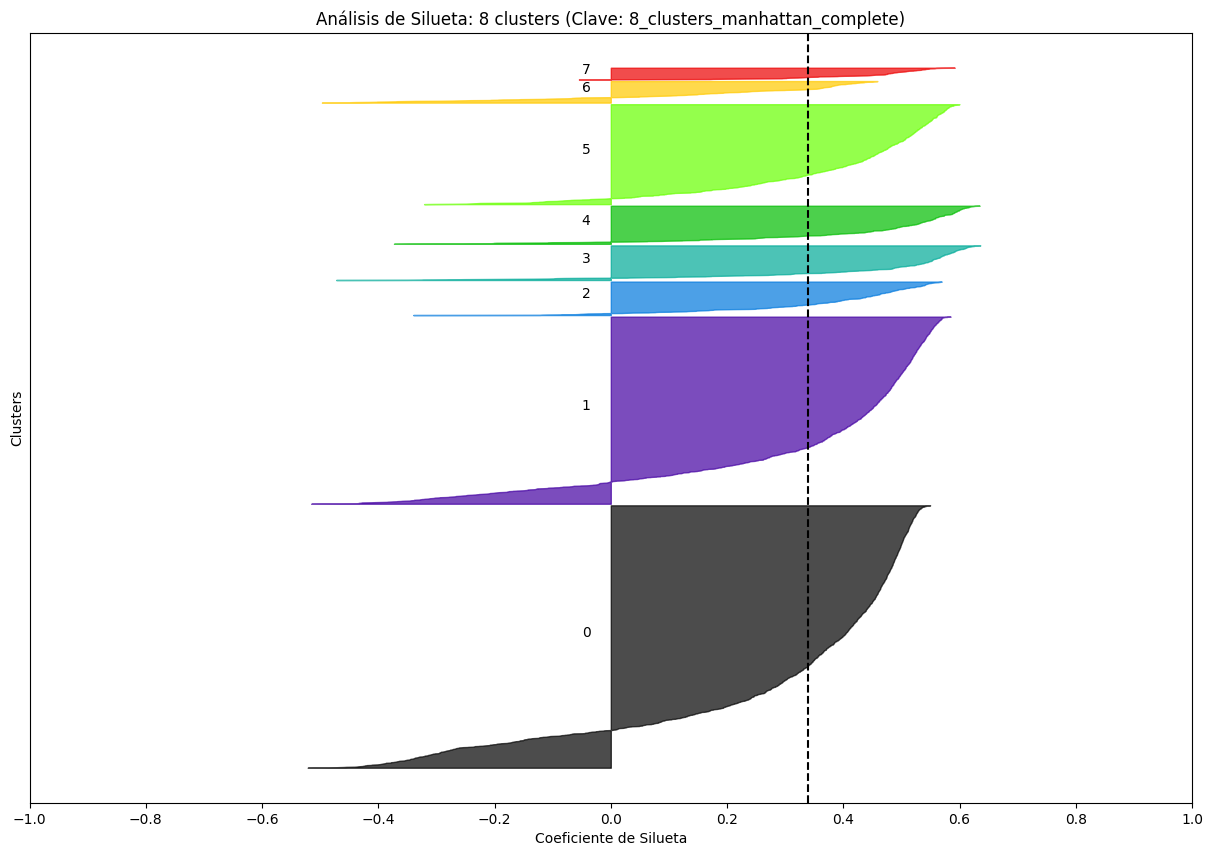

8_clusters_manhattan_complete -> Score Promedio: 0.3396


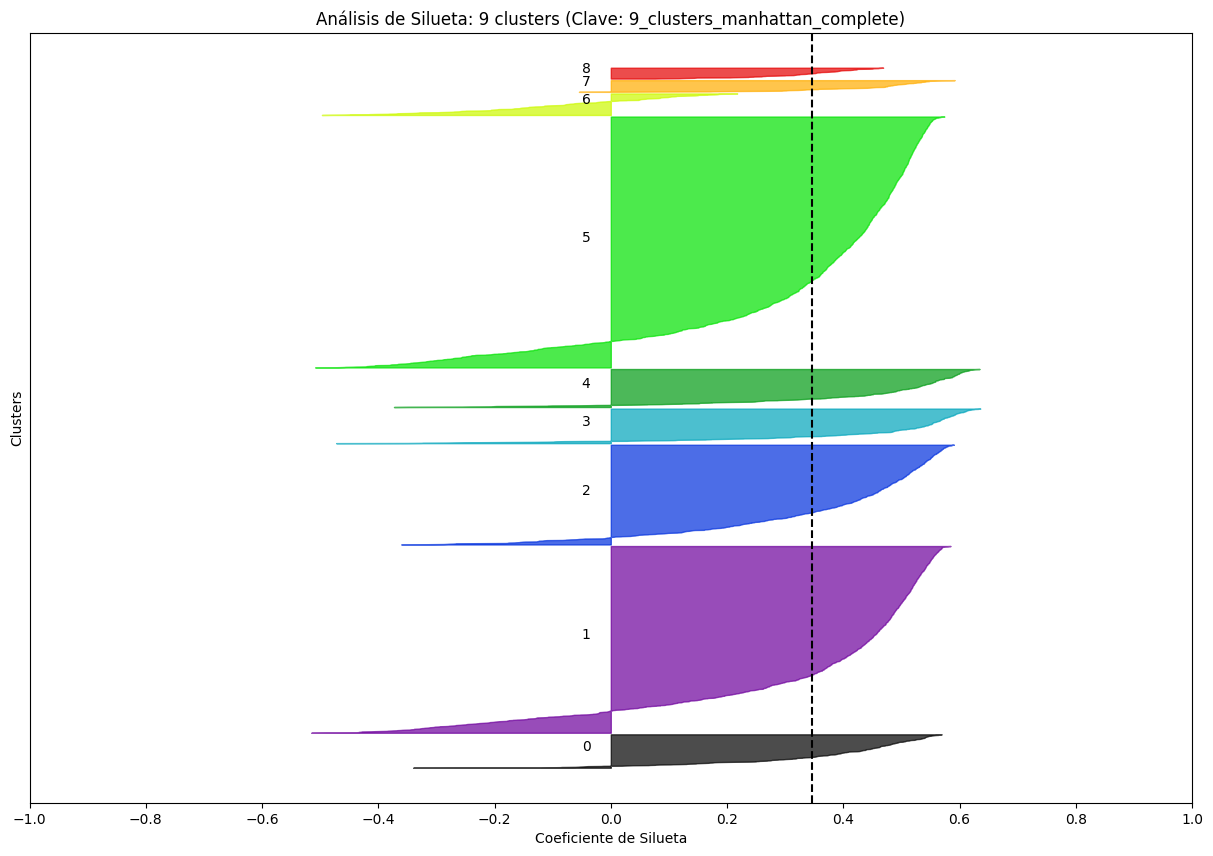

9_clusters_manhattan_complete -> Score Promedio: 0.3455


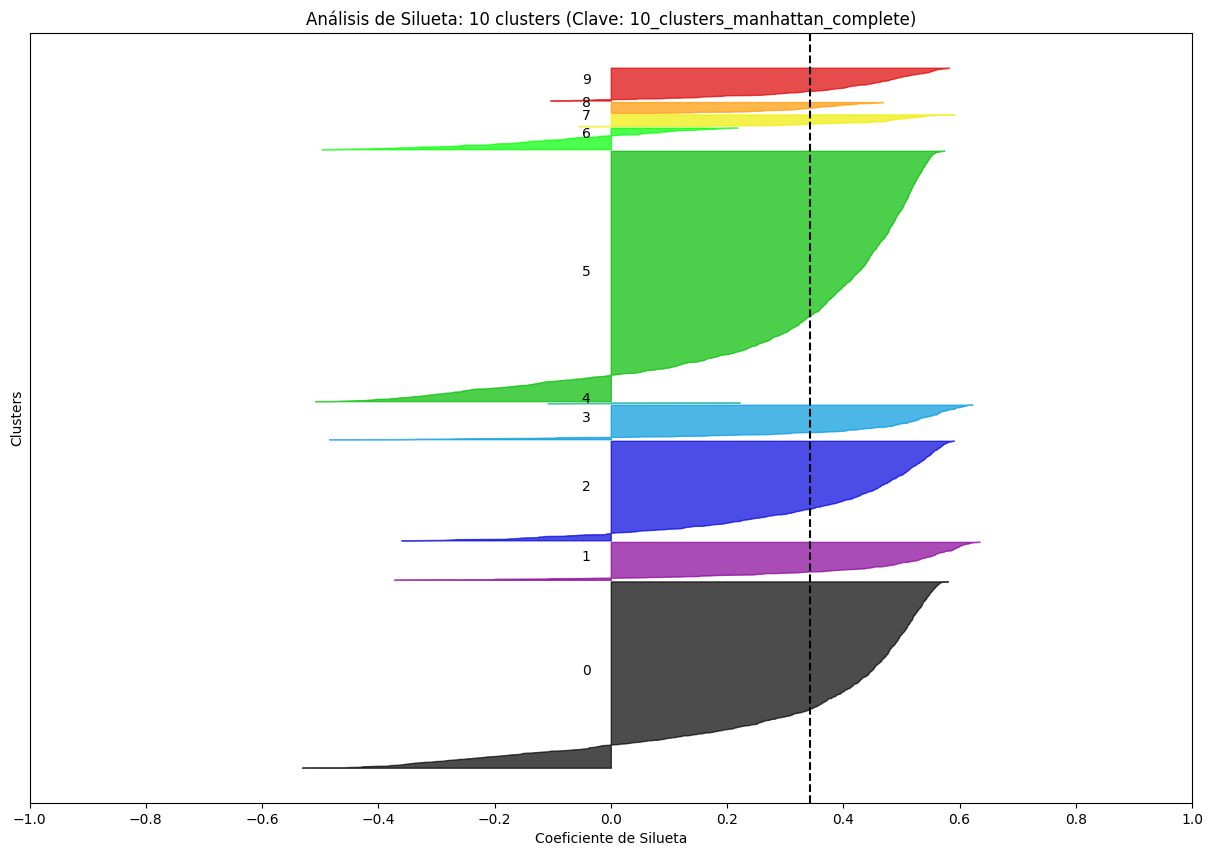

10_clusters_manhattan_complete -> Score Promedio: 0.3434


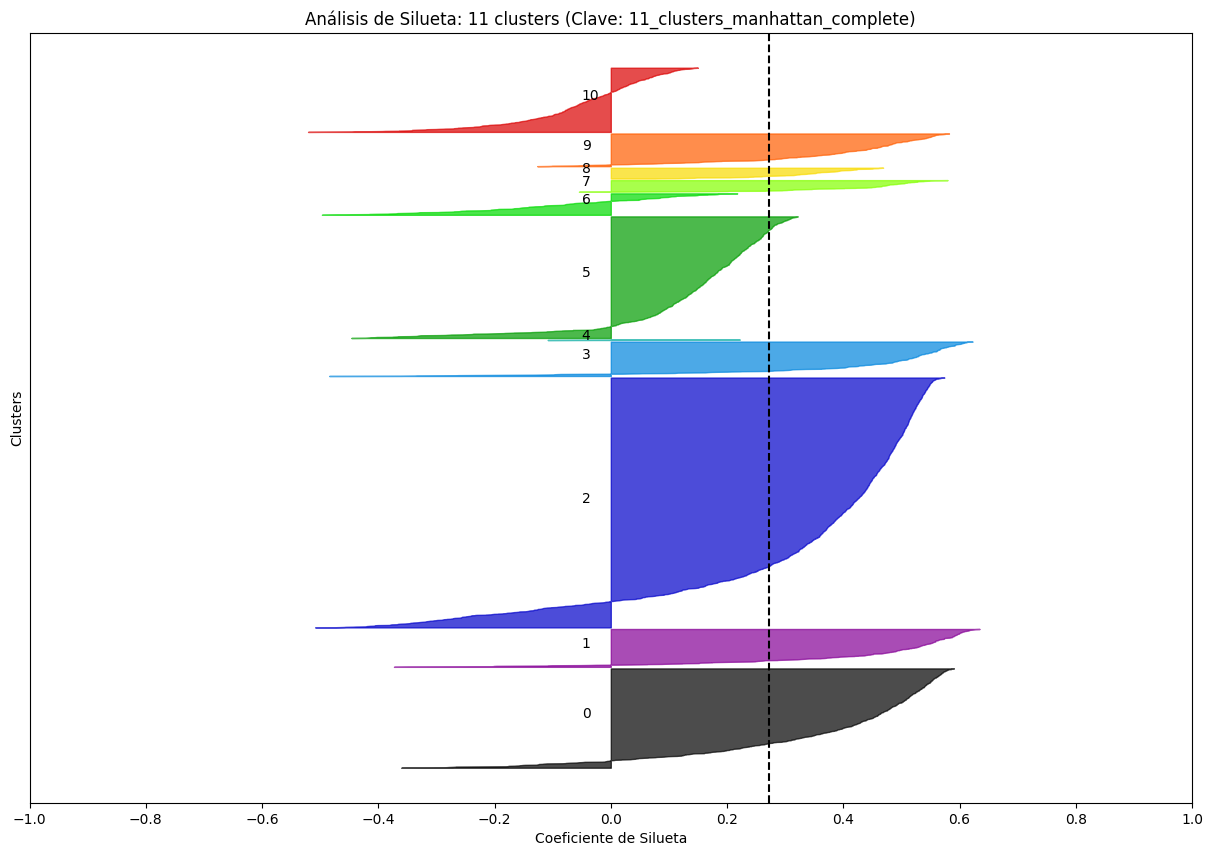

11_clusters_manhattan_complete -> Score Promedio: 0.2717


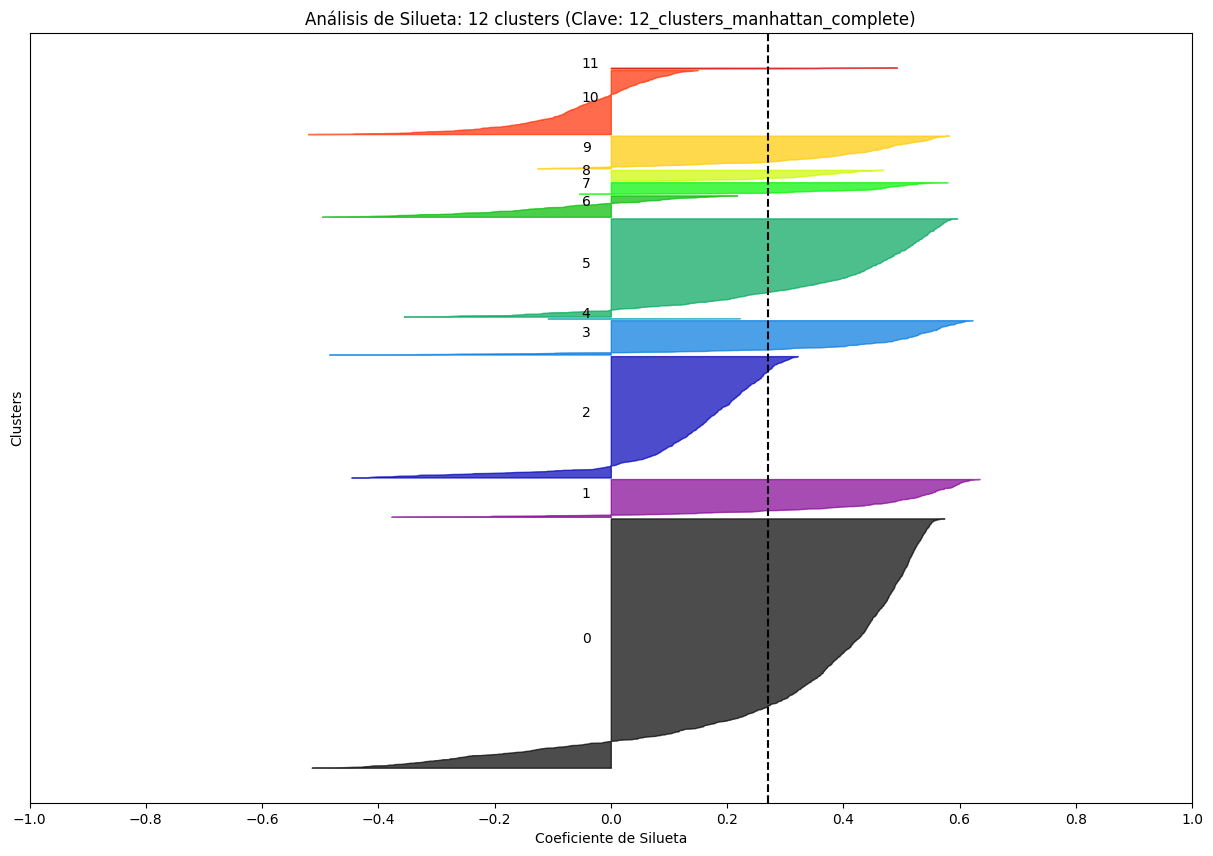

12_clusters_manhattan_complete -> Score Promedio: 0.2707


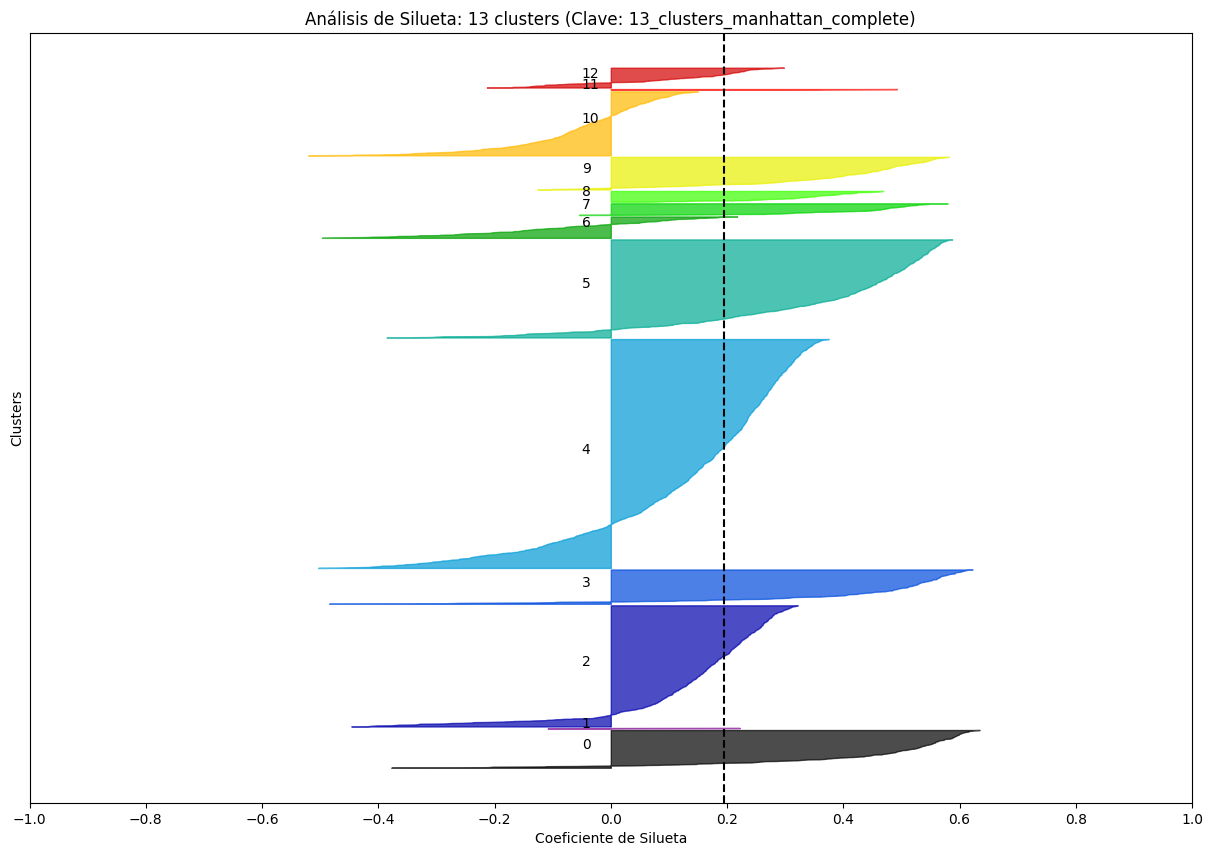

13_clusters_manhattan_complete -> Score Promedio: 0.1953


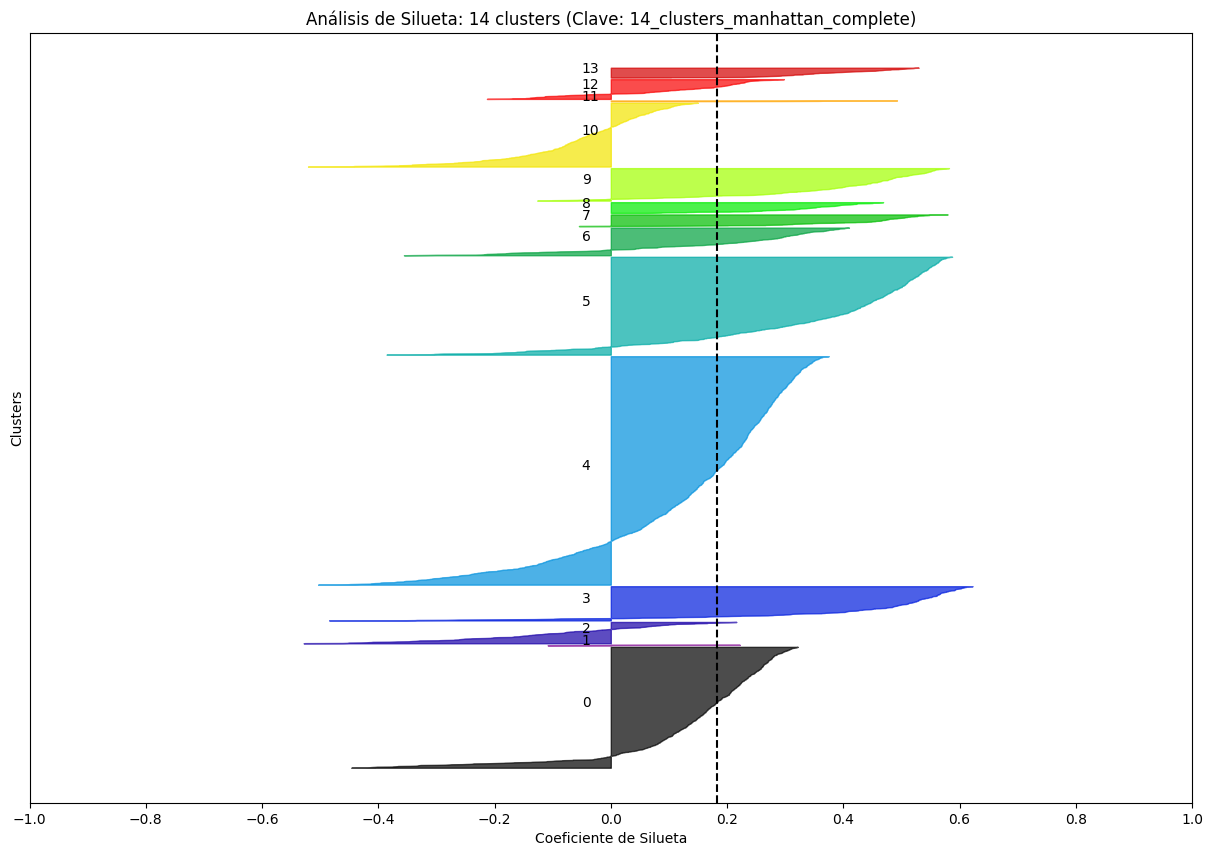

14_clusters_manhattan_complete -> Score Promedio: 0.1829


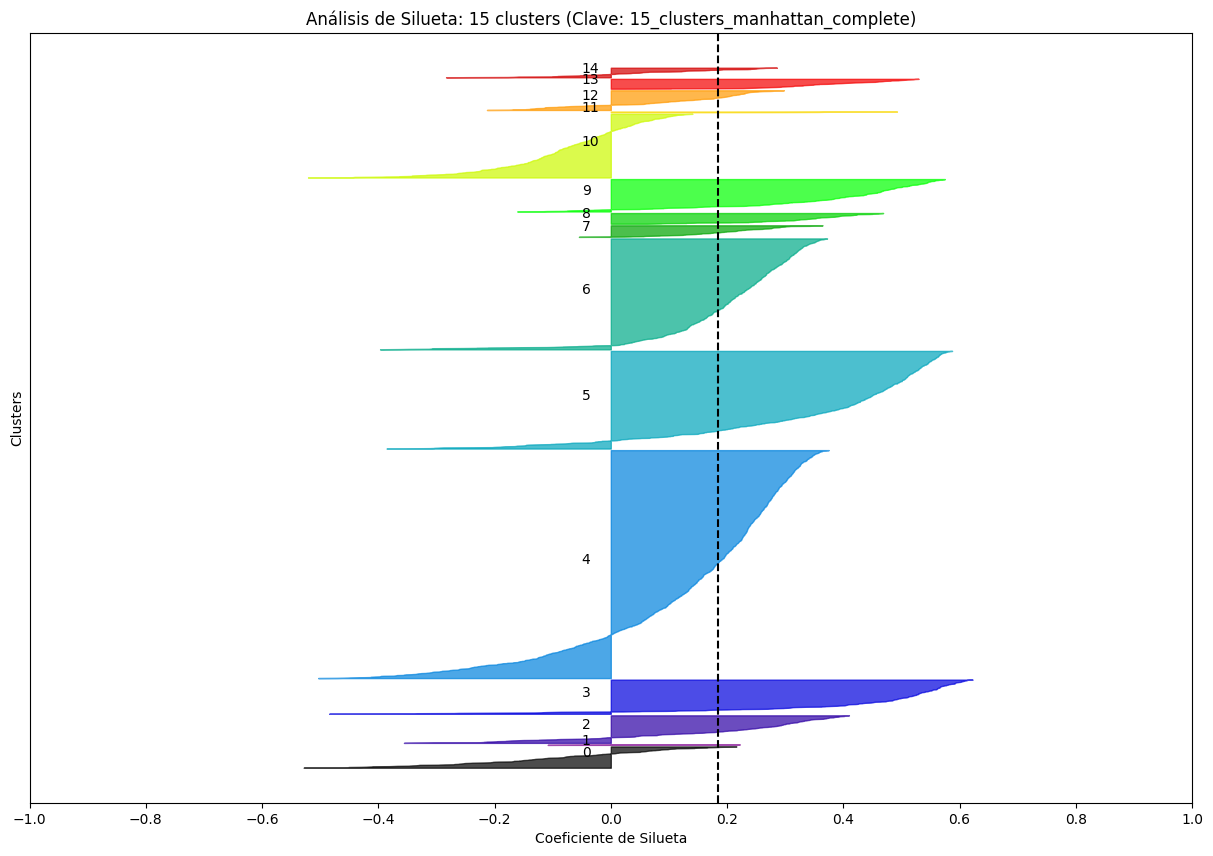

15_clusters_manhattan_complete -> Score Promedio: 0.1847


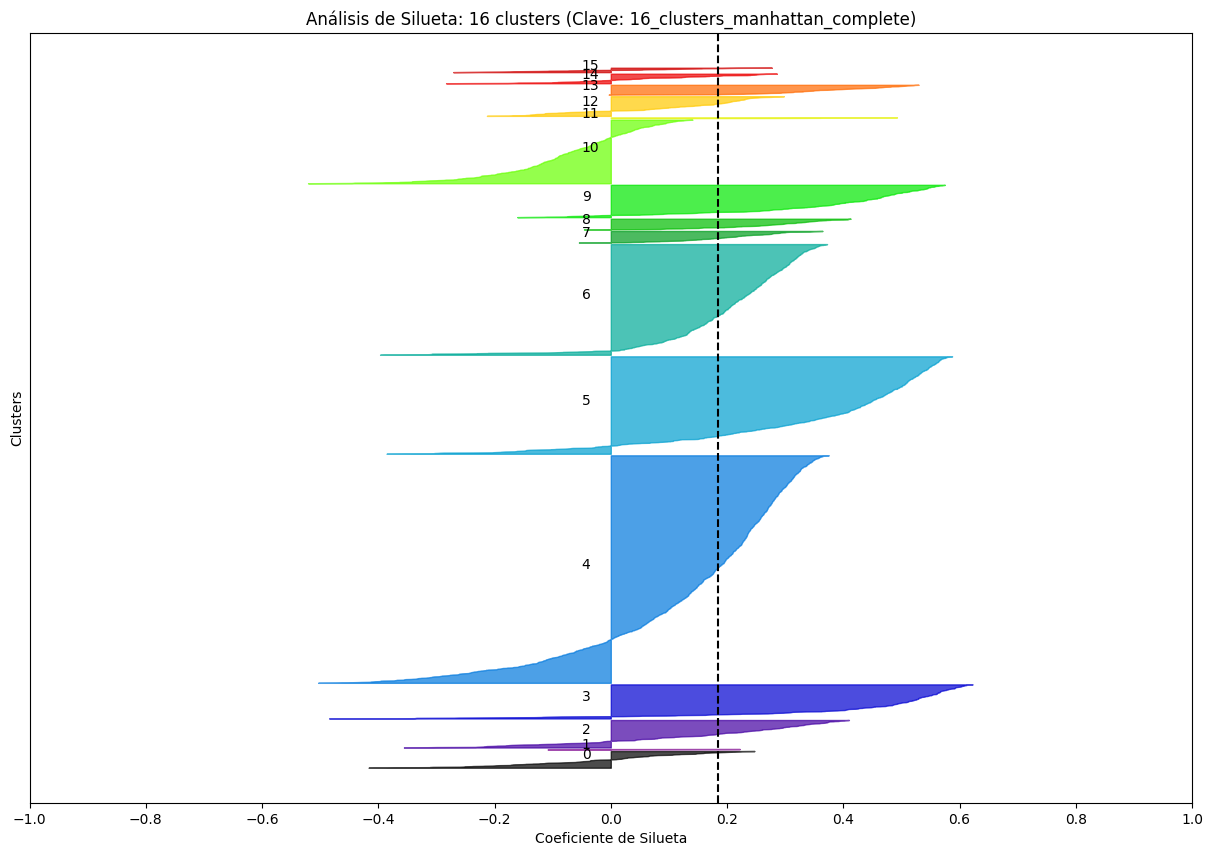

16_clusters_manhattan_complete -> Score Promedio: 0.1851


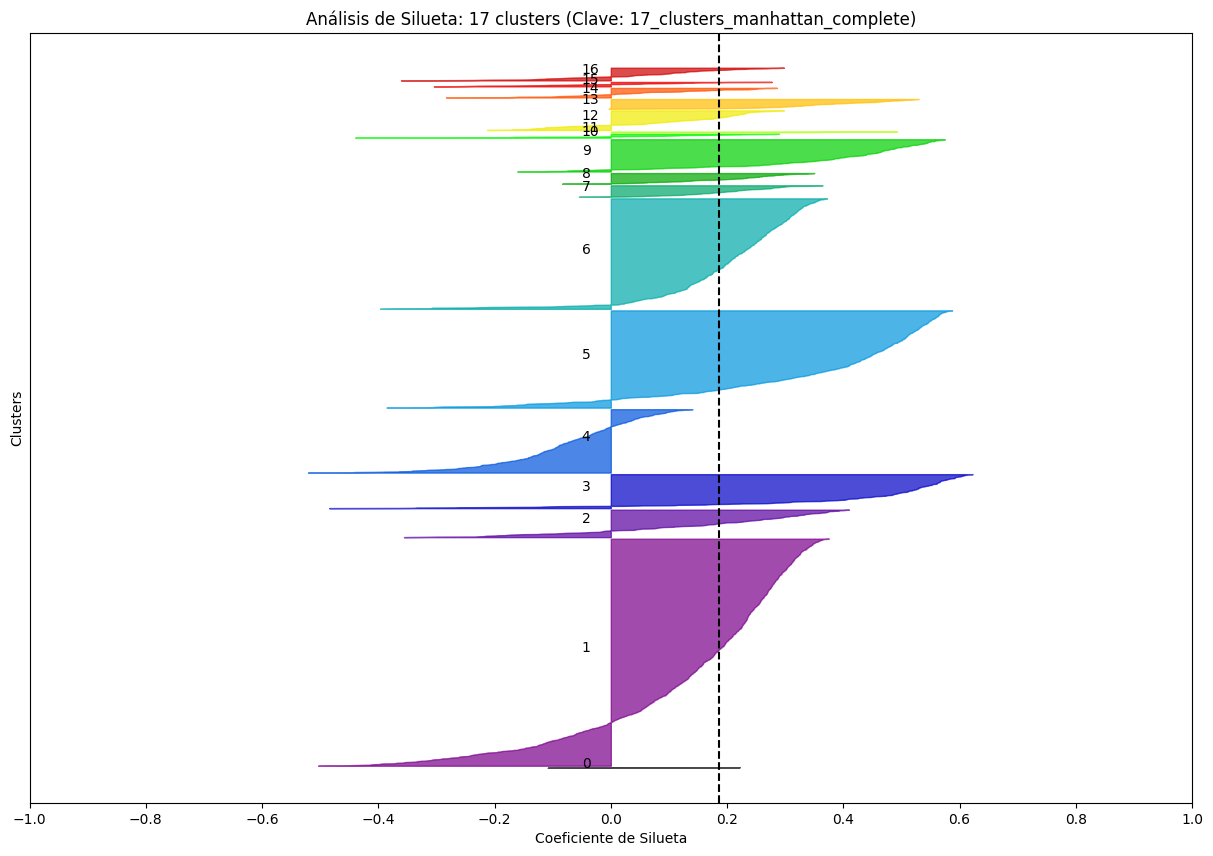

17_clusters_manhattan_complete -> Score Promedio: 0.1856


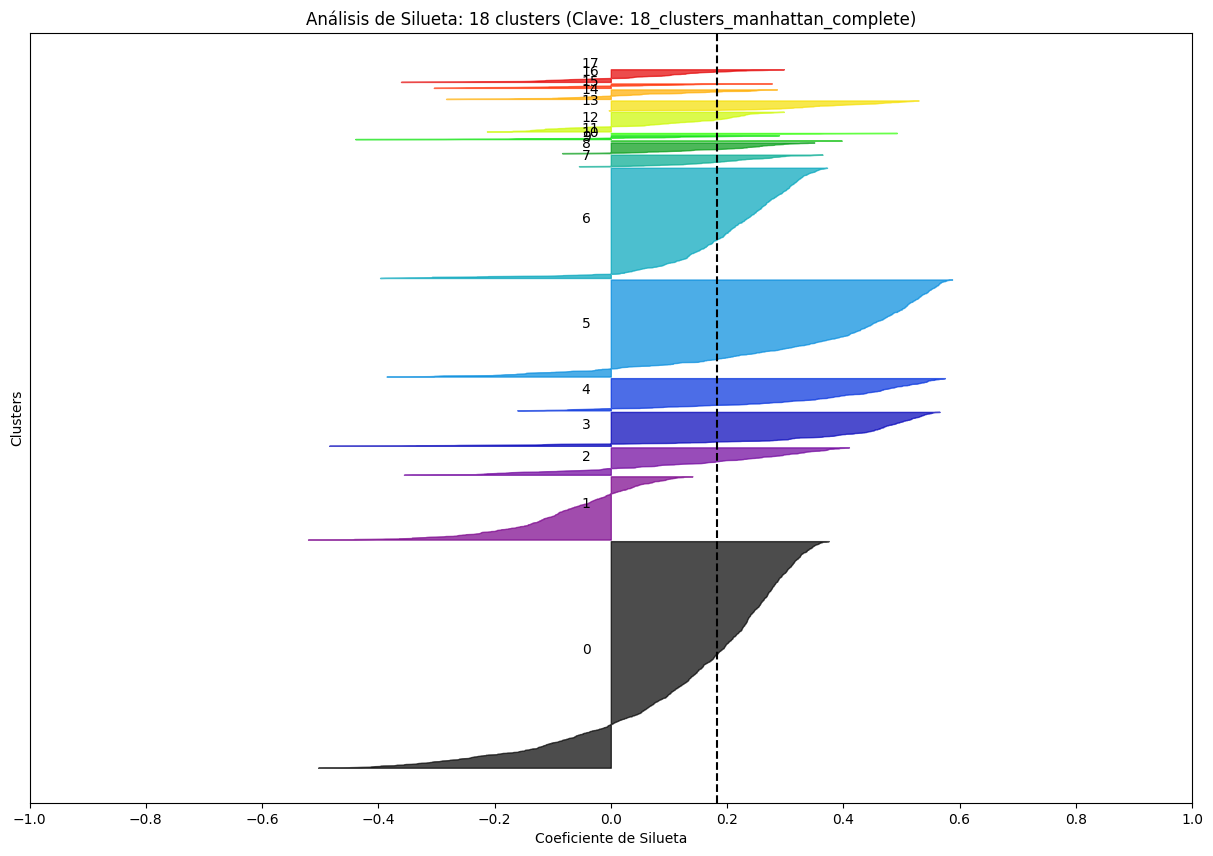

18_clusters_manhattan_complete -> Score Promedio: 0.1832


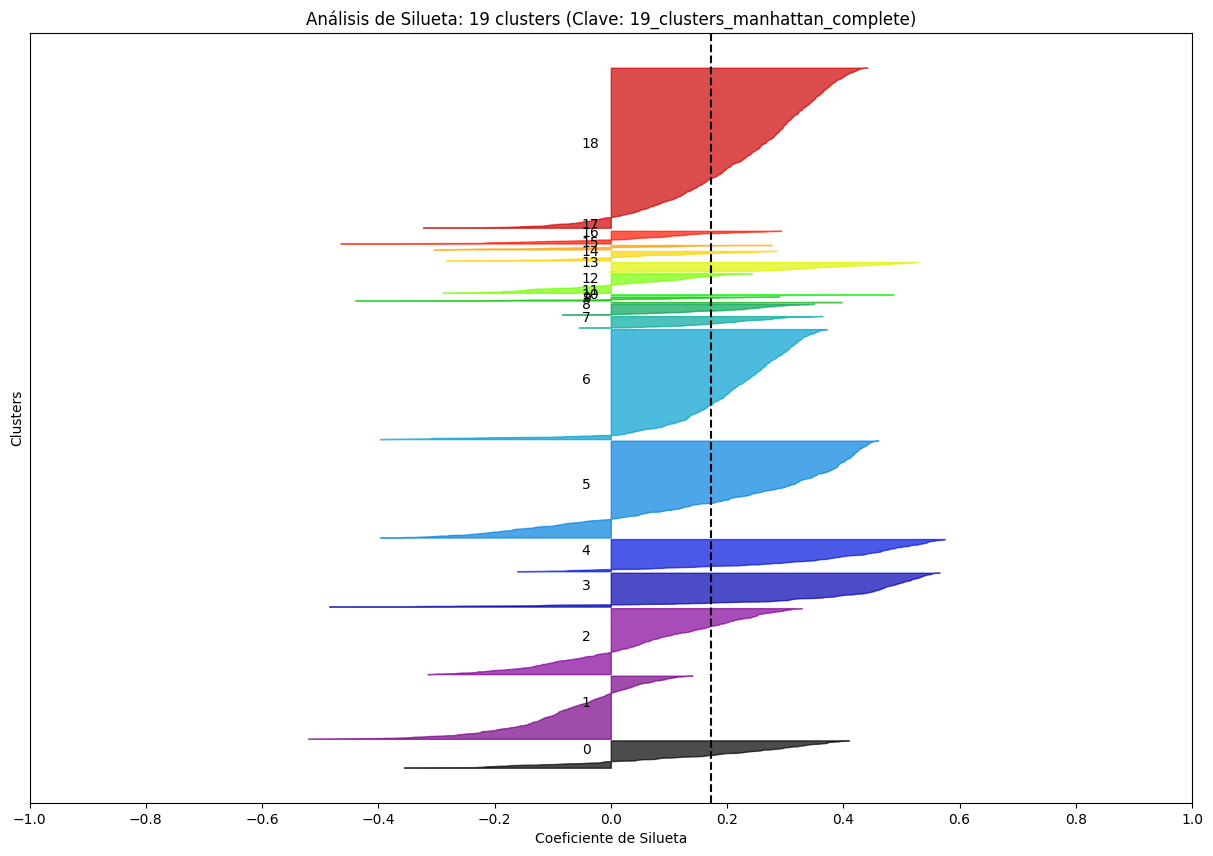

19_clusters_manhattan_complete -> Score Promedio: 0.1730


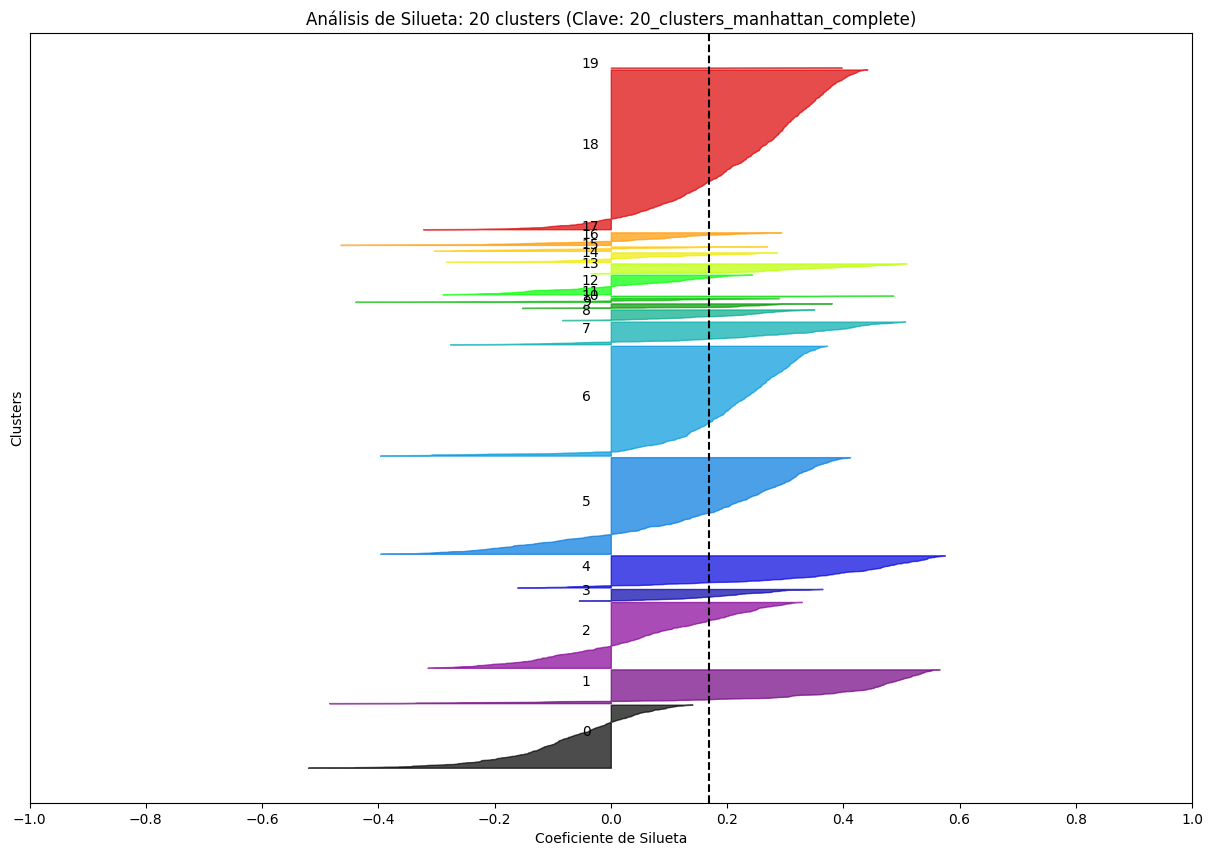

20_clusters_manhattan_complete -> Score Promedio: 0.1692


In [131]:
# Mostramos el diagrama de sierra
dibujar_diagrama_sierra(dataset_spotify_preprocesado, resultados_manhattan_complete)

Aquí el análisis es más curioso:
- Aquí, `9-10 clústers suele ser lo mejor.`
- A diferencia de ward, **mientras más clústers (de 13 para arriba), peor es el score.**
- Igual que antes, `podríamos quedarnos con 8, 9 o incluso 10.` Más es encontrar clústers mal agrupados

Igual que antes, silueta dice que, aunque no hay estructura, 9-10 clústers pueden encontrar algo, pero débil.

****OJO: EStas métricas funcionan mejor con datos que forman clústers elipsoidales****

### **Tarea 1.5**
Nos piden: **`¿Cuál es el número óptimo de clusters? ¿por qué?`**

**Conclusión**

Para este dataset, donde teníamos muchos datos `que eran extremos (outliers) pero reales,` y con **columnas que no ayudaban a la clusterización,** Los resultados obtenidos no son tan malos del todo. Vimos en 1.1 que `euclidean ward` lo hacia bien con los 3 ejemplos, aunque con estas métricas vemos que, al menos, con silueta, dice lo contrario. Con manhattan, sorprendentemente es quien mejor **scores ha tenido, incluso teniendo los `clústers genéricos.`** Finalmente, lo mejor que hemos tenido en general son 8-10 clústers, ya que calinski les da buen score (poca dispersos los clústers y muy dispersos entre clústers) y silueta les encuentra algo de estructura. Por lo cual, creemos que 8 clústers con `average ward` y 10 con `manhattan complete` son los mejores.

Para terminar, vamos a analizar cada uno a ver qué géneros nos ha agrupado. Analizaremos ambos casos a ver que nos encontramos:

#### **Para euclidean ward (8 clústers)**
Veremos la media de cada clúster:

In [132]:
# Sacamos los 8 clusters
clusters_ideales_ward = resultados_euclidea_ward['8_clusters_euclidean_ward']

# Lo pegamos al dataset preprocesado
dataset_clusterizado_ward = pd.concat([dataset_spotify_preprocesado, pd.DataFrame(clusters_ideales_ward, columns=['genero'])], axis=1)

# Hacemos groupby para la media de estos
dataset_clusterizado_ward.groupby('genero').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo
genero,,,,,,,,,
0,0.147546,0.640408,0.486446,0.679106,0.025559,0.178233,1.0,0.083663,0.518999
1,0.725455,0.550769,0.483445,0.389331,0.024997,0.164396,1.0,0.065949,0.494780
2,0.134147,0.648069,0.489888,0.700176,0.006768,0.186470,0.0,0.091633,0.515219
3,0.160810,0.589503,0.484961,0.667989,0.672056,0.206538,0.0,0.065516,0.504018
4,0.896860,0.509759,0.427264,0.161866,0.892985,0.121013,0.0,0.064369,0.465004
5,0.683820,0.572656,0.483246,0.435232,0.035390,0.177207,0.0,0.083960,0.492384
6,0.150363,0.591008,0.485362,0.684650,0.800325,0.189387,1.0,0.069895,0.541772
7,0.888258,0.468242,0.441761,0.170553,0.881004,0.139939,1.0,0.047424,0.437976


Con estos datos, podemos inferir los géneros:

| Clúster | Género / Mood Probable | Justificación |
| :---: | :--- | :--- |
| **0** | **Pop / Rock Comercial** | Energía alta (0.67) y **danceability** (0.64). En **Modo Mayor**, representa los éxitos de radio vocales y alegres. |
| **1** | **Pop Acústico / Folk** | Muy acústico (0.72) y en **Modo Mayor**. Canciones melódicas con instrumentos reales y ritmos moderados. |
| **2** | **Pop Oscuro / Urbano** | Similar al pop rítmico pero en **Modo Menor** (0.0). Sonidos más melancólicos o "moody" con energía alta (0.70). |
| **3** | **Techno / Deep House** | Alta **instrumentalidad** (0.67) y energía alta en **Modo Menor**. Electrónica rítmica de club o atmósferas nocturnas. |
| **4** | **Classical / Ambient (Triste)** | Máxima **instrumentalidad** (0.89) y energía mínima (0.16) en **Modo Menor**. Piezas melancólicas o de estudio. |
| **5** | **Blues / Jazz Melancólico** | Perfil acústico (0.68) y **Modo Menor**. Música pausada, muy emocional y con tintes tristes. |
| **6** | **Electronic / Rock Instrumental** | Energía alta y muy **instrumental** (0.80) en **Modo Mayor**. Sonidos potentes, sintéticos y brillantes. |
| **7** | **Classical / Ambient (Alegre)** | Máxima acústica (0.88) e **instrumentalidad** (0.88) en **Modo Mayor**. Música puramente instrumental, clara y relajante. |

Lo curioso es que, de las posibles opciones que nos dan, `acertamos con Pop (clúster 0), Folk (clúster 1) y Electronic (clústers 3 y 6).` Parcialmente (o nos acercamos) a `Classical (dividido por sentimiento en clústers 4 y 7) y Rock (mezclado en 0 y 6).` Hemos encontrado **nuevas distinciones, como el `Jazz/Indie Melancólico (clúster 5)` y la separación sistemática por `Modo (Mayor/Menor).`** Podemos decir que el algoritmo es bastante decente al capturar la dualidad emocional de la música.

#### **Para manhattan complete (10 clústers)**
Veremos la media de cada clúster:

In [133]:
# Sacamos los 10 clusters
clusters_ideales_manhattan = resultados_manhattan_complete['10_clusters_manhattan_complete']

# Lo pegamos al dataset preprocesado
clusters_ideales_manhattan = pd.concat([dataset_spotify_preprocesado, pd.DataFrame(clusters_ideales_manhattan, columns=['genero'])], axis=1)

# Hacemos groupby para la media de estos
clusters_ideales_manhattan.groupby('genero').mean()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,mode,speechiness,tempo
genero,,,,,,,,,
0,0.182859,0.650568,0.490148,0.687543,0.031535,0.190240,0.0,0.090169,0.513531
1,0.888432,0.465735,0.441404,0.166159,0.832545,0.141823,1.0,0.047350,0.453836
2,0.729698,0.554379,0.483260,0.343308,0.011932,0.158289,1.0,0.059828,0.478510
3,0.845902,0.498562,0.435440,0.186987,0.855754,0.122726,0.0,0.061288,0.462514
4,0.914250,0.381750,0.309187,0.283000,0.532000,0.726250,0.0,0.242925,0.348333
5,0.193236,0.634857,0.486844,0.676113,0.012434,0.178721,1.0,0.085297,0.522897
6,0.211690,0.554836,0.489983,0.571139,0.689180,0.173850,1.0,0.063011,0.504169
7,0.083319,0.556366,0.483974,0.682354,0.812732,0.233835,0.0,0.054648,0.511024
8,0.056651,0.646592,0.475880,0.884461,0.768737,0.227829,1.0,0.082341,0.568277


Con estos datos, podemos inferir los géneros:

| Clúster | Género / Mood Probable | Justificación |
| :---: | :--- | :--- |
| **0** | **Pop / Dance Moderno** | Alta **danceability** (0.65) y energía (0.68) con nula presencia instrumental. Estructura típica de radiofórmula. |
| **1** | **Folk / Acústico Puro** | Nivel máximo de **acousticness** (0.88). Energía mínima (0.16) y Modo Mayor (sonidos claros y brillantes). |
| **2** | **Pop Acústico / Baladas** | Muy acústico (0.72) pero con más ritmo (danceability 0.55) que el clúster 1. Canciones de autor con base rítmica. |
| **3** | **Ambient / New Age** | **Instrumentalness** muy alto (0.85) con energía muy baja (0.18). Música diseñada para la relajación o estudio. |
| **4** | **Live Sessions / Podcast** | **Liveness** extremo (0.72) y speechiness alto (0.24). Indica grabaciones con público o contenido hablado/vocal. |
| **5** | **Pop-Rock / Mainstream** | Energía alta (0.67) y Modo Mayor (1.0). Estructuras clásicas de bandas con voces claras y mucha fuerza. |
| **6** | **Rock Instrumental** | Alta instrumentalidad (0.68) en Modo Mayor. Canciones con mucha energía de banda pero sin vocalista. |
| **7** | **Techno / Deep House** | **Modo Menor** (0.0) con alta instrumentalidad (0.81). Sonidos sintéticos, rítmicos y de atmósfera oscura. |
| **8** | **Metal / Trance / Hardcore** | **Energía máxima** (0.88) y Tempo alto. Muy ruidoso y con alta carga instrumental y distorsión. |
| **9** | **Blues / Jazz Melancólico** | Muy acústico (0.74) pero en **Modo Menor** (0.0). Música pausada, emocional y con tintes tristes. |

Lo curioso es que, de las posibles opciones que nos dan, `acertamos con Pop (clúster 0), Folk (clúster 1),  Electronic (partido entre el 7 y 8) y Rock (clúster 5).` Parcialmente (o nos acercamos), a `Clásical (clúster 3) y Hip-Hop/Rap(clúster 4).` Hemos encontrado **2 nuevos géneros, como `Jazz Melancólico (clúster 9) y Rock Instrumental (clúster 6).` Podemos decir, bastante decente el algoritmo.

#### **¿Cuál es mejor?**
Ambos acertaron al menos los `6 géneros que nos dieron, descubriendo algún que otro más.` Personalmente, creemos que **ward es la mejor opción ya que desempatamos con manhattan debido a las métricas de calidad.** Si alguien prefiere usar manhattan puede hacerlo. De hecho, es buena opción, pero para gustos colores.